In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("train.csv")

In [3]:
test = pd.read_csv("test.csv")

In [4]:
train.head(5)

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,9/30/2008,Female,Service,No,2,3.0,3.8,0.16
1,fffe3700360033003500,11/30/2008,Male,Service,Yes,1,2.0,5.0,0.36
2,fffe31003300320037003900,3/10/2008,Female,Product,Yes,2,NaN,5.8,0.49
3,fffe32003400380032003900,11/3/2008,Male,Service,Yes,1,1.0,2.6,0.20
4,fffe31003900340031003600,7/24/2008,Female,Service,No,3,7.0,6.9,0.52


In [5]:
print(train.shape)

(22750, 9)


**clean train dataset**

In [6]:
train.dtypes

Employee ID                 str
Date of Joining             str
Gender                      str
Company Type                str
WFH Setup Available         str
Designation               int64
Resource Allocation     float64
Mental Fatigue Score    float64
Burn Rate               float64
dtype: object

**Encode Gender, Working From Home, Company Type in training dataset using pandas**

In [7]:
dummies = pd.get_dummies(train[["Gender", "WFH Setup Available", "Company Type"]])
train = pd.concat([train, dummies], axis=1)
train.head(5)

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Gender_Female,Gender_Male,WFH Setup Available_No,WFH Setup Available_Yes,Company Type_Product,Company Type_Service
0,fffe32003000360033003200,9/30/2008,Female,Service,No,2,3.0,3.8,0.16,True,False,True,False,False,True
1,fffe3700360033003500,11/30/2008,Male,Service,Yes,1,2.0,5.0,0.36,False,True,False,True,False,True
2,fffe31003300320037003900,3/10/2008,Female,Product,Yes,2,NaN,5.8,0.49,True,False,False,True,True,False
3,fffe32003400380032003900,11/3/2008,Male,Service,Yes,1,1.0,2.6,0.20,False,True,False,True,False,True
4,fffe31003900340031003600,7/24/2008,Female,Service,No,3,7.0,6.9,0.52,True,False,True,False,False,True


In [8]:
train.dtypes

Employee ID                    str
Date of Joining                str
Gender                         str
Company Type                   str
WFH Setup Available            str
Designation                  int64
Resource Allocation        float64
Mental Fatigue Score       float64
Burn Rate                  float64
Gender_Female                 bool
Gender_Male                   bool
WFH Setup Available_No        bool
WFH Setup Available_Yes       bool
Company Type_Product          bool
Company Type_Service          bool
dtype: object

**Change Data Type for Date of Joining from object to date/time**

In [9]:
train["Date of Joining"].dtypes

<StringDtype(storage='python', na_value=nan)>

In [10]:
train["Date of Joining"] = pd.to_datetime(train["Date of Joining"])
train['Join_Month_Year'] = train['Date of Joining'].dt.strftime('%B %Y')

In [11]:
train[["Join_Month_Year"]].head(5)

,Join_Month_Year
0,September 2008
1,November 2008
2,March 2008
3,November 2008
4,July 2008


**Create days since joining and drop date of joining**

In [12]:
reference_date = pd.Timestamp("2008-12-31")
train["days_since_joined"] = (reference_date - train["Date of Joining"]).dt.days
train = train.drop(columns=["Date of Joining"])

In [13]:
train

,Employee ID,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Gender_Female,Gender_Male,WFH Setup Available_No,WFH Setup Available_Yes,Company Type_Product,Company Type_Service,Join_Month_Year,days_since_joined
0,fffe32003000360033003200,Female,Service,No,2,3.0,3.8,0.16,True,False,True,False,False,True,September 2008,92
1,fffe3700360033003500,Male,Service,Yes,1,2.0,5.0,0.36,False,True,False,True,False,True,November 2008,31
2,fffe31003300320037003900,Female,Product,Yes,2,NaN,5.8,0.49,True,False,False,True,True,False,March 2008,296
3,fffe32003400380032003900,Male,Service,Yes,1,1.0,2.6,0.20,False,True,False,True,False,True,November 2008,58
4,fffe31003900340031003600,Female,Service,No,3,7.0,6.9,0.52,True,False,True,False,False,True,July 2008,160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22745,fffe31003500370039003100,Female,Service,No,1,3.0,NaN,0.41,True,False,True,False,False,True,December 2008,1
22746,fffe33003000350031003800,Female,Product,Yes,3,6.0,6.7,0.59,True,False,False,True,True,False,January 2008,347
22747,fffe390032003000,Male,Service,Yes,3,7.0,NaN,0.72,False,True,False,True,False,True,November 2008,56
22748,fffe33003300320036003900,Female,Service,No,2,5.0,5.9,0.52,True,False,True,False,False,True,January 2008,356


**Create Seniority Level for Training Dataset**

In [14]:
designation_mapping = {
    0: "Trainee/Intern",
    1: "Entry Level",
    2: "Senior",
    3: "Manager",
    4: "Director",
    5: "Executive",  
}

In [15]:
train["Seniority Level"] = train["Designation"].map(designation_mapping).astype("object")

In [16]:
train

,Employee ID,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Gender_Female,Gender_Male,WFH Setup Available_No,WFH Setup Available_Yes,Company Type_Product,Company Type_Service,Join_Month_Year,days_since_joined,Seniority Level
0,fffe32003000360033003200,Female,Service,No,2,3.0,3.8,0.16,True,False,True,False,False,True,September 2008,92,Senior
1,fffe3700360033003500,Male,Service,Yes,1,2.0,5.0,0.36,False,True,False,True,False,True,November 2008,31,Entry Level
2,fffe31003300320037003900,Female,Product,Yes,2,NaN,5.8,0.49,True,False,False,True,True,False,March 2008,296,Senior
3,fffe32003400380032003900,Male,Service,Yes,1,1.0,2.6,0.20,False,True,False,True,False,True,November 2008,58,Entry Level
4,fffe31003900340031003600,Female,Service,No,3,7.0,6.9,0.52,True,False,True,False,False,True,July 2008,160,Manager
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22745,fffe31003500370039003100,Female,Service,No,1,3.0,NaN,0.41,True,False,True,False,False,True,December 2008,1,Entry Level
22746,fffe33003000350031003800,Female,Product,Yes,3,6.0,6.7,0.59,True,False,False,True,True,False,January 2008,347,Manager
22747,fffe390032003000,Male,Service,Yes,3,7.0,NaN,0.72,False,True,False,True,False,True,November 2008,56,Manager
22748,fffe33003300320036003900,Female,Service,No,2,5.0,5.9,0.52,True,False,True,False,False,True,January 2008,356,Senior


**Feature Imputation**
- add a column for burn rate classification

In [17]:
train["High Burnout"] = np.where(train["Burn Rate"] > train["Burn Rate"].median(), True, False)

**Burnout Risk Factor**
- Create new column rurnout risk factor
- Perform one hot encoding for burnout risk

In [18]:
def burnout_tiers(burn_rate):
    if burn_rate < 0.31:
        return "Low Risk"
    elif burn_rate < 0.59:
        return "Moderate Risk"
    else:
        return "High Risk"

In [19]:
train["Burnout Risk Factor"] = train["Burn Rate"].apply(burnout_tiers)

In [20]:
dummies1 = pd.get_dummies(train[["Burnout Risk Factor"]])
train = pd.concat([train, dummies1], axis=1)
train.head(5)

,Employee ID,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Gender_Female,Gender_Male,...,Company Type_Product,Company Type_Service,Join_Month_Year,days_since_joined,Seniority Level,High Burnout,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk
0,fffe32003000360033003200,Female,Service,No,2,3.0,3.8,0.16,True,False,...,False,True,September 2008,92,Senior,False,Low Risk,False,True,False
1,fffe3700360033003500,Male,Service,Yes,1,2.0,5.0,0.36,False,True,...,False,True,November 2008,31,Entry Level,False,Moderate Risk,False,False,True
2,fffe31003300320037003900,Female,Product,Yes,2,NaN,5.8,0.49,True,False,...,True,False,March 2008,296,Senior,True,Moderate Risk,False,False,True
3,fffe32003400380032003900,Male,Service,Yes,1,1.0,2.6,0.20,False,True,...,False,True,November 2008,58,Entry Level,False,Low Risk,False,True,False
4,fffe31003900340031003600,Female,Service,No,3,7.0,6.9,0.52,True,False,...,False,True,July 2008,160,Manager,True,Moderate Risk,False,False,True


**Drop Employee ID Column**

In [21]:
train = train.drop(columns=["Employee ID"])

In [22]:
train

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Gender_Female,Gender_Male,WFH Setup Available_No,...,Company Type_Product,Company Type_Service,Join_Month_Year,days_since_joined,Seniority Level,High Burnout,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk
0,Female,Service,No,2,3.0,3.8,0.16,True,False,True,...,False,True,September 2008,92,Senior,False,Low Risk,False,True,False
1,Male,Service,Yes,1,2.0,5.0,0.36,False,True,False,...,False,True,November 2008,31,Entry Level,False,Moderate Risk,False,False,True
2,Female,Product,Yes,2,NaN,5.8,0.49,True,False,False,...,True,False,March 2008,296,Senior,True,Moderate Risk,False,False,True
3,Male,Service,Yes,1,1.0,2.6,0.20,False,True,False,...,False,True,November 2008,58,Entry Level,False,Low Risk,False,True,False
4,Female,Service,No,3,7.0,6.9,0.52,True,False,True,...,False,True,July 2008,160,Manager,True,Moderate Risk,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22745,Female,Service,No,1,3.0,NaN,0.41,True,False,True,...,False,True,December 2008,1,Entry Level,False,Moderate Risk,False,False,True
22746,Female,Product,Yes,3,6.0,6.7,0.59,True,False,False,...,True,False,January 2008,347,Manager,True,High Risk,True,False,False
22747,Male,Service,Yes,3,7.0,NaN,0.72,False,True,False,...,False,True,November 2008,56,Manager,True,High Risk,True,False,False
22748,Female,Service,No,2,5.0,5.9,0.52,True,False,True,...,False,True,January 2008,356,Senior,True,Moderate Risk,False,False,True


**Data Hygiene**
- Return the shape of the dataset
- Check data types
- return a heatmap of null values is the missing data random or systematic
- uniqueness: identify duplicate rows, or columns with zero variance 

In [23]:
train.shape

(22750, 21)

In [24]:
train.dtypes

Gender                                   str
Company Type                             str
WFH Setup Available                      str
Designation                            int64
Resource Allocation                  float64
Mental Fatigue Score                 float64
Burn Rate                            float64
Gender_Female                           bool
Gender_Male                             bool
WFH Setup Available_No                  bool
WFH Setup Available_Yes                 bool
Company Type_Product                    bool
Company Type_Service                    bool
Join_Month_Year                          str
days_since_joined                      int64
Seniority Level                       object
High Burnout                            bool
Burnout Risk Factor                      str
Burnout Risk Factor_High Risk           bool
Burnout Risk Factor_Low Risk            bool
Burnout Risk Factor_Moderate Risk       bool
dtype: object

**Assess Missingness**
- Return missingness heatmap of missing values for the target values of burn rate, working hours and mental fatigue score, is the missing data random or systematic?
- the low missingness correlation is consistent with MCAR, though no formal test was conducted

In [25]:
train["Resource Allocation"].isna().sum()

np.int64(1381)

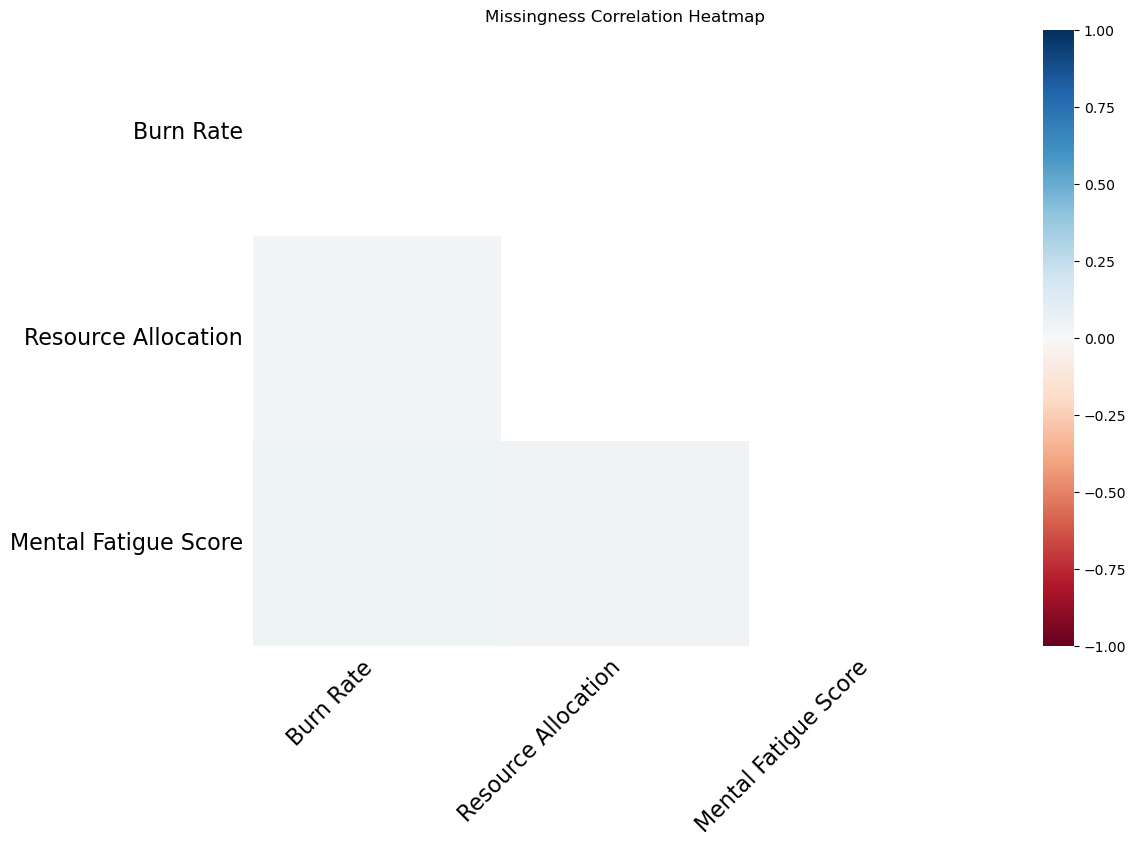

In [26]:
import missingno as msno
import matplotlib.pyplot as plt 

null_cols = ["Burn Rate"] + [col for col in train.columns
                            if train[col].isna().any() and col != "Burn Rate"]

msno.heatmap(train[null_cols], figsize=(12, 8))
plt.title("Missingness Correlation Heatmap")
plt.show()

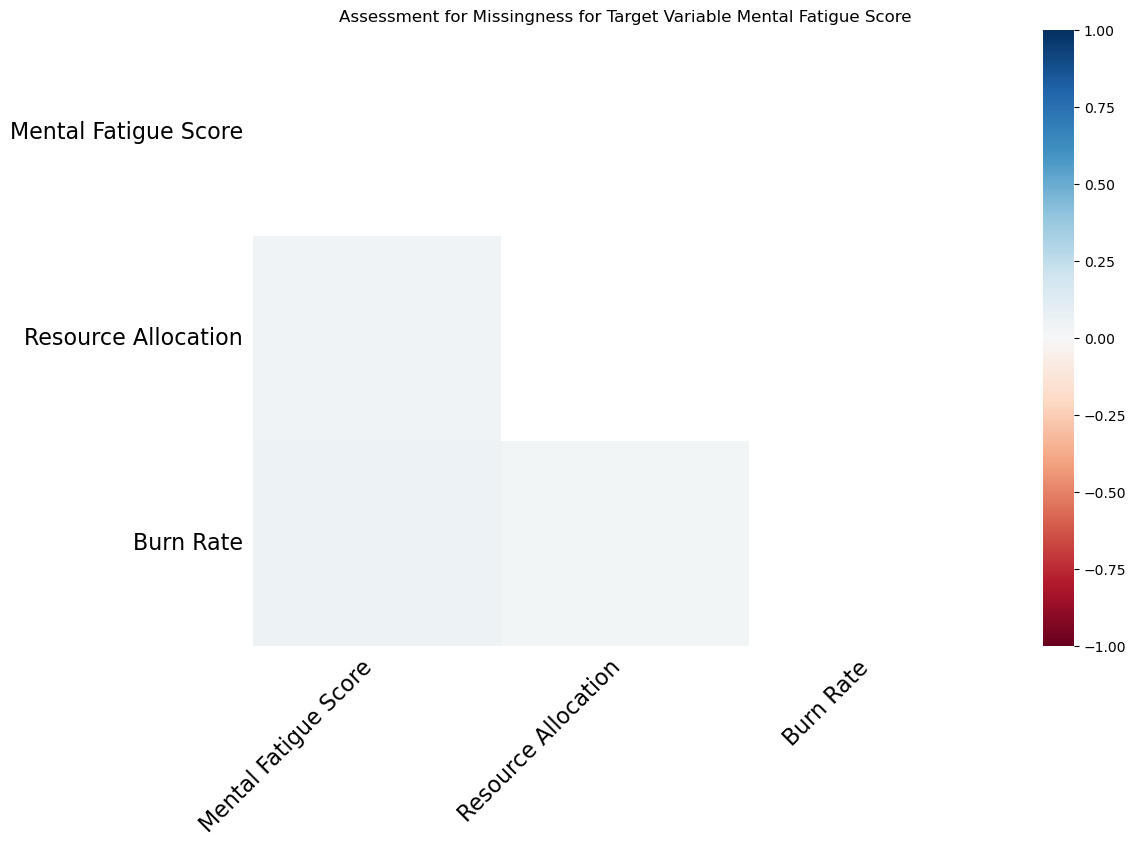

In [27]:
import missingno as msno
import matplotlib.pyplot as plt 

null_cols = ["Mental Fatigue Score"] + [col for col in train.columns
                            if train[col].isna().any() and col != "Mental Fatigue Score"]

msno.heatmap(train[null_cols], figsize=(12, 8))
plt.title("Assessment for Missingness for Target Variable Mental Fatigue Score")
plt.show()

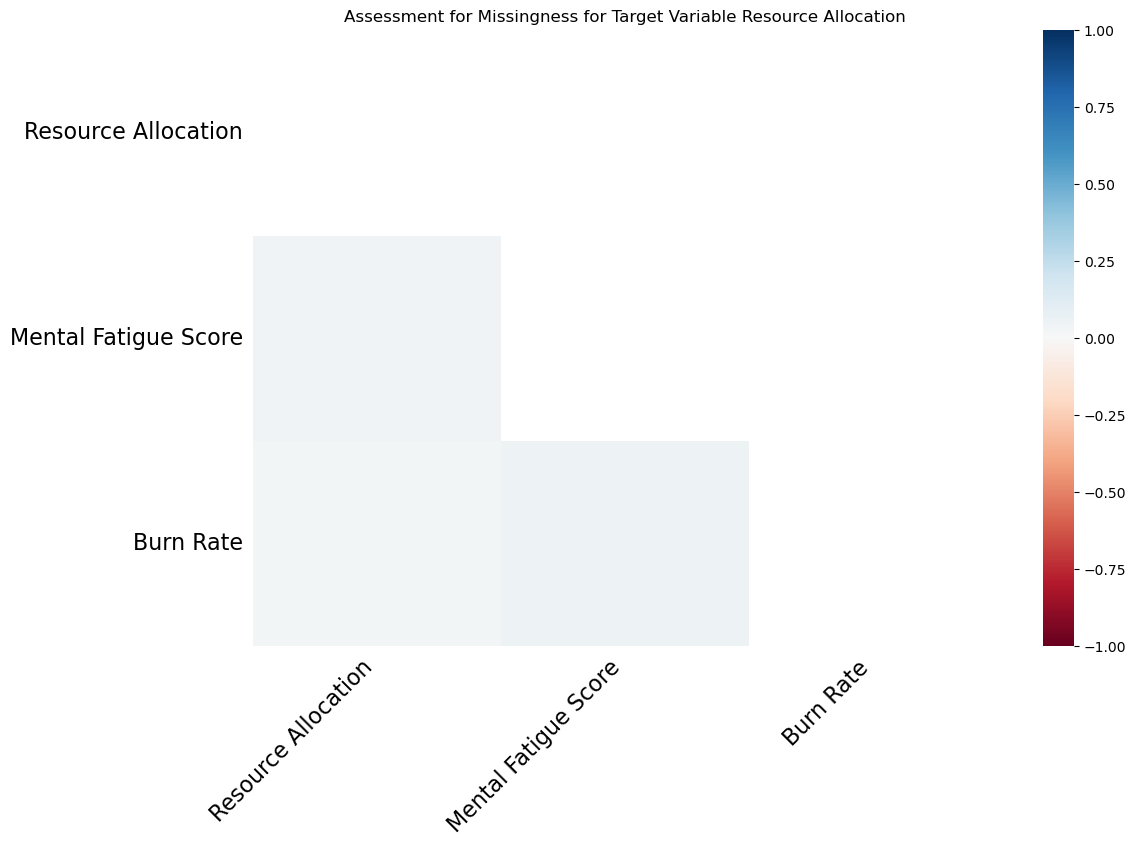

In [28]:
import missingno as msno
import matplotlib.pyplot as plt 

null_cols = ["Resource Allocation"] + [col for col in train.columns
                            if train[col].isna().any() and col != "Resource Allocation"]

msno.heatmap(train[null_cols], figsize=(12, 8))
plt.title("Assessment for Missingness for Target Variable Resource Allocation")
plt.show()

**Return Proportion of Missing Values by Column**

In [29]:
train.isna().sum() / len(train)

Gender                               0.000000
Company Type                         0.000000
WFH Setup Available                  0.000000
Designation                          0.000000
Resource Allocation                  0.060703
Mental Fatigue Score                 0.093055
Burn Rate                            0.049407
Gender_Female                        0.000000
Gender_Male                          0.000000
WFH Setup Available_No               0.000000
WFH Setup Available_Yes              0.000000
Company Type_Product                 0.000000
Company Type_Service                 0.000000
Join_Month_Year                      0.000000
days_since_joined                    0.000000
Seniority Level                      0.000000
High Burnout                         0.000000
Burnout Risk Factor                  0.000000
Burnout Risk Factor_High Risk        0.000000
Burnout Risk Factor_Low Risk         0.000000
Burnout Risk Factor_Moderate Risk    0.000000
dtype: float64

**Drop Missing Values for Burn Rate, Mental Fatigue Score and Working Hours**

In [30]:
train = train.dropna(subset=["Burn Rate", "Resource Allocation", "Mental Fatigue Score"])

In [31]:
print(train.shape)

(18590, 21)


In [32]:
train.isna().sum() / len(train)

Gender                               0.0
Company Type                         0.0
WFH Setup Available                  0.0
Designation                          0.0
Resource Allocation                  0.0
Mental Fatigue Score                 0.0
Burn Rate                            0.0
Gender_Female                        0.0
Gender_Male                          0.0
WFH Setup Available_No               0.0
WFH Setup Available_Yes              0.0
Company Type_Product                 0.0
Company Type_Service                 0.0
Join_Month_Year                      0.0
days_since_joined                    0.0
Seniority Level                      0.0
High Burnout                         0.0
Burnout Risk Factor                  0.0
Burnout Risk Factor_High Risk        0.0
Burnout Risk Factor_Low Risk         0.0
Burnout Risk Factor_Moderate Risk    0.0
dtype: float64

**Drop Values whereBurn Rate are 0**

In [33]:
train = train[(train["Burn Rate"] > 0)]

In [34]:
print(train.shape)

(18347, 21)


**Check for Duplicate Values By Row**
- There are no duplicate values

In [35]:
train.duplicated().any()

np.True_

**Univaraite of Non-Graphical Analysis**
Descriptive statistics
- Return mean, median, mode, minimum, maximum, IQR, variance, coefficent of variance, standard deviation and quartiles etc
- Skewness
- Kurtosis

**Conclusions from descriptive statistics**
- The numeric variables show well-aligned medians and modes, confirming symmetric distributions. Burn Rate sits at a median of 0.45, suggesting typical employees fall near the middle of the burnout scale. The most notable finding is the stark contrast in variability — Working Hours (45.6%) and Burn Rate (43.7%) show high spread across employees, meaning burnout and workload differ substantially person to person.

**Conclusions from IQR**
The IQR analysis confirms moderate spread in Working Hours, Mental Fatigue Score, and Burn Rate, with the middle 50% of employees falling within reasonable ranges across all three.

**Skewness and Kurtosis Conclusion**
- Analysis of skewness and kurtosis across the four numeric variables reveals that all distributions are approximately symmetric and well-behaved. Skewness values fall within the acceptable ±0.5 threshold for all variables, indicating no meaningful departure from symmetry and suggesting that no transformations are required prior to modeling. 
- Kurtosis values are uniformly negative (platykurtic), indicating flatter distributions with lighter tails — consistent with fewer extreme outliers than expected under normality, suggesting a near-uniform spread across its range.

Inferential Statistics 
• One sample t-test
• Dependent t-test
• One-way ANOVA (F-test)
• Number of missing values
• Identification of outliers

**Descriptive Statistics**

In [36]:
train[["Resource Allocation", "Mental Fatigue Score", "Burn Rate", "days_since_joined"]].describe().round(2)

,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined
count,18347.00,18347.00,18347.00,18347.00
mean,4.53,5.81,0.46,182.71
std,2.02,1.82,0.19,105.26
min,1.00,0.00,0.01,0.00
25%,3.00,4.60,0.32,92.00
50%,4.00,5.90,0.46,182.00
75%,6.00,7.10,0.59,274.00
max,10.00,10.00,1.00,365.00


In [37]:
numerics = train[["Resource Allocation", "Mental Fatigue Score", "Burn Rate", "days_since_joined"]]

q1 = numerics.quantile(0.25)
q3 = numerics.quantile(0.75)
iqr_values = q3-q1

iqr_summary = pd.DataFrame({
    "Q3 (75th)": q3,        
    "Q1 (25th)": q1,
    "IQR": iqr_values
})

iqr_summary

,Q3 (75th),Q1 (25th),IQR
Resource Allocation,6.00,3.00,3.00
Mental Fatigue Score,7.10,4.60,2.50
Burn Rate,0.59,0.32,0.27
days_since_joined,274.00,92.00,182.00


In [38]:
median = numerics.median()
mode = numerics.mode().iloc[0]
variance = numerics.var()
mean = numerics.mean()
cv = (numerics.std() / mean) * 100

In [39]:
summary = pd.DataFrame({
    "Median": median,
    "Mode": mode,
    "Variance": variance,
    "Coefficent of Variance (%)": cv
})

print(summary)

                      Median    Mode      Variance  Coefficent of Variance (%)
Resource Allocation     4.00    4.00      4.084222                   44.602782
Mental Fatigue Score    5.90    6.00      3.327472                   31.422185
Burn Rate               0.46    0.47      0.036915                   41.910309
days_since_joined     182.00  360.00  11079.701402                   57.610275


In [40]:
skewness = numerics.skew()
kurtosis = numerics.kurt()

summary1 = pd.DataFrame({
    "Skewness": skewness,
    "Kurtosis": kurtosis
})

summary1

,Skewness,Kurtosis
Resource Allocation,0.206407,-0.449172
Mental Fatigue Score,-0.268612,-0.139258
Burn Rate,0.124892,-0.305145
days_since_joined,0.010269,-1.198617


**Inferential Tests**
- one sample t test
- one way anova test (company type, gender, working from home, Seniority Level, Burnout Risk Factor)
- Outlier Identification

**Conclusion**
The inferential analysis confirms that Burn Rate is significantly below the 0.50 benchmark and is systematically driven by Seniority Level, WFH Setup Available, Burnout Risk Factor, and High Burnout — all returning highly significant ANOVA results — while Company Type shows no meaningful effect. Outlier detection flagged 310 cases in Mental Fatigue Score and 65 in Burn Rate, which will need to be addressed prior to modeling.

In [41]:
from scipy.stats import ttest_1samp 
ttest_1samp(train["Burn Rate"], popmean=0.50)

TtestResult(statistic=np.float64(-29.301587568318443), pvalue=np.float64(1.7244398466523927e-184), df=np.int64(18346))

In [42]:
from scipy.stats import f_oneway

grouping_vars = ["Company Type", "Gender", "WFH Setup Available", "Seniority Level", "Burnout Risk Factor", "High Burnout"]

results = []
for var in grouping_vars:
    groups = [group["Burn Rate"].values for _, group in train.groupby(var)]
    stat, p = f_oneway(*groups)
    results.append({"Variable": var, "F-Statistic": stat, "P-Value": p})

anova_results = pd.DataFrame(results)
print(anova_results)

              Variable   F-Statistic        P-Value
0         Company Type      0.415075   5.194131e-01
1               Gender    468.040452  1.631216e-102
2  WFH Setup Available   1987.023258   0.000000e+00
3      Seniority Level   4149.182294   0.000000e+00
4  Burnout Risk Factor  40536.153418   0.000000e+00
5         High Burnout  34509.075704   0.000000e+00


In [43]:
q1 = numerics.quantile(0.25)
q3 = numerics.quantile(0.75)
iqr_vals = q3 - q1

outliers = ((numerics < (q1 - 1.5 * iqr_vals)) | (numerics > (q3 + 1.5 * iqr_vals))).sum()
print(outliers)

Resource Allocation      0
Mental Fatigue Score    86
Burn Rate               65
days_since_joined        0
dtype: int64


**Univariate Graphical Analysis**
- Histogram/KDE: All three numeric variables display approximately symmetric, bell-shaped distributions consistent with earlier skewness findings. Working Hours peaks around 4–6 hours, Mental Fatigue Score is centered around 5–6, and Burn Rate clusters near 0.4–0.6, suggesting most employees fall in the moderate burnout range.
- Pie Charts: Categorical variables show notable imbalances across WFH Setup Available, Seniority Level, Burnout Risk Factor, and High Burnout while Gender and Company Type are more evenly distributed.
- Box Plots: Mental Fatigue Score and Burn Rate show visible outliers beyond the whisker fences, consistent with the 75 and 65 flagged earlier, while Working Hours displays a clean, compact distribution with no meaningful outliers.
- Countplots/Bar Plots: The barplot reveals that Senior and Lead employees accumulate the highest total working hours, suggesting heavier workloads at upper seniority levels. The countplot of employees experiencing burnout above average shows that Senior and Mid-Level employees account for the largest share of above-average burnout cases, indicating that mid-to-upper career stages carry the greatest burnout burden — likely driven by the compounding effect of higher working hours, as confirmed in the barplot.
- Line Graph: The hiring trend line graph reveals no strong seasonal pattern in employee onboarding across 2008. Hiring activity is relatively consistent month to month, with no pronounced peaks or troughs that would suggest recruitment is concentrated around a particular quarter or time of year. This indicates that onboarding was distributed evenly throughout the year rather than being driven by seasonal hiring cycles such as fiscal year starts, academic graduations, or end-of-year budget pushes.

**What is the distribution of the numerical columns in the training dataset?**

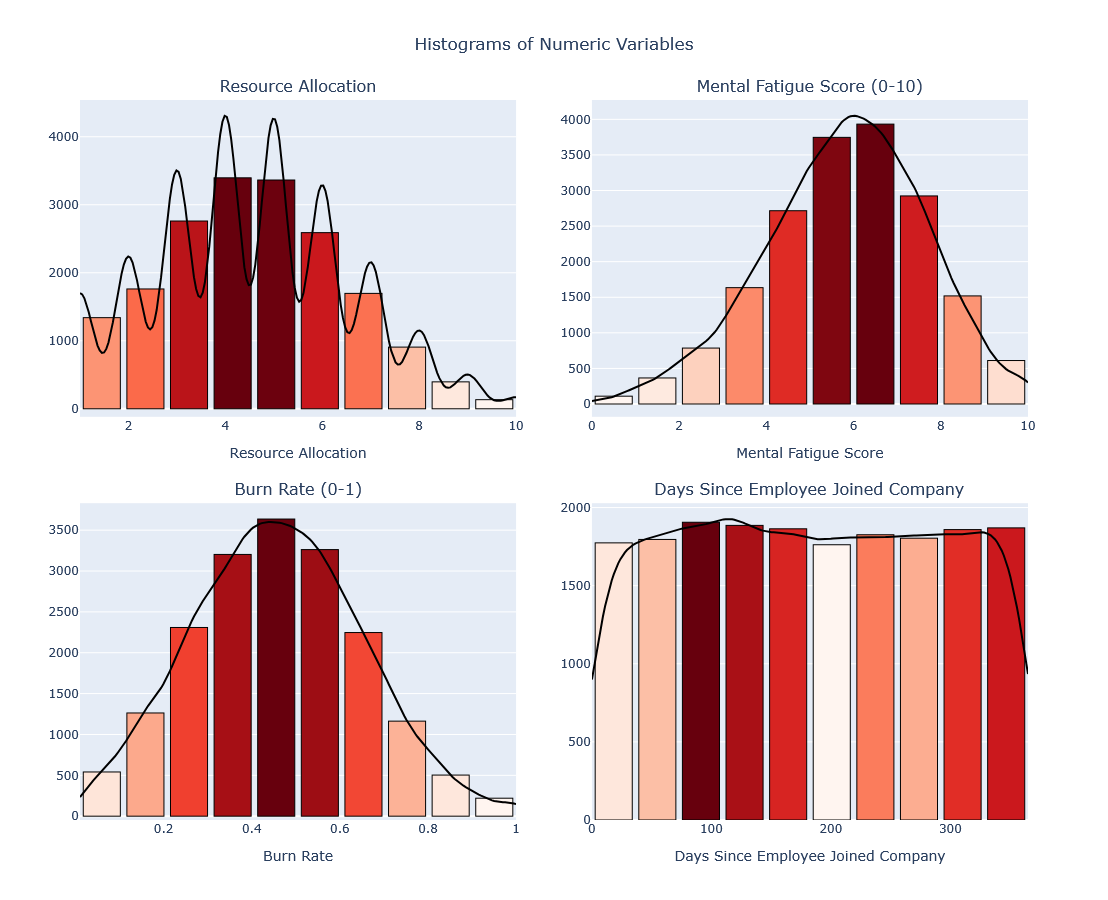

In [44]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
import numpy as np

cols_config = [
    ("Resource Allocation", "Resource Allocation", 10),
    ("Mental Fatigue Score", "Mental Fatigue Score (0-10)", 10),
    ("Burn Rate", "Burn Rate (0-1)", 10),
    ("days_since_joined", "Days Since Employee Joined Company", 10)
]

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[c[1] for c in cols_config],
    vertical_spacing=0.12,   
    horizontal_spacing=0.08 
)

positions = [(1,1), (1,2), (2, 1), (2, 2)]

for (col, label, bins), (row, col_pos) in zip(cols_config, positions):
    counts, bin_edges = np.histogram(train[col], bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    fig.add_trace(
        go.Bar(
            x=bin_centers,
            y=counts,
            marker=dict(
                color=counts,
                colorscale="Reds",
                line=dict(color="black", width=1)
            ),
            showlegend=False
        ),
        row=row, col=col_pos
    )

    kde = gaussian_kde(train[col].dropna())
    x_range = np.linspace(train[col].min(), train[col].max(), 200)
    kde_vals = kde(x_range)
    kde_scaled = kde_vals * (counts.sum() * (bin_edges[1] - bin_edges[0]))

    fig.add_trace(
        go.Scatter(
            x=x_range,
            y=kde_scaled,
            mode="lines",
            line=dict(color="black", width=2),
            showlegend=False
        ),
        row=row, col=col_pos
    )

for (col, label, bins), (row, col_pos) in zip(cols_config, positions):
    fig.update_xaxes(
        range=[train[col].min(), train[col].max()],
        row=row, col=col_pos
    )

fig.update_xaxes(title_text="Resource Allocation", range=[train["Resource Allocation"].min(), train["Resource Allocation"].max()], row=1, col=1)
fig.update_xaxes(title_text="Mental Fatigue Score", range=[train["Mental Fatigue Score"].min(), train["Mental Fatigue Score"].max()], row=1, col=2)
fig.update_xaxes(title_text="Burn Rate", range=[train["Burn Rate"].min(), train["Burn Rate"].max()], row=2, col=1)
fig.update_xaxes(title_text="Days Since Employee Joined Company", range=[train["days_since_joined"].min(), train["days_since_joined"].max()], row=2, col=2)

fig.update_layout(
    height=900,
    width=1100,
    title_text="Histograms of Numeric Variables",
    title_x=0.5,
    bargap=0.15
)

fig.show()

**What are the distributions of the values in the following columns**
- Company Type 
- Gender 
- WFH Setup Available 
- Burnout Risk Factor 
- High Burnout
- Seniority Level

In [45]:
company_type_counts = train["Company Type"].value_counts().reset_index()
company_type_counts.columns = ["Company Type", "Count"]

gender_counts = train["Gender"].value_counts().reset_index()
gender_counts.columns = ["Gender", "Count"]

wfh_counts = train["WFH Setup Available"].value_counts().reset_index()
wfh_counts.columns = ["WFH Setup Available", "Count"]

burnout_risk_factor_counts = train["Burnout Risk Factor"].value_counts().reset_index()
burnout_risk_factor_counts.columns = ["Burnout Risk Factor", "Count"]

high_burnout_counts = train["High Burnout"].value_counts().reset_index()
high_burnout_counts.columns = ["High Burnout", "Count"]

seniority_level_counts = train["Seniority Level"].value_counts().reset_index()
seniority_level_counts.columns = ["Seniority Level", "Count"]

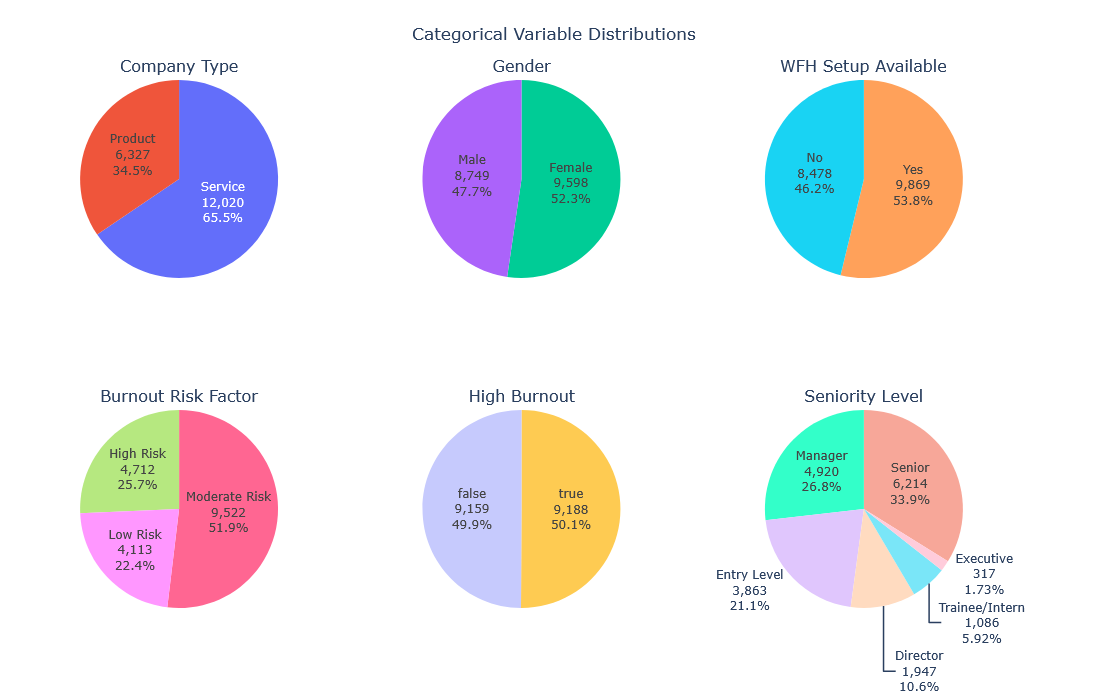

In [46]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

datasets = [
     (company_type_counts, "Company Type", "Company Type"),
    (gender_counts, "Gender", "Gender"),
    (wfh_counts, "WFH Setup Available", "WFH Setup Available"),
    (burnout_risk_factor_counts, "Burnout Risk Factor", "Burnout Risk Factor"),
    (high_burnout_counts, "High Burnout", "High Burnout"),
    (seniority_level_counts, "Seniority Level", "Seniority Level")
]

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[d[2] for d in datasets],
    specs=[[{"type": "pie"}] * 3] * 2
)

positions = [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3)]

for (df, col, title), (row, col_pos) in zip(datasets, positions):
    fig.add_trace(
        go.Pie(
            labels=df[col],
            values=df["Count"],
            textinfo="label+percent",
            customdata=df["Count"],
            hovertemplate="<b>%{label}</b><br>Count: %{customdata:,}<br>Percent: %{percent}<extra></extra>",
            texttemplate="%{label}<br>%{customdata:,}<br>%{percent}",
            showlegend=False
        ),
        row=row, col=col_pos
    )

fig.update_layout(
    height=700,
    title_text="Categorical Variable Distributions",
    title_x=0.5,
    margin=dict(t=80, b=40, l=40, r=40)
)

fig.show()

In [47]:
import matplotlib.pyplot as plt

**Create boxplots to visualize the spread of data for working hours, mental fatigue score and burn rate, highlight any outliers that appear**

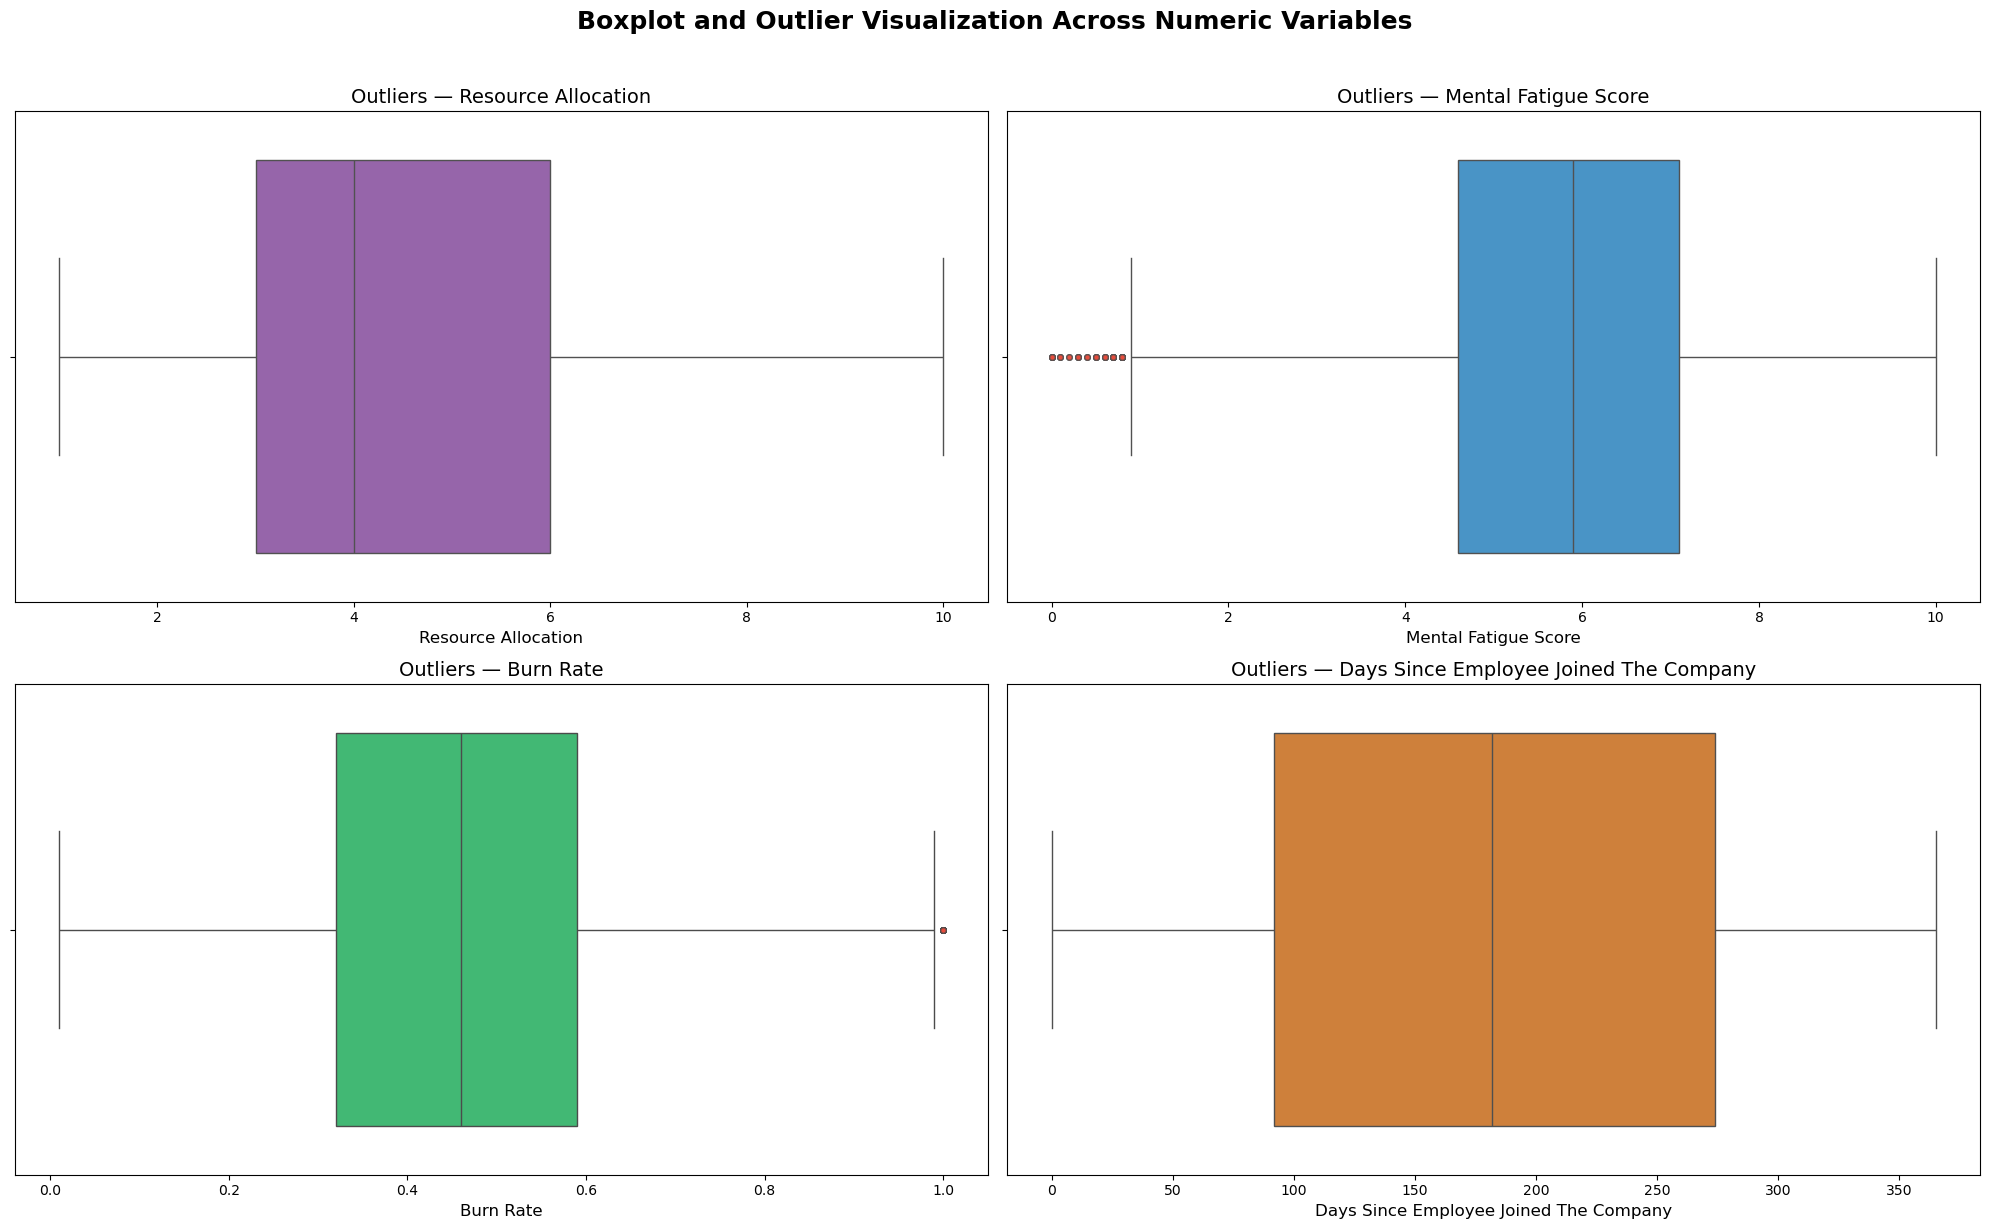

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

sns.boxplot(data=train, x="Resource Allocation", ax=axes[0, 0], color="#9b59b6",
            flierprops={"marker": "o", "markerfacecolor": "#e74c3c", "markersize": 4, "alpha": 0.5})
axes[0, 0].set_title("Outliers — Resource Allocation", fontsize=14)
axes[0, 0].set_xlabel("Resource Allocation", fontsize=12)

sns.boxplot(data=train, x="Mental Fatigue Score", ax=axes[0, 1], color="#3498db",
            flierprops={"marker": "o", "markerfacecolor": "#e74c3c", "markersize": 4, "alpha": 0.5})
axes[0, 1].set_title("Outliers — Mental Fatigue Score", fontsize=14)
axes[0, 1].set_xlabel("Mental Fatigue Score", fontsize=12)

sns.boxplot(data=train, x="Burn Rate", ax=axes[1, 0], color="#2ecc71",
            flierprops={"marker": "o", "markerfacecolor": "#e74c3c", "markersize": 4, "alpha": 0.5})
axes[1, 0].set_title("Outliers — Burn Rate", fontsize=14)
axes[1, 0].set_xlabel("Burn Rate", fontsize=12)

sns.boxplot(data=train, x="days_since_joined", ax=axes[1, 1], color="#e67e22",
            flierprops={"marker": "o", "markerfacecolor": "#e74c3c", "markersize": 4, "alpha": 0.5})
axes[1, 1].set_title("Outliers — Days Since Employee Joined The Company", fontsize=14)
axes[1, 1].set_xlabel("Days Since Employee Joined The Company", fontsize=12)

fig.suptitle("Boxplot and Outlier Visualization Across Numeric Variables",
             fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**What employee types are working the most amount of hours?**

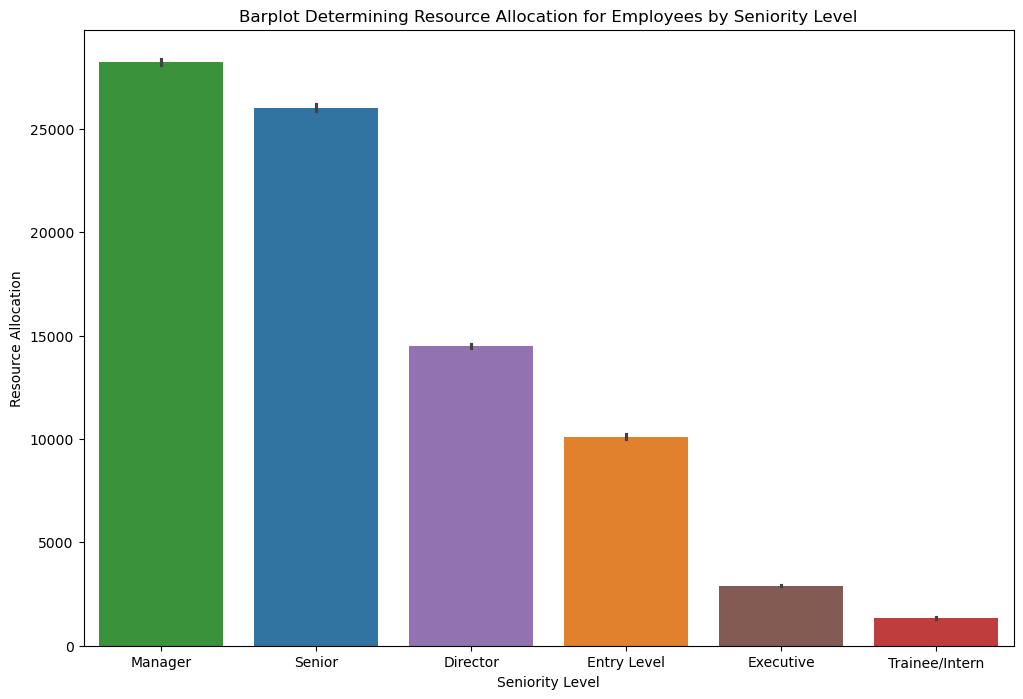

In [49]:
order = (train.groupby("Seniority Level")["Resource Allocation"]
        .sum()
        .sort_values(ascending=False)
        .index)

f, x = plt.subplots(1, 1, figsize=(12, 8))
ax = sns.barplot(train, x="Seniority Level", y="Resource Allocation", estimator=np.sum, hue="Seniority Level",
                                order=order)
ax.set_title("Barplot Determining Resource Allocation for Employees by Seniority Level");

**Which Employee Types Burn out the most on average**

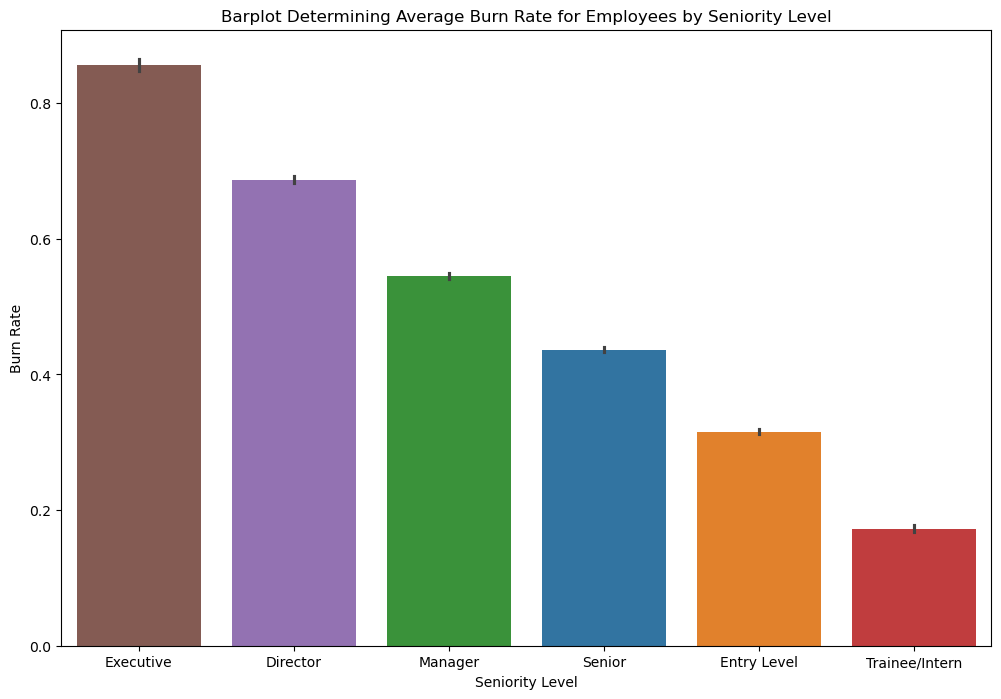

In [50]:
order = (train.groupby("Seniority Level")["Burn Rate"]
        .mean()
        .sort_values(ascending=False)
        .index)

f, x = plt.subplots(1, 1, figsize=(12, 8))
ax = sns.barplot(train, x="Seniority Level", y="Burn Rate", estimator=np.mean, hue="Seniority Level",
                                order=order)
ax.set_title("Barplot Determining Average Burn Rate for Employees by Seniority Level");

**What is the average days since employee joined by seniority Level**

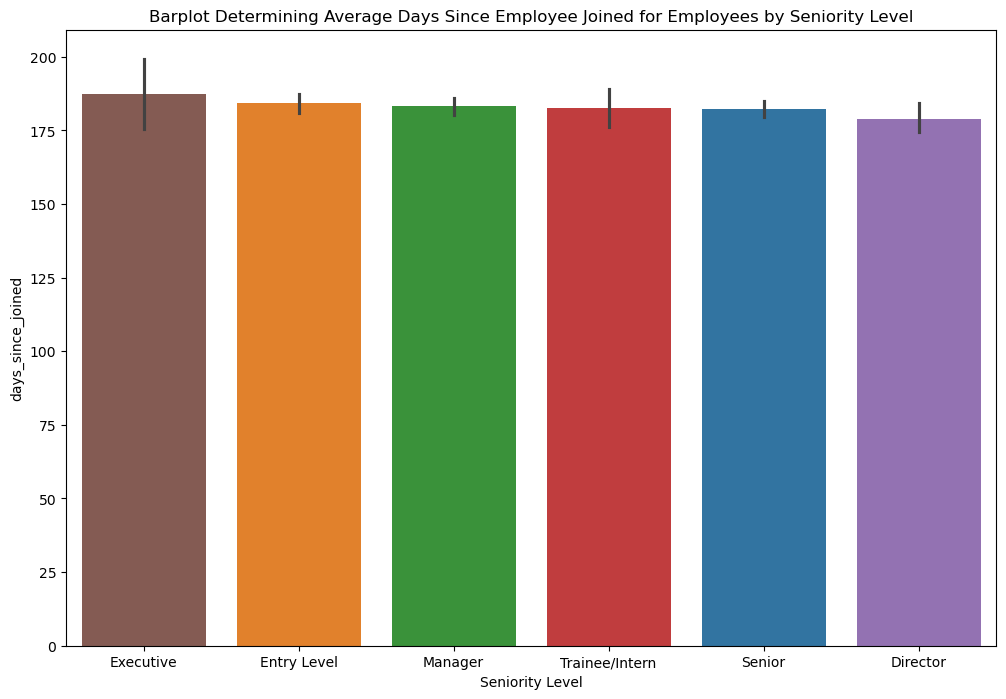

In [51]:
order = (train.groupby("Seniority Level")["days_since_joined"]
        .mean()
        .sort_values(ascending=False)
        .index)

f, x = plt.subplots(1, 1, figsize=(12, 8))
ax = sns.barplot(train, x="Seniority Level", y="days_since_joined", estimator=np.mean, hue="Seniority Level",
                                order=order)
ax.set_title("Barplot Determining Average Days Since Employee Joined for Employees by Seniority Level");

**Which division is working the most amount of hours**

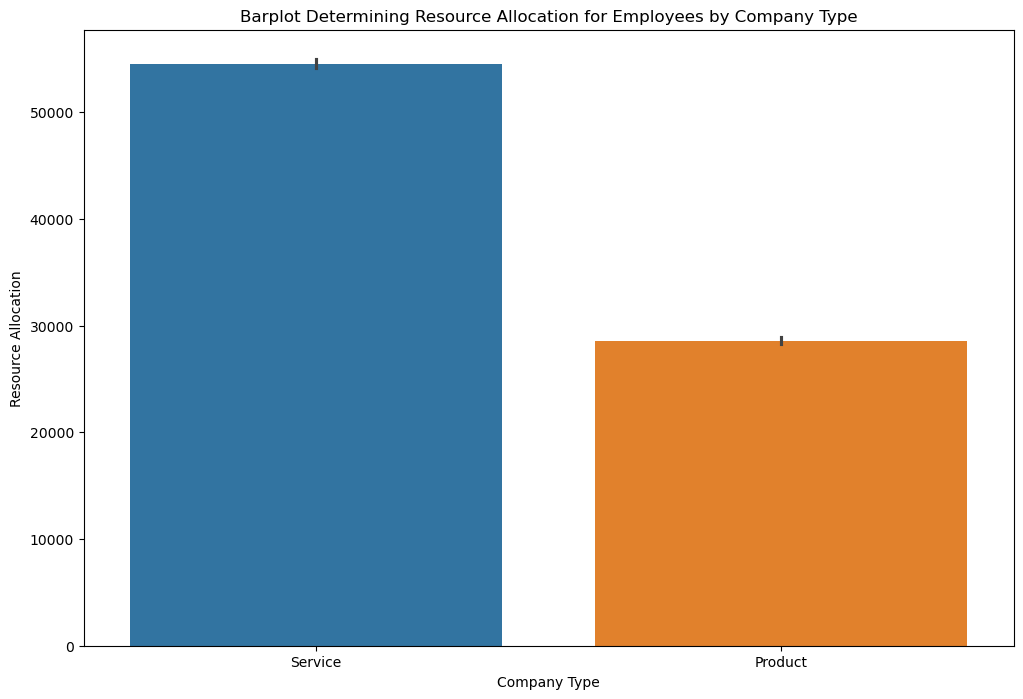

In [52]:
order = (train.groupby("Company Type")["Resource Allocation"]
        .sum()
        .sort_values(ascending=False)
        .index)

f, x = plt.subplots(1, 1, figsize=(12, 8))
ax = sns.barplot(train, x="Company Type", y="Resource Allocation", estimator=np.sum, hue="Company Type",
                                order=order)
ax.set_title("Barplot Determining Resource Allocation for Employees by Company Type");

**What is the average tenure by company type**

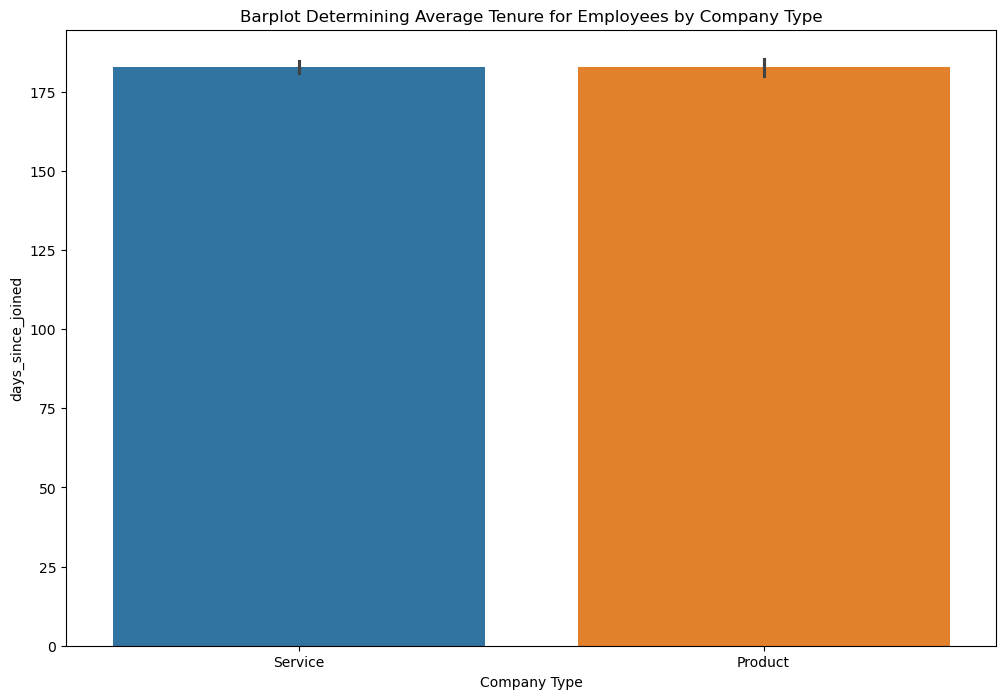

In [53]:
order = (train.groupby("Company Type")["days_since_joined"]
        .sum()
        .sort_values(ascending=False)
        .index)

f, x = plt.subplots(1, 1, figsize=(12, 8))
ax = sns.barplot(train, x="Company Type", y="days_since_joined", estimator=np.mean, hue="Company Type",
                                order=order)
ax.set_title("Barplot Determining Average Tenure for Employees by Company Type");

**What is the variation in average burn rate by company type??**

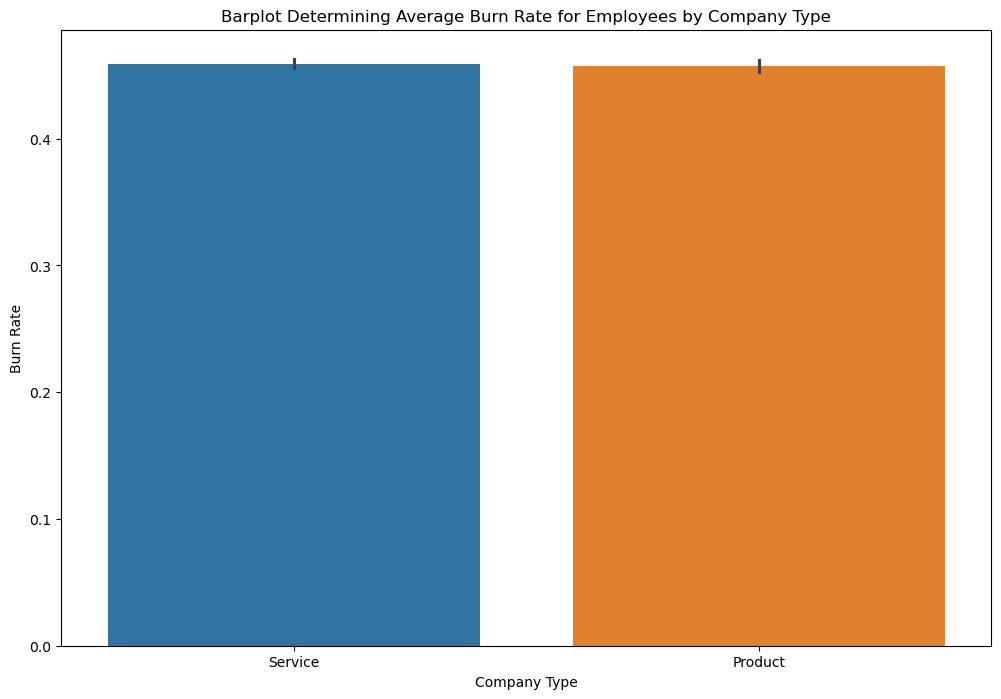

In [54]:
order = (train.groupby("Company Type")["Burn Rate"]
        .mean()
        .sort_values(ascending=False)
        .index)

f, x = plt.subplots(1, 1, figsize=(12, 8))
ax = sns.barplot(train, x="Company Type", y="Burn Rate", estimator=np.mean, hue="Company Type",
                                order=order)
ax.set_title("Barplot Determining Average Burn Rate for Employees by Company Type");

**What is the variation in average burn rate by gender??**

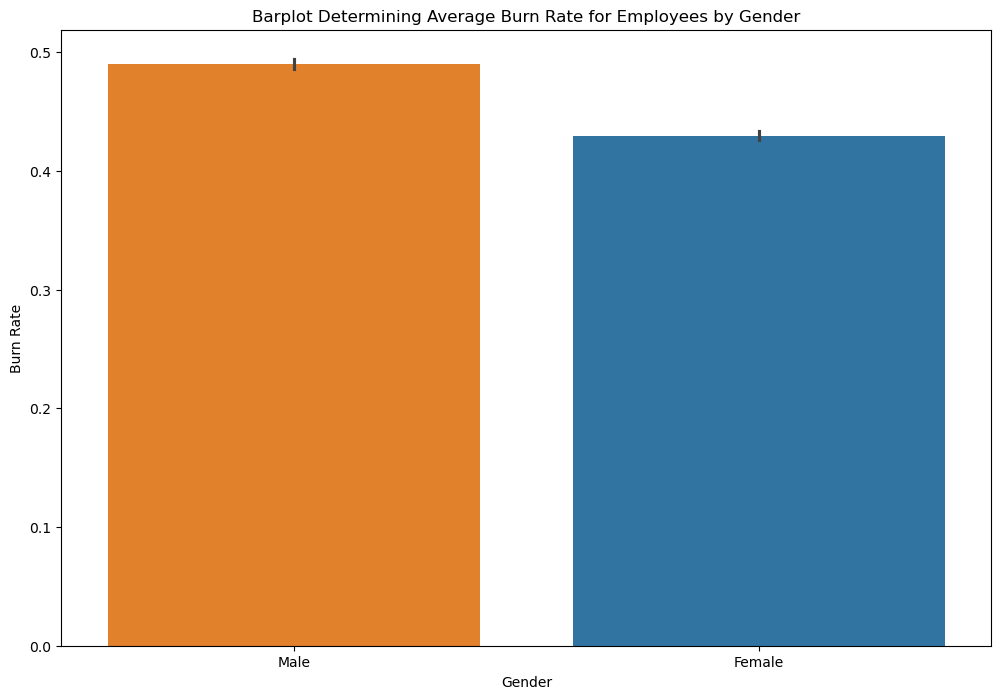

In [55]:
order = (train.groupby("Gender")["Burn Rate"]
        .mean()
        .sort_values(ascending=False)
        .index)

f, x = plt.subplots(1, 1, figsize=(12, 8))
ax = sns.barplot(train, x="Gender", y="Burn Rate", estimator=np.mean, hue="Gender",
                                order=order)
ax.set_title("Barplot Determining Average Burn Rate for Employees by Gender");

**Is there any seasonality in hiring**

In [56]:
counts_df = train['Join_Month_Year'].value_counts().reset_index()
counts_df.columns = ['Join_Month_Year', 'count']

In [57]:
counts_df = counts_df.sort_values(
    by='Join_Month_Year',
    key=lambda x: pd.to_datetime(x, format='%B %Y')
)

print(counts_df)

   Join_Month_Year  count
5     January 2008   1554
11   February 2008   1459
3       March 2008   1569
7       April 2008   1495
6         May 2008   1527
10       June 2008   1466
4        July 2008   1567
2      August 2008   1573
1   September 2008   1587
0     October 2008   1605
8    November 2008   1477
9    December 2008   1468


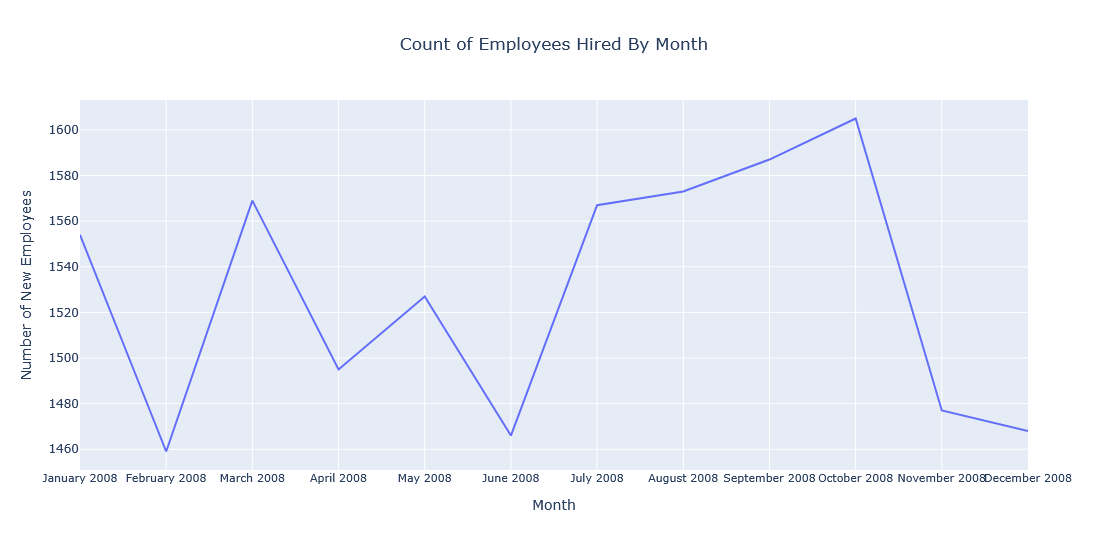

In [58]:
fig = px.line(
    counts_df, 
    x='Join_Month_Year', 
    y='count', 
    title='Count of Employees Hired By Month',
    labels={'Join_Month_Year': 'Month', 'count': 'Number of New Employees'},
    height=550
)

fig.update_layout(xaxis_tickangle=0, title_x=0.5)
fig.update_xaxes(tickfont=dict(size=11))
fig.show()

'**Is there Any Seasonality of Hiring By Company Type**

In [59]:
train['Join_Month_Year_Sort'] = pd.to_datetime(train['Join_Month_Year'], format='%B %Y')

In [60]:
counts_df1 = (
    train.groupby(['Join_Month_Year', 'Join_Month_Year_Sort', 'Company Type'])
    .size()
    .reset_index(name='Count')
    .sort_values(by='Join_Month_Year_Sort')
    .drop(columns='Join_Month_Year_Sort')
)

In [61]:
counts_df1

,Join_Month_Year,Company Type,Count
8,January 2008,Product,520
9,January 2008,Service,1034
6,February 2008,Product,514
7,February 2008,Service,945
15,March 2008,Service,1027
14,March 2008,Product,542
0,April 2008,Product,552
1,April 2008,Service,943
17,May 2008,Service,1005
16,May 2008,Product,522


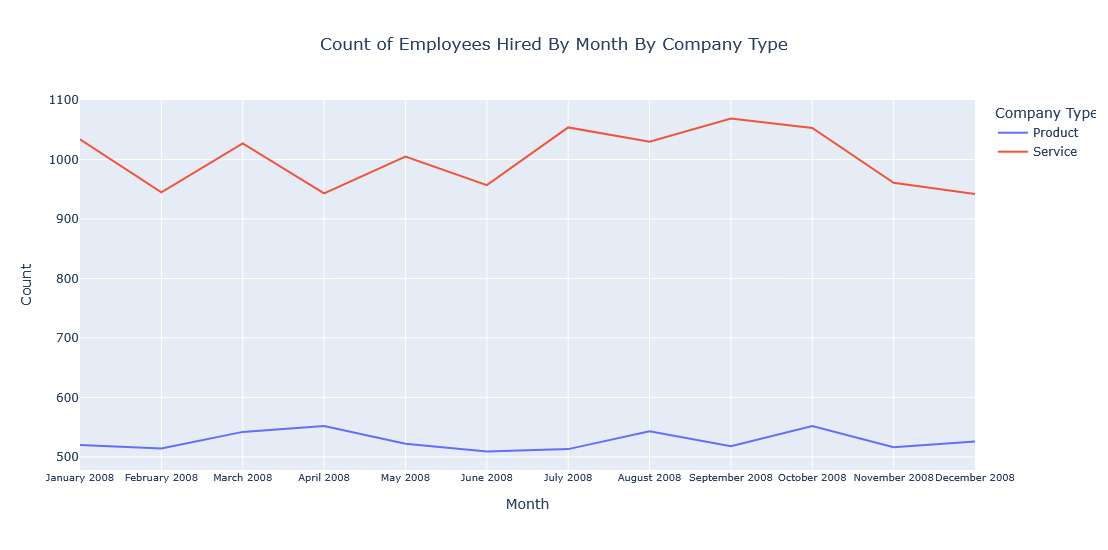

In [62]:
fig1 = px.line(
    counts_df1, 
    x='Join_Month_Year', 
    y='Count', 
    color="Company Type",
    title='Count of Employees Hired By Month By Company Type',
    labels={'Join_Month_Year': 'Month', 'count': 'Number of Joins'},
    height=550
)

fig1.update_layout(xaxis_tickangle=0, title_x=0.5)
fig1.update_xaxes(tickfont=dict(size=10))
fig1.show()

In [63]:
counts_df2 = (
    train.groupby(['Join_Month_Year', 'Join_Month_Year_Sort', 'Seniority Level'])
    .size()
    .reset_index(name='Count')
    .sort_values(by='Join_Month_Year_Sort')
    .drop(columns='Join_Month_Year_Sort')
)

In [64]:
counts_df2 

,Join_Month_Year,Seniority Level,Count
29,January 2008,Trainee/Intern,94
28,January 2008,Senior,511
27,January 2008,Manager,424
26,January 2008,Executive,31
25,January 2008,Entry Level,327
...,...,...,...
14,December 2008,Executive,17
15,December 2008,Manager,375
16,December 2008,Senior,512
17,December 2008,Trainee/Intern,97


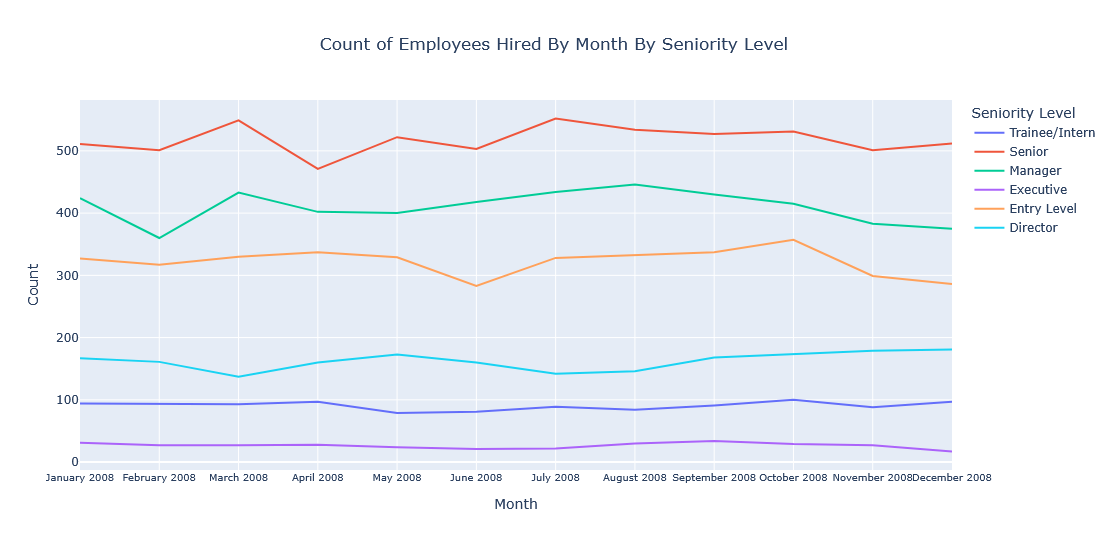

In [65]:
fig2 = px.line(
    counts_df2, 
    x='Join_Month_Year', 
    y='Count', 
    color="Seniority Level",
    title='Count of Employees Hired By Month By Seniority Level',
    labels={'Join_Month_Year': 'Month', 'count': 'Number of Joins'},
    height=550
)

fig2.update_layout(xaxis_tickangle=0, title_x=0.5)
fig2.update_xaxes(tickfont=dict(size=10))
fig2.show()

**Which employee types are exhibiting high burnout?**

In [66]:
AboveAverage = train[train["High Burnout"] == True]
AboveAverage.head(5)

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Gender_Female,Gender_Male,WFH Setup Available_No,...,Company Type_Service,Join_Month_Year,days_since_joined,Seniority Level,High Burnout,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk,Join_Month_Year_Sort
4,Female,Service,No,3,7.0,6.9,0.52,True,False,True,...,True,July 2008,160,Manager,True,Moderate Risk,False,False,True,2008-07-01
6,Female,Service,No,3,6.0,7.9,0.62,True,False,True,...,True,January 2008,364,Manager,True,High Risk,True,False,False,2008-01-01
10,Male,Product,Yes,2,3.0,5.3,0.50,False,True,False,...,False,March 2008,290,Senior,True,Moderate Risk,False,False,True,2008-03-01
14,Male,Product,Yes,1,3.0,5.8,0.51,False,True,False,...,False,May 2008,231,Entry Level,True,Moderate Risk,False,False,True,2008-05-01
17,Male,Service,No,3,6.0,6.7,0.59,False,True,True,...,True,March 2008,278,Manager,True,High Risk,True,False,False,2008-03-01


In [67]:
order1 = AboveAverage["Seniority Level"].value_counts().index

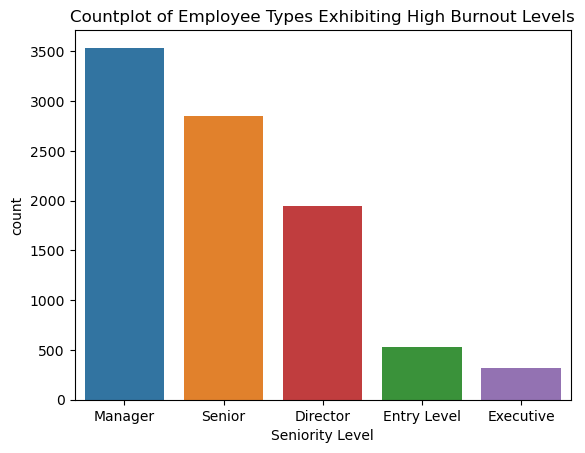

In [68]:
sns.countplot(data=AboveAverage, x="Seniority Level", hue="Seniority Level", order=order1)
plt.title("Countplot of Employee Types Exhibiting High Burnout Levels")
plt.show()

**What are the demographic considerations for employees with high burnout levels?**

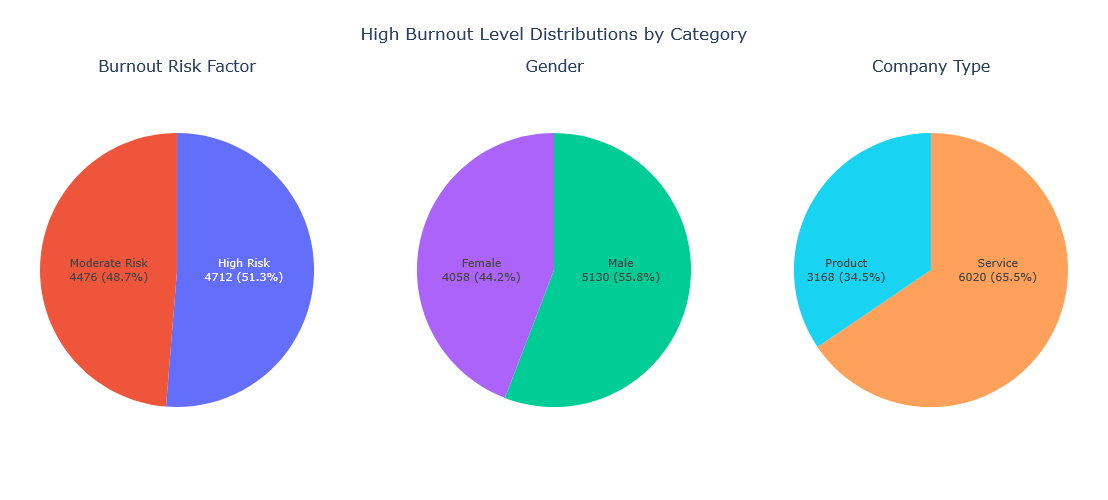

In [69]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

burnout_risk_factors = AboveAverage["Burnout Risk Factor"].value_counts().reset_index()
burnout_risk_factors.columns = ["Burnout Risk Factor", "Count"]
gender_factors = AboveAverage["Gender"].value_counts().reset_index()
gender_factors.columns = ["Gender", "Count"]
company_type_factors = AboveAverage["Company Type"].value_counts().reset_index()
company_type_factors.columns = ["Company Type", "Count"]

fig = make_subplots(
    rows=1, cols=3,
    specs=[[{"type": "pie"}, {"type": "pie"}, {"type": "pie"}]],
    subplot_titles=[
        "Burnout Risk Factor", "Gender", "Company Type"
    ],
    horizontal_spacing=0.1
)

datasets = [
    (burnout_risk_factors, "Burnout Risk Factor"),
    (gender_factors, "Gender"),
    (company_type_factors, "Company Type"),
]
positions = [(1, 1), (1, 2), (1, 3)]

for (df, col), (row, col_pos) in zip(datasets, positions):
    fig.add_trace(
        go.Pie(
            labels=df[col],
            values=df["Count"],
            texttemplate="%{label}<br>%{value} (%{percent})",
            textposition="inside",
            textfont=dict(size=11),
            name=col,
            showlegend=False,
            insidetextorientation="radial"
        ),
        row=row, col=col_pos
    )

fig.update_layout(
    title_text="High Burnout Level Distributions by Category",
    title_x=0.5,
    height=500,
    width=1100,
    margin=dict(t=80, b=40, l=40, r=40),
)

fig.show()

**Bi/Multi Varaite Analysis**

**Return a heatmap assessing correlation between numerical values**
- the highest correlation is between burn rate and mental fatigue with 86.8 correlation
- the correlation between working hours and burn rate is 82.9
- the correation between mental faitgue score and burn rate is 86.8

In [70]:
numerics = train[["Resource Allocation", "Mental Fatigue Score", "days_since_joined", "Burn Rate"]].corr(numeric_only=True)
numerics

,Resource Allocation,Mental Fatigue Score,days_since_joined,Burn Rate
Resource Allocation,1.000000,0.795667,-0.005426,0.850187
Mental Fatigue Score,0.795667,1.000000,-0.005775,0.941850
days_since_joined,-0.005426,-0.005775,1.000000,-0.004849
Burn Rate,0.850187,0.941850,-0.004849,1.000000


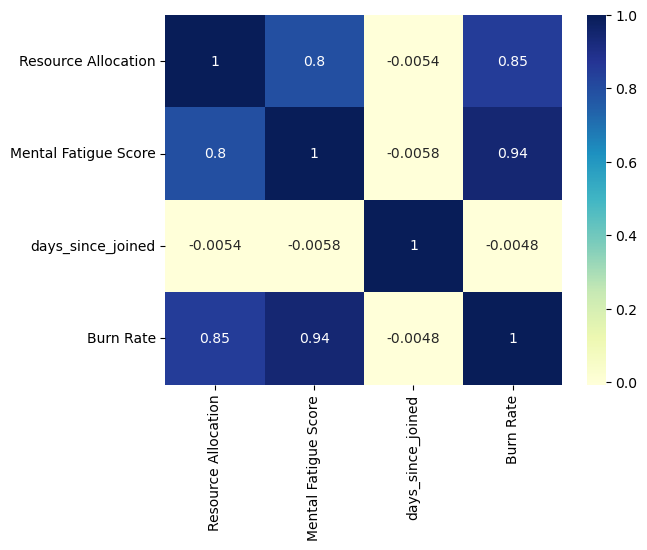

In [71]:
sns.heatmap(numerics, cmap="YlGnBu", annot=True)
plt.show()

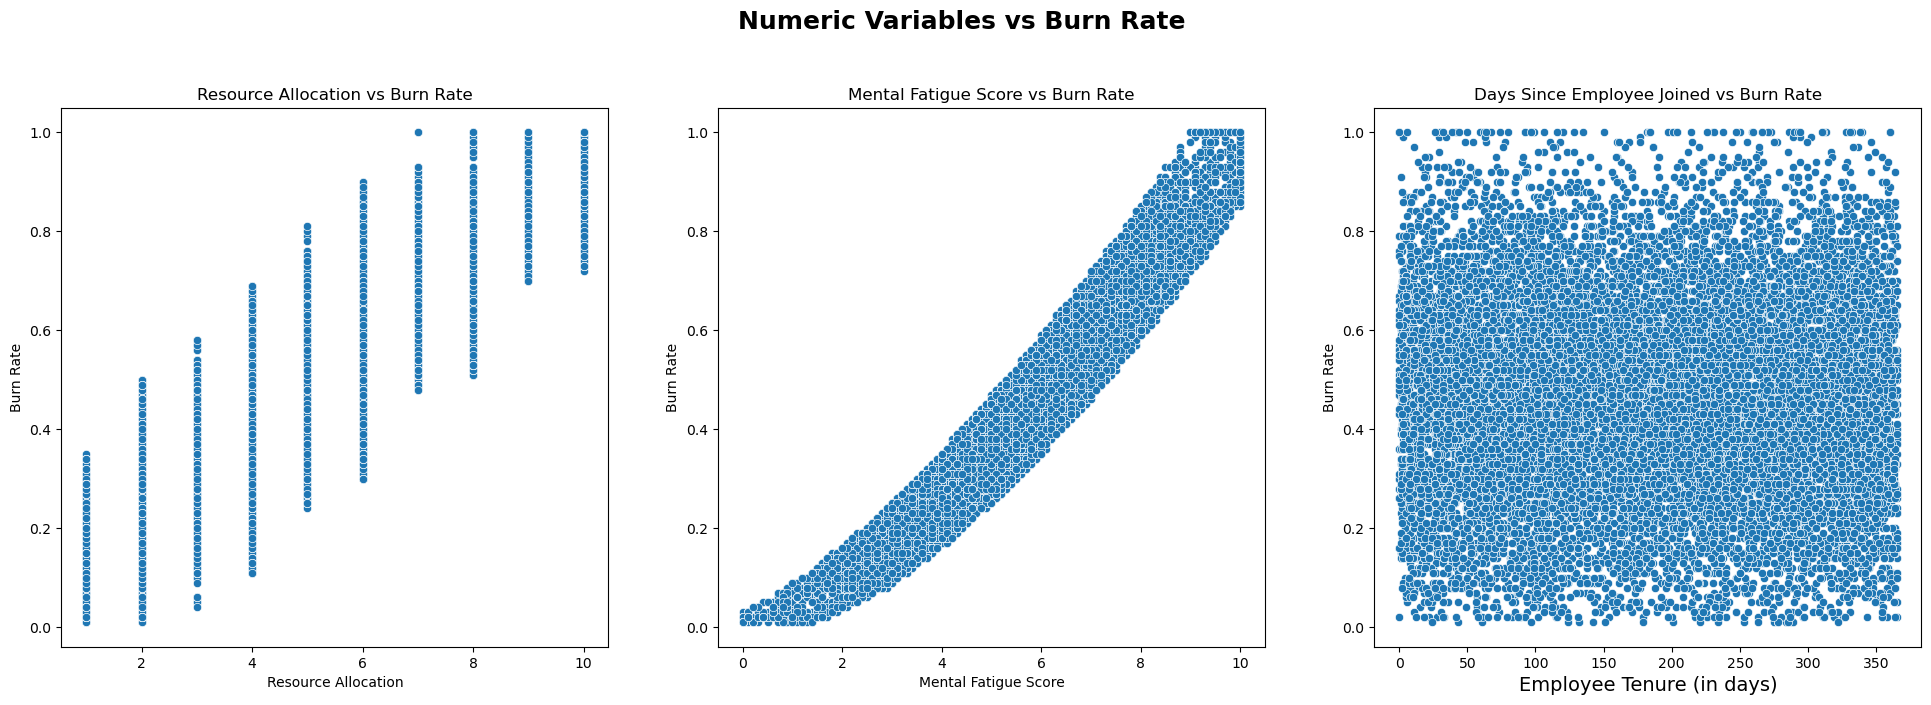

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
sns.scatterplot(data=train, x="Resource Allocation", y="Burn Rate", ax=axes[0])
sns.scatterplot(data=train, x="Mental Fatigue Score", y="Burn Rate", ax=axes[1])
sns.scatterplot(data=train, x="days_since_joined", y="Burn Rate", ax=axes[2])
axes[0].set_title("Resource Allocation vs Burn Rate")
axes[1].set_title("Mental Fatigue Score vs Burn Rate")
axes[2].set_title("Days Since Employee Joined vs Burn Rate")

axes[2].set_xlabel("Employee Tenure (in days)", fontsize=14)

fig.suptitle("Numeric Variables vs Burn Rate", fontsize=18, fontweight="bold", y=1.02)
plt.show()

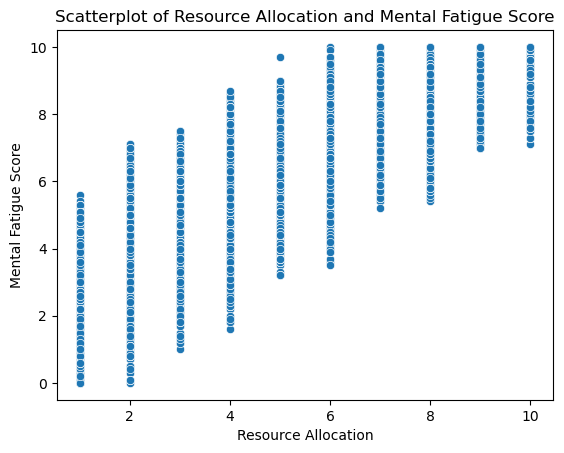

In [73]:
sns.scatterplot(data=train, x="Resource Allocation", y="Mental Fatigue Score")
plt.title("Scatterplot of Resource Allocation and Mental Fatigue Score")
plt.show()

**What are the trends in Working Hours, Mental Fatigue Score by working from home status**

C:\Users\alexh\AppData\Local\Temp\ipykernel_8508\1629181903.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"], fontsize=13)
C:\Users\alexh\AppData\Local\Temp\ipykernel_8508\1629181903.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)
C:\Users\alexh\AppData\Local\Temp\ipykernel_8508\1629181903.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"], fontsize=13)
C:\Users\alexh\AppData\Local\Temp\ipykernel_8508\1629181903.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(f

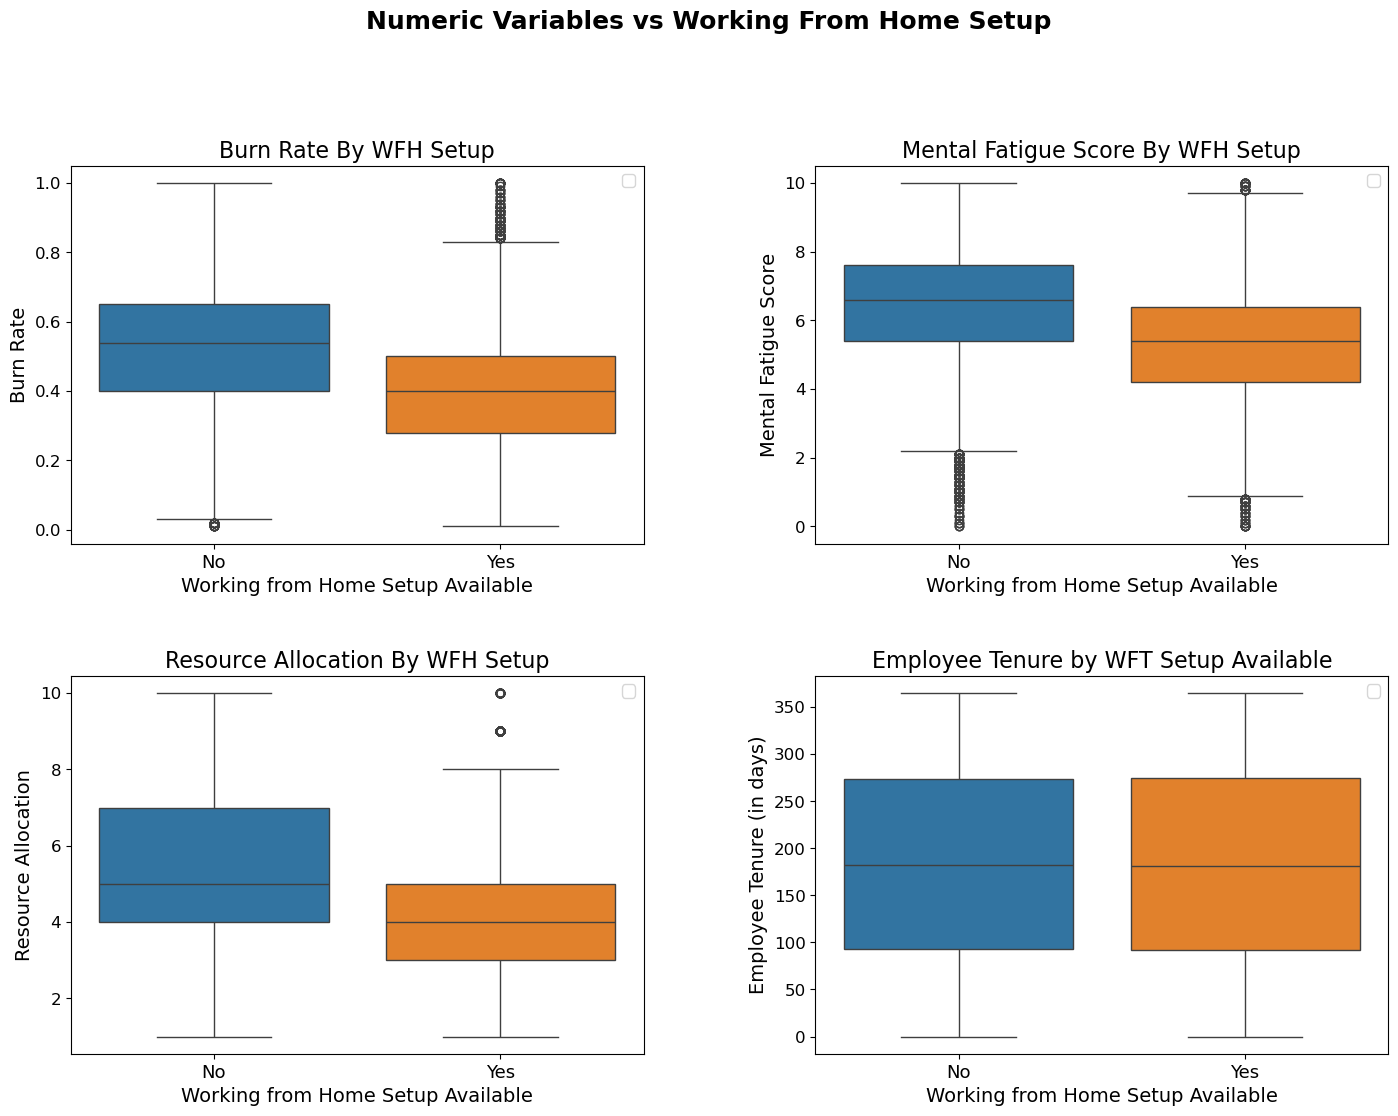

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(17, 12))

sns.boxplot(data=train, x="WFH Setup Available", y="Burn Rate", hue="WFH Setup Available", ax=axes[0, 0])
sns.boxplot(data=train, x="WFH Setup Available", y="Mental Fatigue Score", hue="WFH Setup Available", ax=axes[0, 1])
sns.boxplot(data=train, x="WFH Setup Available", y="Resource Allocation", hue="WFH Setup Available", ax=axes[1, 0])
sns.boxplot(data=train, x="WFH Setup Available", y="days_since_joined", hue="WFH Setup Available", ax=axes[1, 1])

axes[0, 0].set_title("Burn Rate By WFH Setup", fontsize=16)
axes[0, 1].set_title("Mental Fatigue Score By WFH Setup", fontsize=16)
axes[1, 0].set_title("Resource Allocation By WFH Setup", fontsize=16)
axes[1, 1].set_title("Employee Tenure by WFT Setup Available", fontsize=16)

axes[1, 1].set_ylabel("Employee Tenure (in days)", fontsize=14)

for ax in axes.flat:  
    ax.set_xlabel("Working from Home Setup Available", fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.set_xticklabels(["No", "Yes"], fontsize=13)
    ax.tick_params(axis='y', labelsize=12)
    ax.legend(fontsize=12)

fig.suptitle("Numeric Variables vs Working From Home Setup", fontsize=18, fontweight="bold", y=0.98)
plt.subplots_adjust(hspace=0.35, wspace=0.3, top=0.85)
plt.show()

**Can we pinpoint patterns in detecting an employee experiencing high burnout by the amount of hours they work as well as mental fatigue score they have**

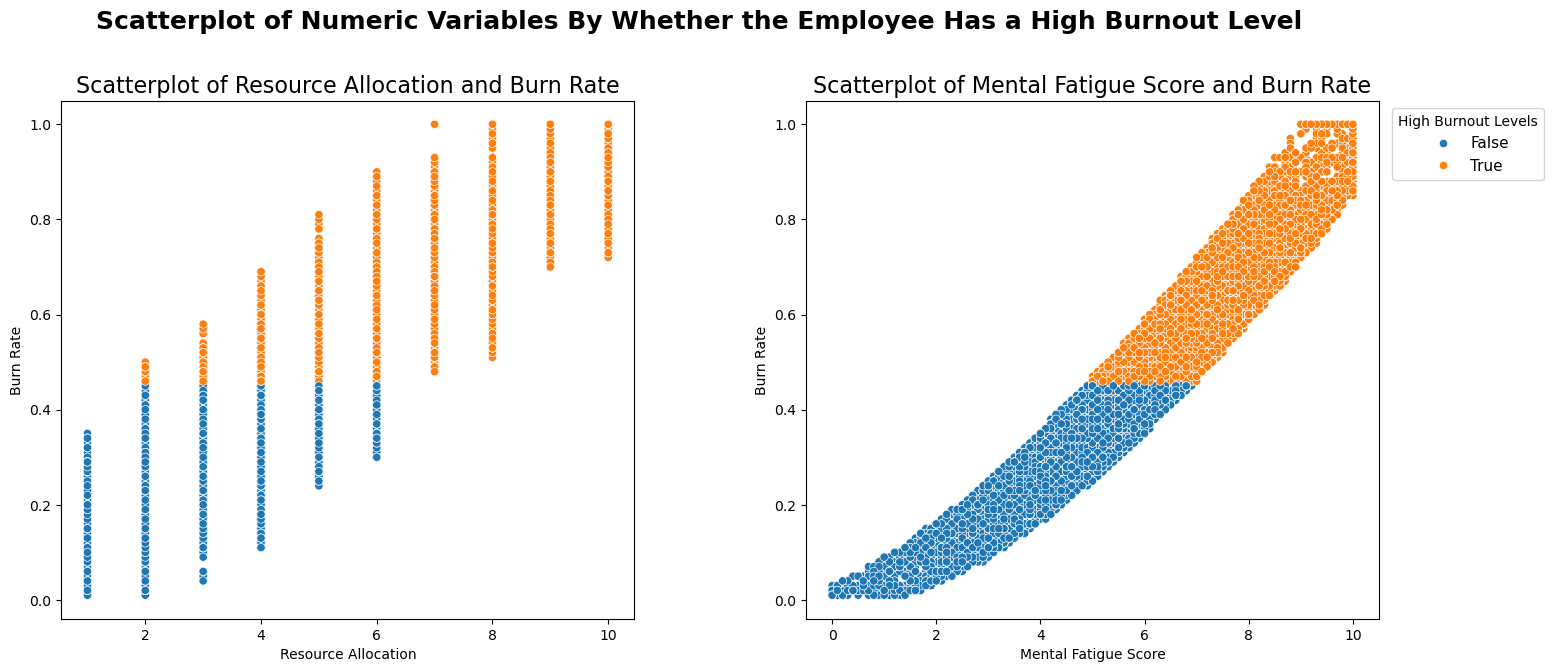

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.scatterplot(data=train, x="Resource Allocation", y="Burn Rate", hue="High Burnout", ax=axes[0], legend=False)
sns.scatterplot(data=train, x="Mental Fatigue Score", y="Burn Rate", hue="High Burnout", ax=axes[1], legend=True)

axes[0].set_title("Scatterplot of Resource Allocation and Burn Rate", fontsize=16)
axes[1].set_title("Scatterplot of Mental Fatigue Score and Burn Rate", fontsize=16)

axes[1].legend(title="High Burnout Levels", 
               bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=11)

fig.suptitle("Scatterplot of Numeric Variables By Whether the Employee Has a High Burnout Level", fontsize=18, fontweight="bold", y=0.98)
plt.subplots_adjust(hspace=0.2, wspace=0.3, top=0.85)
plt.show()

**Can we pinpoint patterns in detecting an employees burnout risk factor by the amount of hours they work as well as mental fatigue score they have**

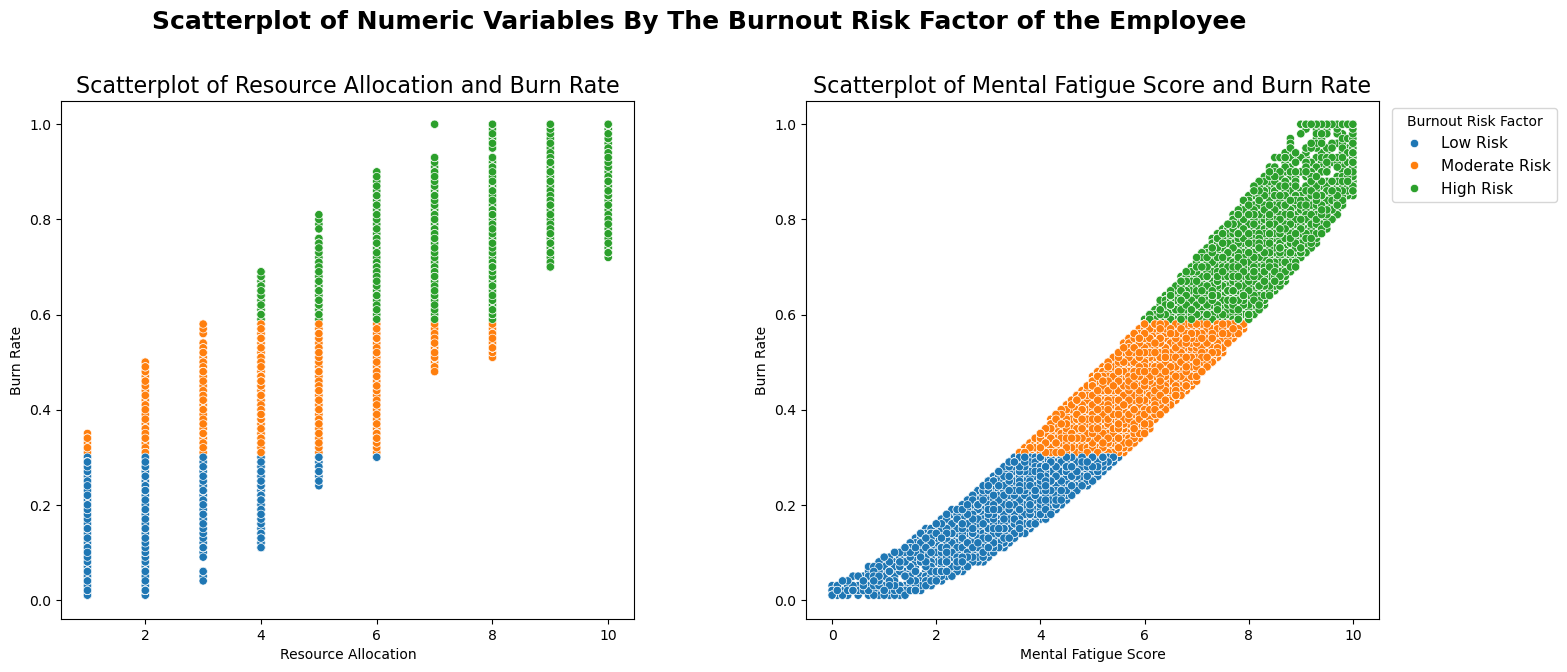

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.scatterplot(data=train, x="Resource Allocation", y="Burn Rate", hue="Burnout Risk Factor", ax=axes[0], legend=False)
sns.scatterplot(data=train, x="Mental Fatigue Score", y="Burn Rate", hue="Burnout Risk Factor", ax=axes[1], legend=True)

axes[0].set_title("Scatterplot of Resource Allocation and Burn Rate", fontsize=16)
axes[1].set_title("Scatterplot of Mental Fatigue Score and Burn Rate", fontsize=16)

axes[1].legend(title="Burnout Risk Factor", 
               bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=11)

fig.suptitle("Scatterplot of Numeric Variables By The Burnout Risk Factor of the Employee", fontsize=18, fontweight="bold", y=0.98)
plt.subplots_adjust(hspace=0.2, wspace=0.3, top=0.85)
plt.show()

**What patterns exist in determining these trends**
- working hours vs mental fatigue score by burnout risk factor 
- working hours ve mental fatigue score by High Burnout

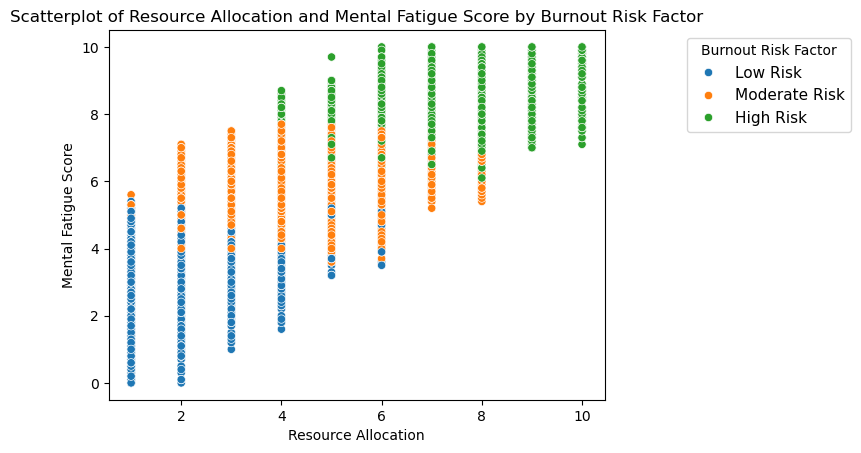

In [77]:
sns.scatterplot(data=train, x="Resource Allocation", y="Mental Fatigue Score", hue="Burnout Risk Factor")
plt.title("Scatterplot of Resource Allocation and Mental Fatigue Score by Burnout Risk Factor")
plt.legend(title="Burnout Risk Factor", 
               bbox_to_anchor=(1.15, 1), loc="upper left", fontsize=11)
plt.show()

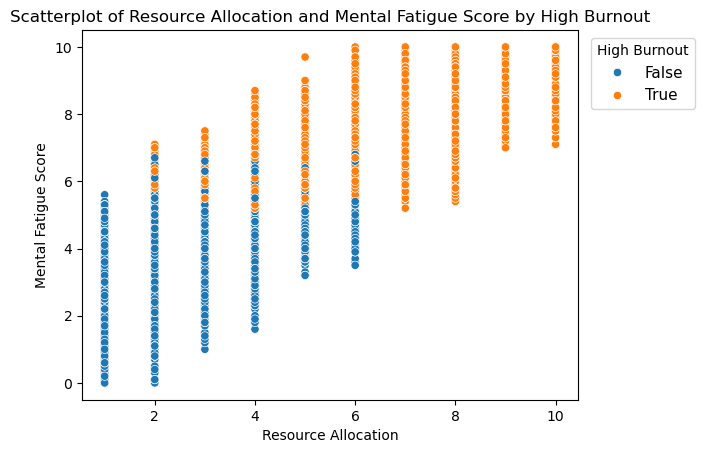

In [78]:
sns.scatterplot(data=train, x="Resource Allocation", y="Mental Fatigue Score", hue="High Burnout")
plt.title("Scatterplot of Resource Allocation and Mental Fatigue Score by High Burnout")
plt.legend(title="High Burnout", 
               bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=11)
plt.show()

**What is the composition of employees burnout risk by gender**

In [79]:
pivot2 = train.pivot_table(
    index="Gender",
    columns="Burnout Risk Factor",
    values="Join_Month_Year",
    aggfunc="count",
    fill_value=0
)

pivot2

Burnout Risk Factor,High Risk,Low Risk,Moderate Risk
Gender,,,
Female,1903,2503,5192
Male,2809,1610,4330


In [80]:
pivot2_pct = pivot2.div(pivot2.sum(axis=1), axis=0) * 100

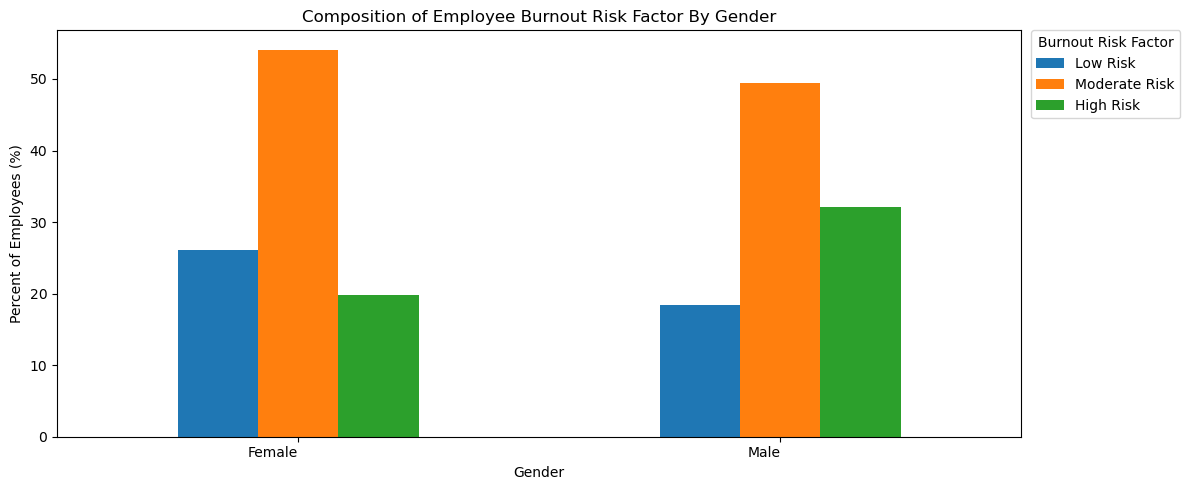

In [81]:
col_order = ["Low Risk", "Moderate Risk", "High Risk"]
x_order = train["Gender"].value_counts().index

pivot2_pct = pivot2_pct[col_order]
pivot2_pct = pivot2_pct.loc[x_order]

fig, ax = plt.subplots(figsize=(12, 5))
pivot2_pct.plot(kind="bar", ax=ax)
plt.xlabel("Gender")
plt.ylabel("Percent of Employees (%)")
plt.xticks(rotation=0, ha="right")
plt.title("Composition of Employee Burnout Risk Factor By Gender")
plt.legend(title="Burnout Risk Factor", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

**What is the composition of employees burnout risk by gender**

In [82]:
pivot3 = train.pivot_table(
    index="WFH Setup Available",
    columns="Burnout Risk Factor",
    values="Join_Month_Year",
    aggfunc="count",
    fill_value=0
)

pivot3

Burnout Risk Factor,High Risk,Low Risk,Moderate Risk
WFH Setup Available,,,
No,3288,1218,3972
Yes,1424,2895,5550


In [83]:
pivot3_pct = pivot3.div(pivot3.sum(axis=1), axis=0) * 100

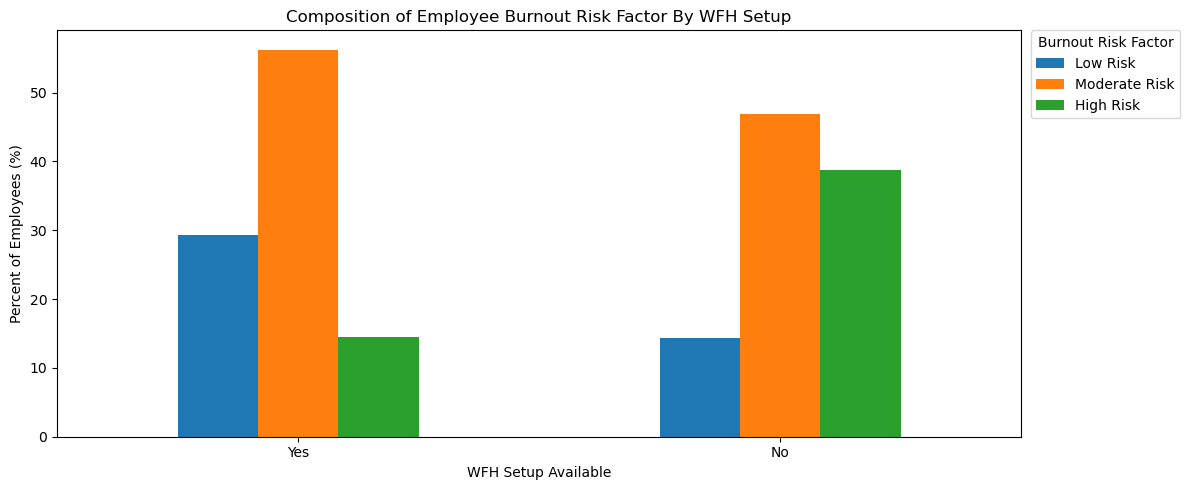

In [84]:
pivot3 = train.pivot_table(
    index="WFH Setup Available",
    columns="Burnout Risk Factor",
    values="Join_Month_Year",
    aggfunc="count",
    fill_value=0
)

pivot3_pct = pivot3.div(pivot3.sum(axis=1), axis=0) * 100

col_order = ["Low Risk", "Moderate Risk", "High Risk"]
x_order = train["WFH Setup Available"].value_counts().index
pivot3_pct = pivot3_pct.reindex(columns=col_order)
pivot3_pct = pivot3_pct.loc[x_order]

fig, ax = plt.subplots(figsize=(12, 5))
pivot3_pct.plot(kind="bar", ax=ax)
plt.xlabel("WFH Setup Available")
plt.ylabel("Percent of Employees (%)")
plt.xticks(rotation=0)
plt.title("Composition of Employee Burnout Risk Factor By WFH Setup")
plt.legend(title="Burnout Risk Factor", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

**What is the composition of employees high burnout by gender**

In [85]:
pivot4 = train.pivot_table(
    index="Gender",
    columns="High Burnout",
    values="Join_Month_Year",
    aggfunc="count",
    fill_value=0
)

pivot4

High Burnout,False,True
Gender,,
Female,5540,4058
Male,3619,5130


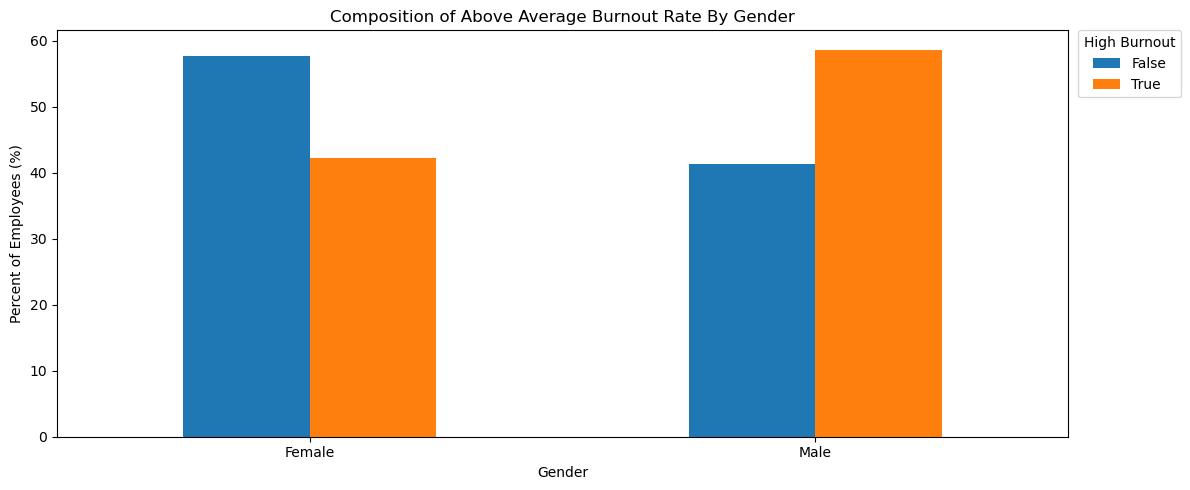

In [86]:
col_order = [False, True]
x_order = train["Gender"].value_counts().index

pivot4_pct = pivot4.div(pivot4.sum(axis=1), axis=0) * 100

pivot4_pct = pivot4_pct.loc[x_order]
pivot4_pct = pivot4_pct.reindex(columns=[False, True])

fig, ax = plt.subplots(figsize=(12, 5))
pivot4_pct.plot(kind="bar", ax=ax)
plt.xlabel("Gender")
plt.ylabel("Percent of Employees (%)")
plt.xticks(rotation=0)
plt.title("Composition of Above Average Burnout Rate By Gender")
plt.legend(title="High Burnout", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

**What are the distributions of employee burn rate by groups (gender, company type high burnout) and WFH hsetup**

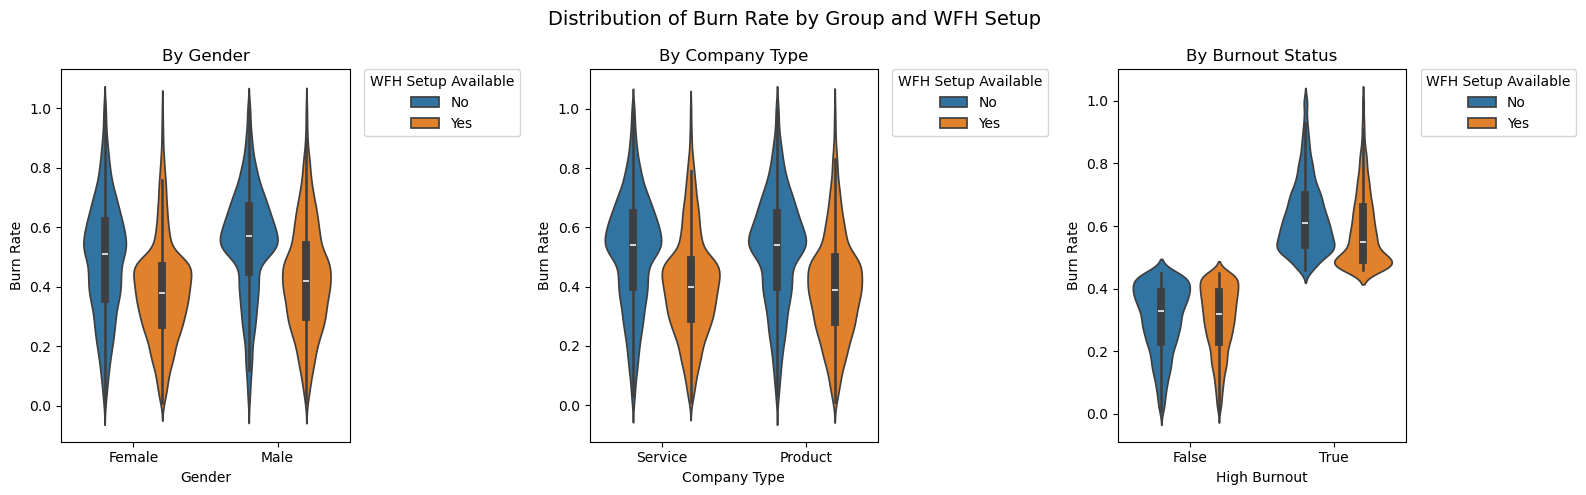

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribution of Burn Rate by Group and WFH Setup", fontsize=14)

sns.violinplot(data=train, x="Gender", y="Burn Rate", hue="WFH Setup Available", ax=axes[0])
axes[0].set_title("By Gender")
axes[0].legend(title="WFH Setup Available", bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)

sns.violinplot(data=train, x="Company Type", y="Burn Rate", hue="WFH Setup Available", ax=axes[1])
axes[1].set_title("By Company Type")
axes[1].legend(title="WFH Setup Available", bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)

sns.violinplot(data=train, x="High Burnout", y="Burn Rate", hue="WFH Setup Available", ax=axes[2])
axes[2].set_title("By Burnout Status")
axes[2].legend(title="WFH Setup Available", bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

**What is the distribution of burn rate by seniority level by working from home status**

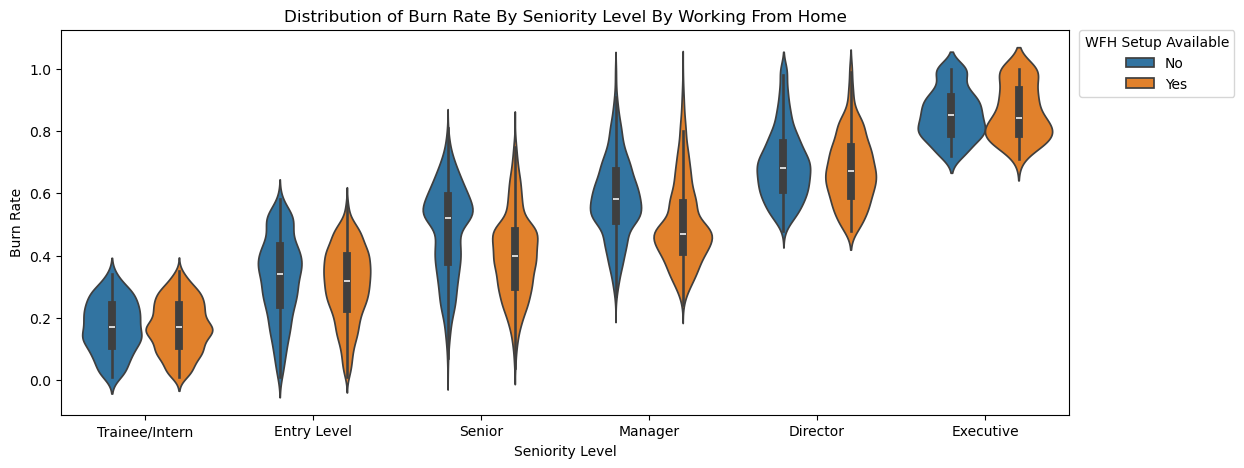

In [88]:
seniority_order = ["Trainee/Intern","Entry Level", "Senior", "Manager", "Director","Executive"]

plt.figure(figsize=(13, 5))
plt.title("Distribution of Burn Rate By Seniority Level By Working From Home")
sns.violinplot(data=train, x="Seniority Level", y="Burn Rate", hue="WFH Setup Available", order=seniority_order)
plt.legend(title="WFH Setup Available", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.show()

**How does the mean burn rate vary by seniority level and WFH Setup**

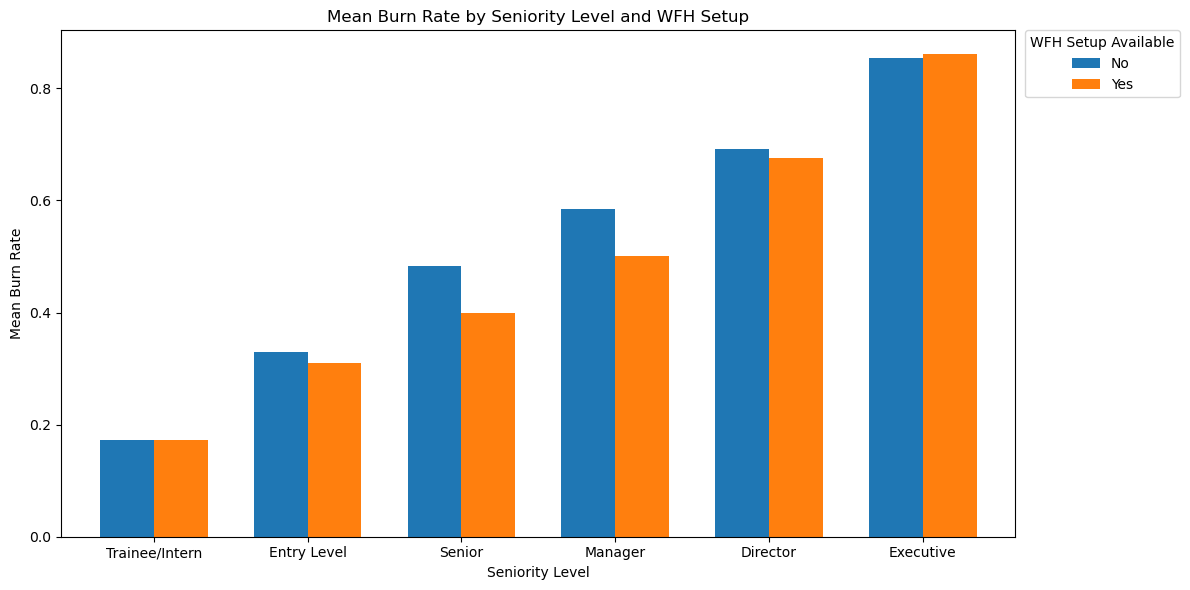

In [89]:
pivot_heat = train.pivot_table(
    index="Seniority Level",
    columns="WFH Setup Available",
    values="Burn Rate",
    aggfunc="mean"
).reindex(["Trainee/Intern","Entry Level", "Senior", "Manager", "Director","Executive"])

pivot_heat.plot(kind="bar", figsize=(12, 6), width=0.7)
plt.title("Mean Burn Rate by Seniority Level and WFH Setup")
plt.xlabel("Seniority Level")
plt.ylabel("Mean Burn Rate")
plt.xticks(rotation=0)
plt.legend(title="WFH Setup Available", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

**How does the mean Tenure vary by seniority level and WFH Setup**

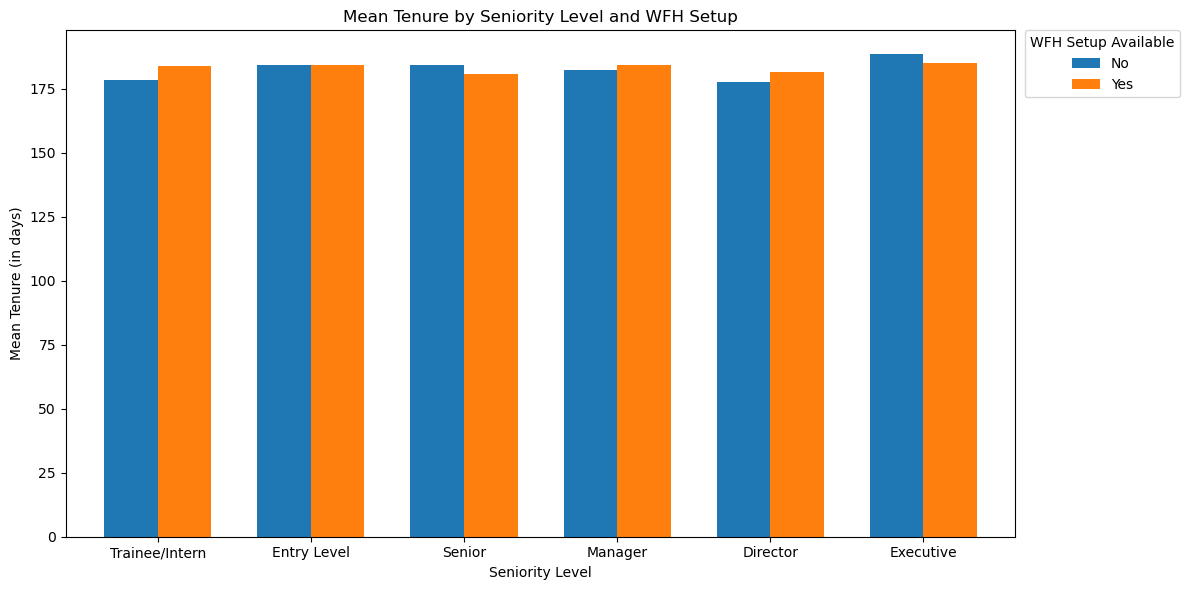

In [90]:
pivot_heat = train.pivot_table(
    index="Seniority Level",
    columns="WFH Setup Available",
    values="days_since_joined",
    aggfunc="mean"
).reindex(["Trainee/Intern","Entry Level", "Senior", "Manager", "Director","Executive"])

pivot_heat.plot(kind="bar", figsize=(12, 6), width=0.7)
plt.title("Mean Tenure by Seniority Level and WFH Setup")
plt.xlabel("Seniority Level")
plt.ylabel("Mean Tenure (in days)")
plt.xticks(rotation=0)
plt.legend(title="WFH Setup Available", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

**How does the mean Tenure vary by compnay type and WFH Setup**

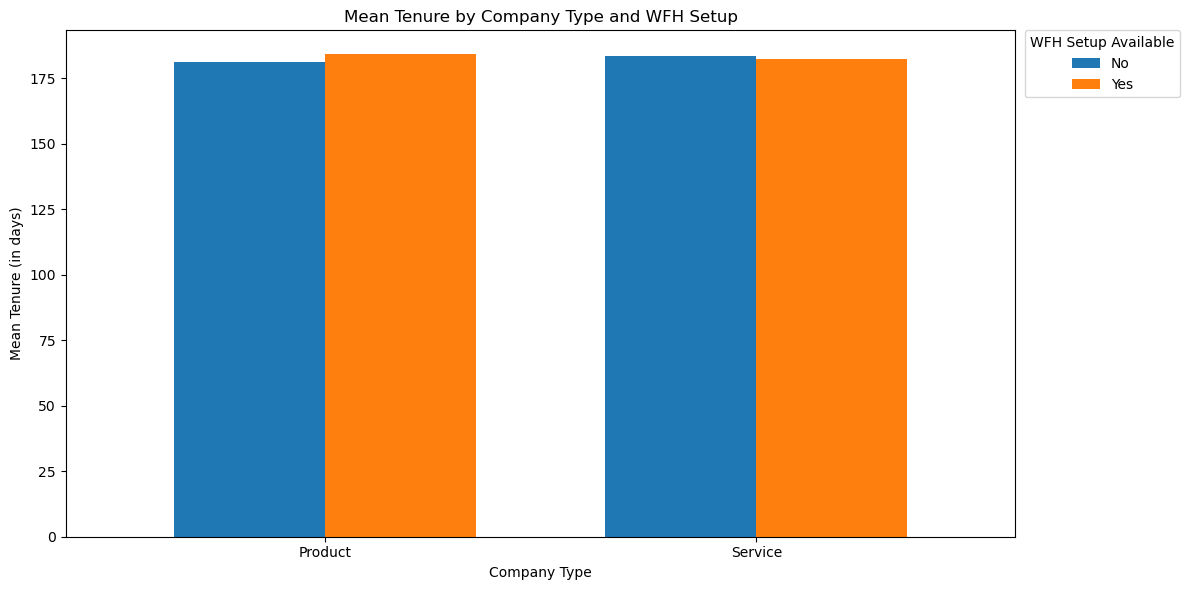

In [91]:
pivot_heat = train.pivot_table(
    index="Company Type",
    columns="WFH Setup Available",
    values="days_since_joined",
    aggfunc="mean"
)

pivot_heat.plot(kind="bar", figsize=(12, 6), width=0.7)
plt.title("Mean Tenure by Company Type and WFH Setup")
plt.xlabel("Company Type")
plt.ylabel("Mean Tenure (in days)")
plt.xticks(rotation=0)
plt.legend(title="WFH Setup Available", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

**How does the mean Tenure vary by Gender and WFH Setup****

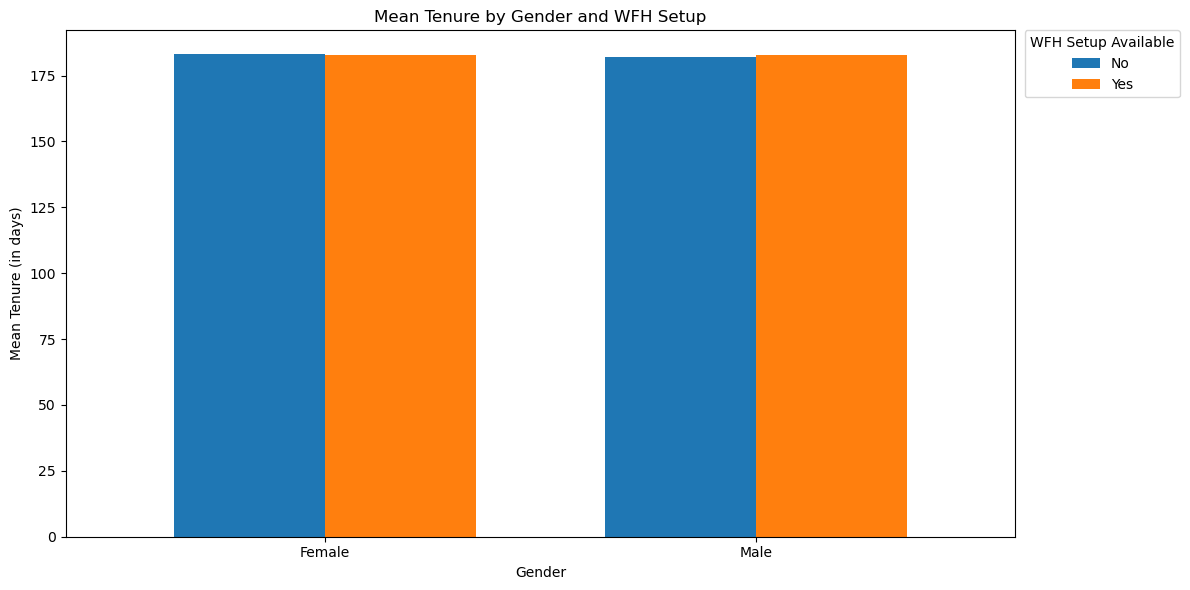

In [92]:
pivot_heat = train.pivot_table(
    index="Gender",
    columns="WFH Setup Available",
    values="days_since_joined",
    aggfunc="mean"
)

pivot_heat.plot(kind="bar", figsize=(12, 6), width=0.7)
plt.title("Mean Tenure by Gender and WFH Setup")
plt.xlabel("Gender")
plt.ylabel("Mean Tenure (in days)")
plt.xticks(rotation=0)
plt.legend(title="WFH Setup Available", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

**Remove Outliers from Training Dataset**

In [93]:
numerics = train[["Resource Allocation", "Mental Fatigue Score", "Burn Rate"]]

q1 = numerics.quantile(0.25)
q3 = numerics.quantile(0.75)
iqr_vals = q3 - q1

mask = ~((numerics < (q1 - 1.5 * iqr_vals)) | (numerics > (q3 + 1.5 * iqr_vals))).any(axis=1)
train = train[mask]

print(train.shape)

(18196, 22)


**Perform hypothesis tests on the following categorical variables to see if they have an effect on burn rate**
- Company Type 
- Gender
- Seniority Level
- Working From Home Setup

**Hypothesis Test 1**
- Research Question: Is there a difference in employee burn rate by Company Type? 
- Null Hypothesis: There is no statistically significant difference in employee burn rate by company type
- Alternative Hypothesis: There is a statistically significant difference in employee burn rate across company types.

- Conclusion: The hypothesis test indicated that there is no statistically significant difference in employee burn rate by company type as the p value of 0.5682 exceeds the alpha threshold of 0.05. The effect size of this hypothesis test is 0.0089, which is neglible. 

In [94]:
#step 1: Check if the burn rate is approximately normally distributed within each company type group 

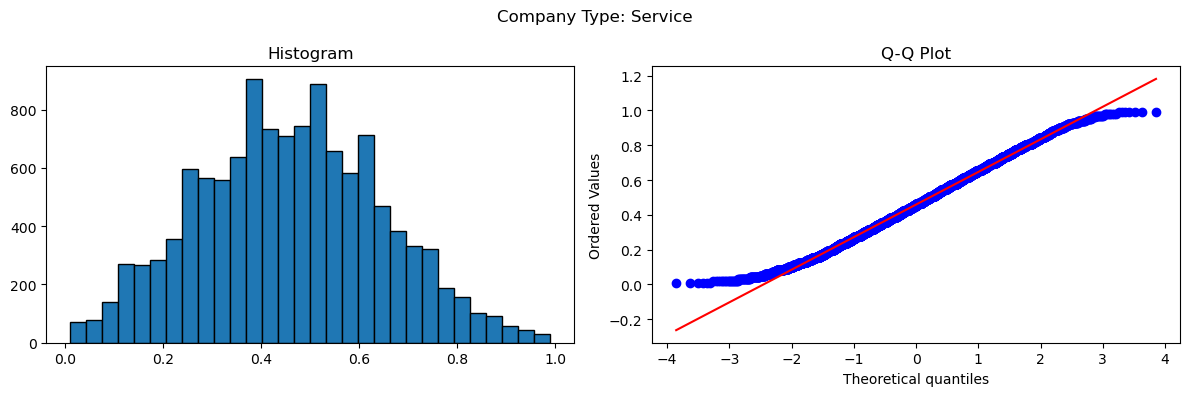

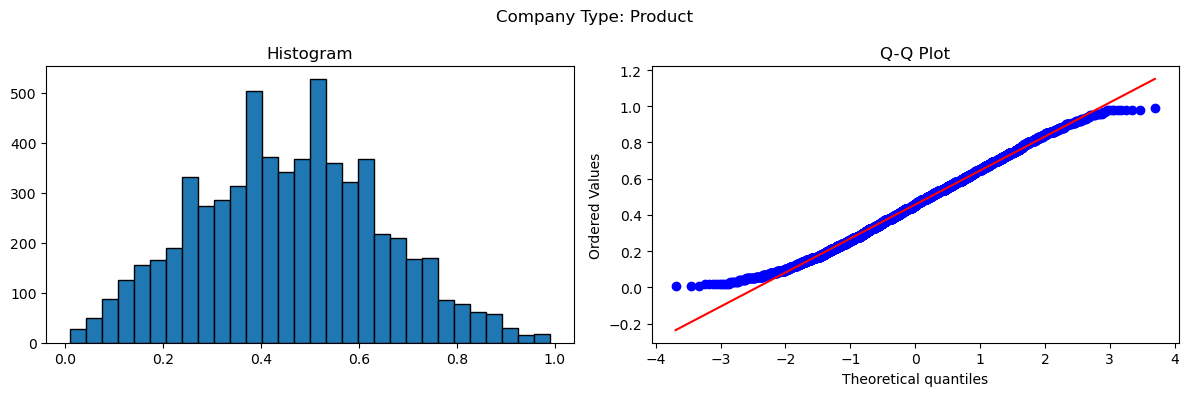

In [95]:
import scipy.stats as stats

for company in train["Company Type"].unique():
    subset = train[train["Company Type"] == company]["Burn Rate"].dropna()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Company Type: {company}")
    
    axes[0].hist(subset, bins=30, edgecolor="black")
    axes[0].set_title("Histogram")
    
    stats.probplot(subset, plot=axes[1])
    axes[1].set_title("Q-Q Plot")
    
    plt.tight_layout()
    plt.show()

In [96]:
service = train[train["Company Type"] == "Service"]["Burn Rate"].dropna()
product = train[train["Company Type"] == "Product"]["Burn Rate"].dropna()

In [97]:
from scipy.stats import ttest_ind
import numpy as np
stat, p = ttest_ind(service, product, equal_var=False) 
print(f"T-Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

T-Statistic: 0.5708
P-value: 0.5682


In [98]:
alpha = 0.05
if p < alpha:
    print("Reject H₀ — Burn Rate differs significantly between Company Types")
else:
    print("Fail to reject H₀ — No significant difference in Burn Rate between Company Types")

Fail to reject H₀ — No significant difference in Burn Rate between Company Types


In [99]:
cohen_d = (service.mean() - product.mean()) / np.sqrt((service.std()**2 + product.std()**2) / 2)
print(f"Effect size (Cohen's d): {cohen_d:.4f}")

Effect size (Cohen's d): 0.0089


**Hypothesis Test 2**
- Research Question: Is there a difference in employee burn rate by Gender? 
- Null Hypothesis: There is no statistically significant difference in employee burn rate by Gender
- Alternative Hypothesis: There is a statistically significant difference in employee burn rate by Gender .

- Conclusion: There is a statistically significant difference in employee burn rate by Gender, as the p-value of 0.0000 is below the alpha threshold of 0.05. The effect size (Cohen's d = 0.3215) is small, suggesting the difference, while statistically significant, has limited practical magnitude. 

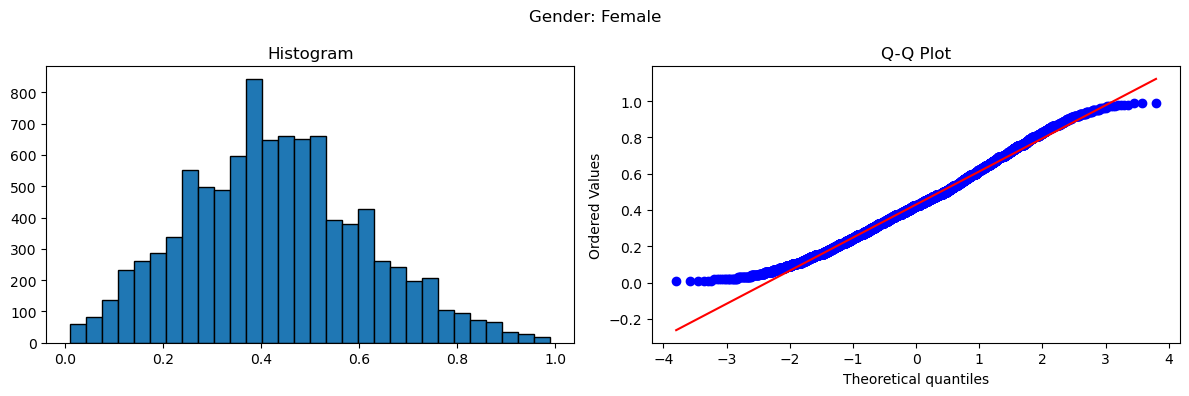

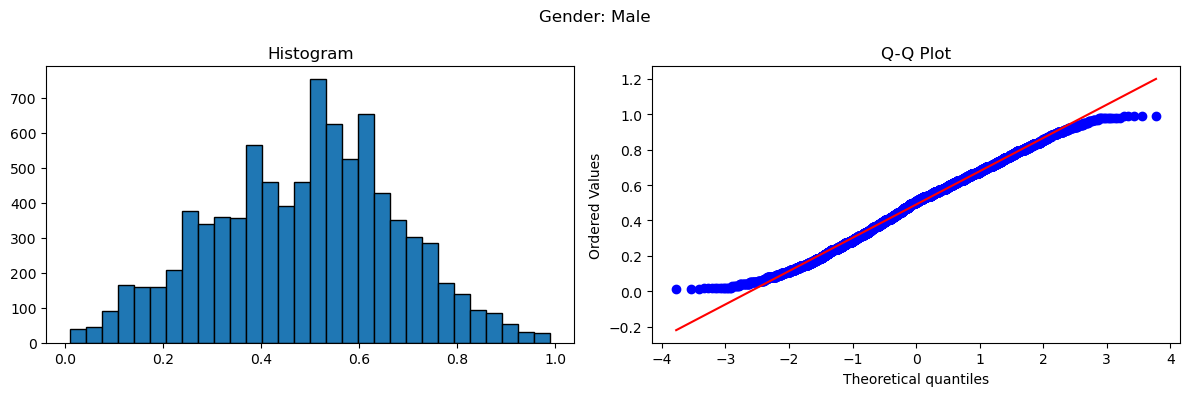

In [100]:
import scipy.stats as stats

for gender in train["Gender"].unique():
    subset = train[train["Gender"] == gender]["Burn Rate"].dropna()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Gender: {gender}")  
    
    axes[0].hist(subset, bins=30, edgecolor="black")
    axes[0].set_title("Histogram")
    
    stats.probplot(subset, plot=axes[1])
    axes[1].set_title("Q-Q Plot")
    
    plt.tight_layout()
    plt.show()

In [101]:
male = train[train["Gender"] == "Male"]["Burn Rate"].dropna()
female = train[train["Gender"] == "Female"]["Burn Rate"].dropna()

In [102]:
stat, p = ttest_ind(male, female, equal_var=False) 
print(f"T-Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

T-Statistic: 21.6466
P-value: 0.0000


In [103]:
alpha = 0.05
if p < alpha:
    print("Reject H₀ — Burn Rate differs significantly by Gender")
else:
    print("Fail to reject H₀ — No significant difference in Burn Rate by Gender")

Reject H₀ — Burn Rate differs significantly by Gender


In [104]:
cohen_d = (male.mean() - female.mean()) / np.sqrt((male.std()**2 + female.std()**2) / 2)
print(f"Effect size (Cohen's d): {cohen_d:.4f}")

Effect size (Cohen's d): 0.3215


**Hypothesis Test 3**
Use the Krusal-Wallis Test as there are more than 2 groups

- Research Question: Is there a difference in employee burn rate by Seniority Level? 
- Null Hypothesis: There is no statistically significant difference in employee burn rate by Seniority Level
- Alternative Hypothesis: There is a statistically significant difference in employee burn rate by Seniority Level.

Conclusion: There is a statistically significant difference in employee burn rate by Seniority Level, as the p-value of 0.0000 is below the alpha threshold of 0.05. The effect size (η² = 0.5033) is large, which means the practical magnitude of the difference in employee burn rate by Seniority Level is substantial.

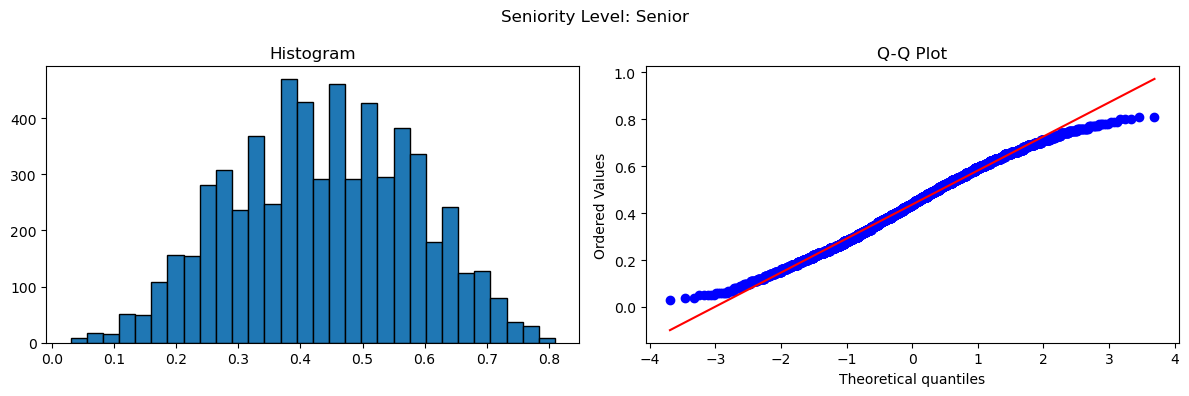

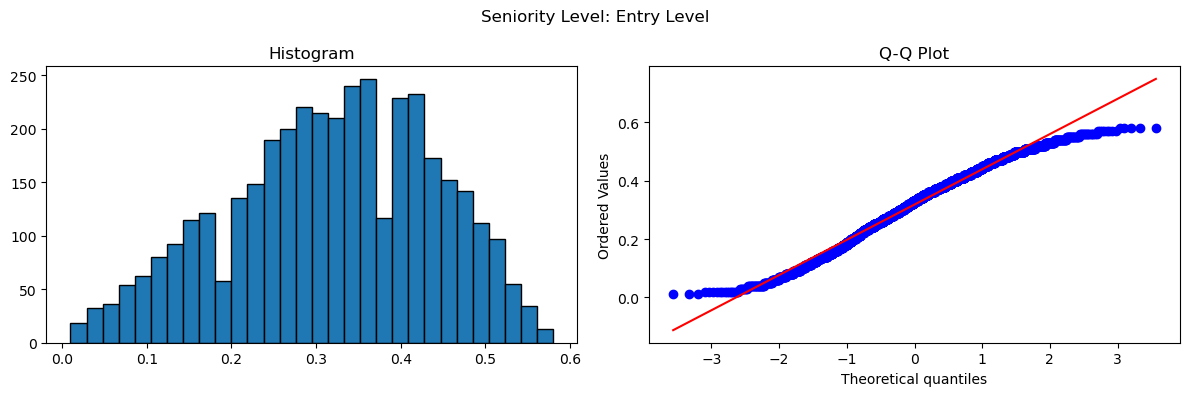

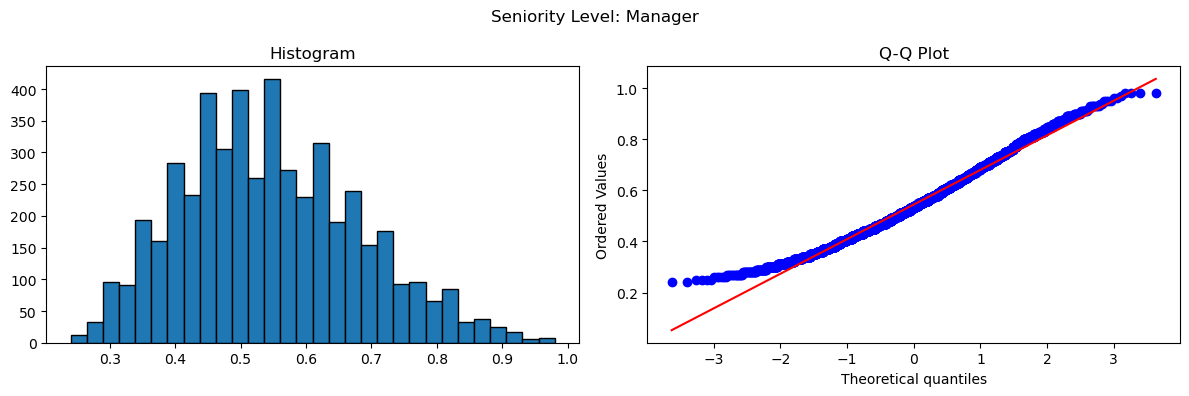

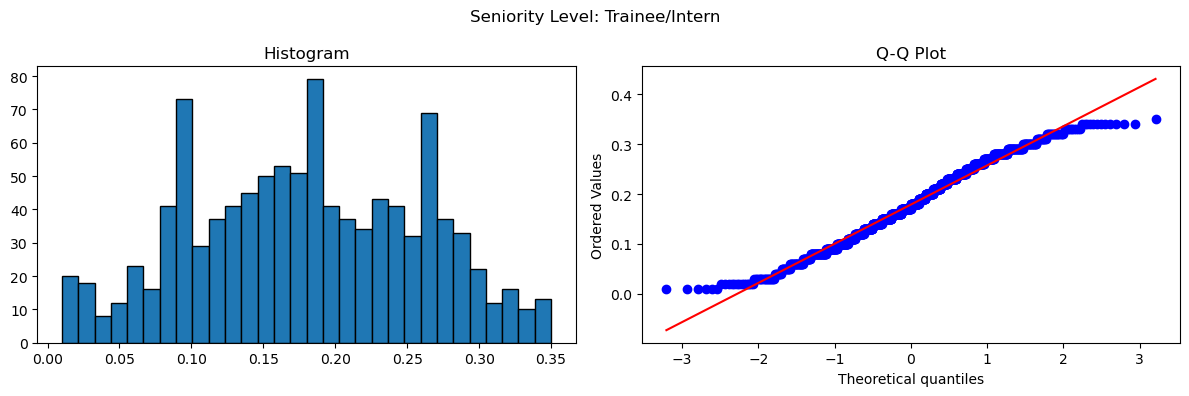

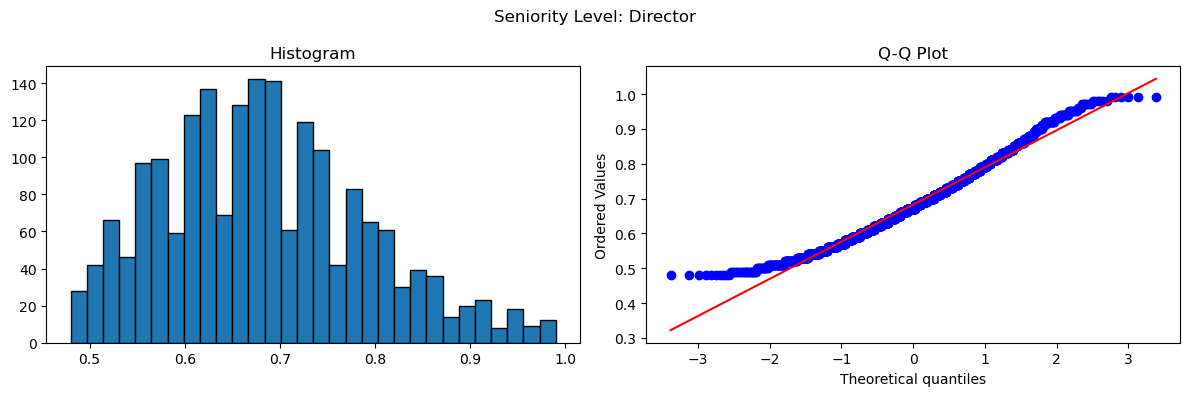

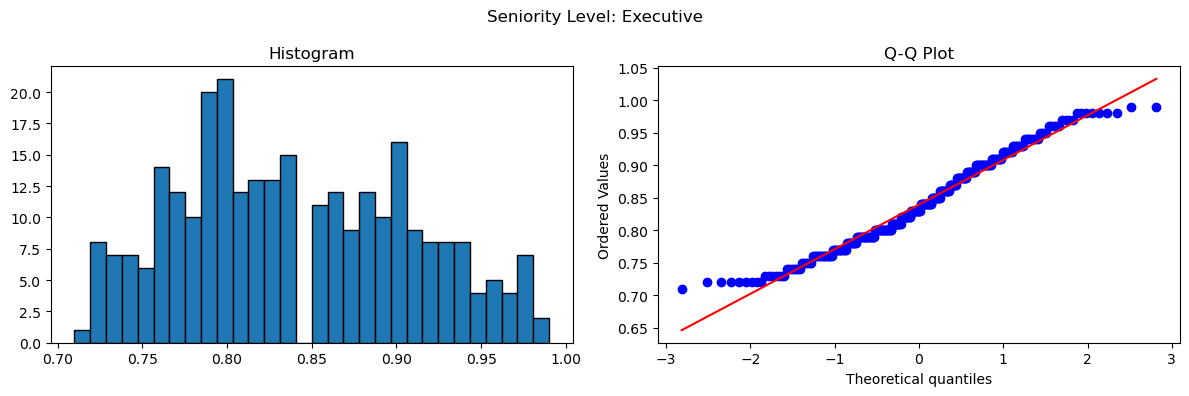

In [105]:
import scipy.stats as stats

for seniority in train["Seniority Level"].unique():
    subset = train[train["Seniority Level"] == seniority]["Burn Rate"].dropna()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Seniority Level: {seniority}")  
    
    axes[0].hist(subset, bins=30, edgecolor="black")
    axes[0].set_title("Histogram")
    
    stats.probplot(subset, plot=axes[1])
    axes[1].set_title("Q-Q Plot")
    
    plt.tight_layout()
    plt.show()

In [106]:
from scipy.stats import kruskal

In [107]:
groups = [train[train["Seniority Level"] == level]["Burn Rate"].dropna() 
          for level in train["Seniority Level"].unique()]

In [108]:
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H-Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

Kruskal-Wallis H-Statistic: 9159.9757
P-value: 0.0000


In [109]:
alpha = 0.05
if p < alpha:
    print("Reject H₀ — Burn Rate differs significantly by Seniority Level")
else:
    print("Fail to reject H₀ — No significant difference in Burn Rate by Seniority Level")

Reject H₀ — Burn Rate differs significantly by Seniority Level


In [110]:
n = sum(len(g) for g in groups)
eta_squared = (stat - len(groups) + 1) / (n - len(groups))
print(f"Effect size (η²): {eta_squared:.4f}")

Effect size (η²): 0.5033


**Hypothesis Test 4**
- Research Question: Is there a difference in employee burn rate by Working From Home Setup? 
- Null Hypothesis: There is no statistically significant difference in employee burn rate by Working From Home Setup
- Alternative Hypothesis: There is a statistically significant difference in employee burn rate by Working From Home Setup.

- Conclusion: There is a statistically significant difference in employee burn rate by Working From Home Setup, as the p-value of 0.0000 is below the alpha threshold of 0.05. The effect size (Cohen's d = -0.6638) is small, suggesting the difference, while statistically significant, has limited practical magnitude. 

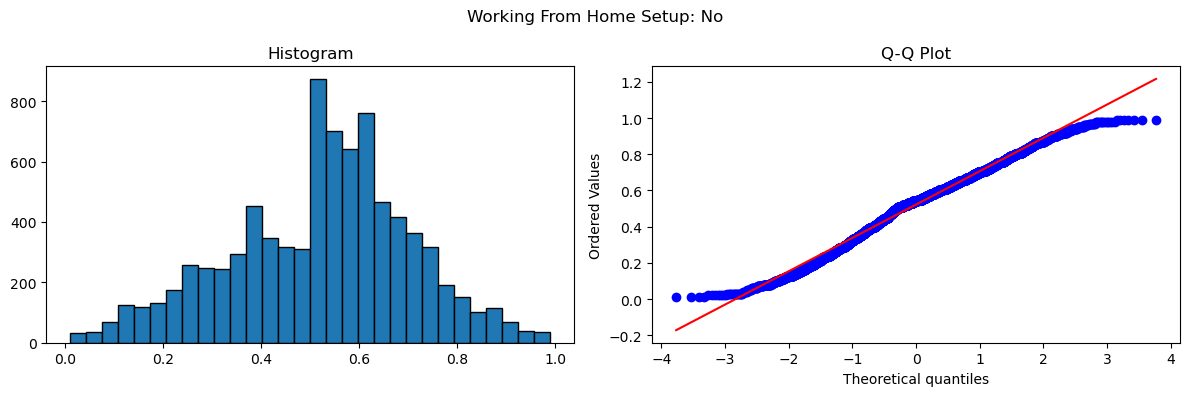

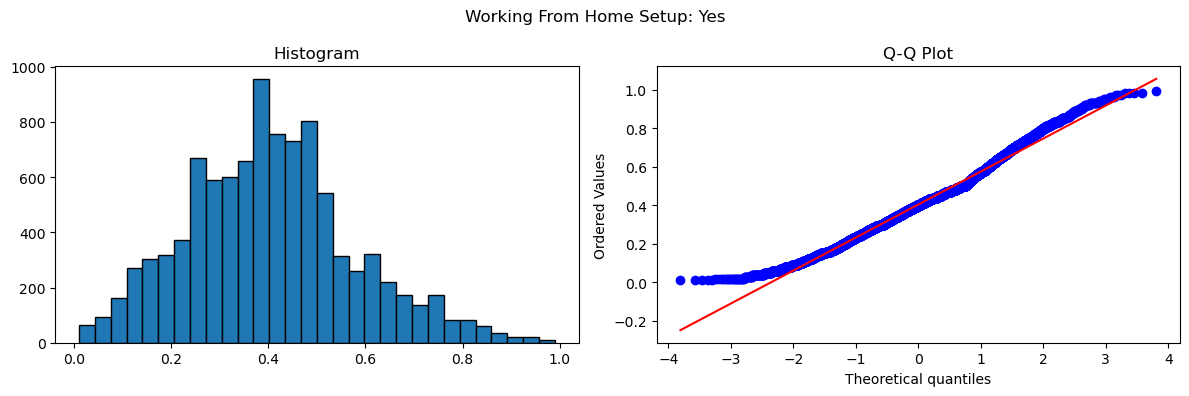

In [111]:
import scipy.stats as stats

for WFH in train["WFH Setup Available"].unique():
    subset = train[train["WFH Setup Available"] == WFH]["Burn Rate"].dropna()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Working From Home Setup: {WFH}")  
    
    axes[0].hist(subset, bins=30, edgecolor="black")
    axes[0].set_title("Histogram")
    
    stats.probplot(subset, plot=axes[1])
    axes[1].set_title("Q-Q Plot")
    
    plt.tight_layout()
    plt.show()

In [112]:
WFH_Yes = train[train["WFH Setup Available"] == "Yes"]["Burn Rate"].dropna()
WFH_No = train[train["WFH Setup Available"] == "No"]["Burn Rate"].dropna()

In [113]:
stat, p = ttest_ind(WFH_Yes, WFH_No, equal_var=False) 
print(f"T-Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

T-Statistic: -44.5130
P-value: 0.0000


In [114]:
alpha = 0.05
if p < alpha:
    print("Reject H₀ — Burn Rate differs significantly in Burn Rate by WFH Setup Available")
else:
    print("Fail to reject H₀ — No significant difference in Burn Rate by WFH Setup Available")

Reject H₀ — Burn Rate differs significantly in Burn Rate by WFH Setup Available


In [115]:
cohen_d = (WFH_Yes.mean() - WFH_No.mean()) / np.sqrt((WFH_Yes.std()**2 + WFH_No.std()**2) / 2)
print(f"Effect size (Cohen's d): {cohen_d:.4f}")

Effect size (Cohen's d): -0.6638


**Machine Learning Problems**

In [116]:
train.dtypes

Gender                                          str
Company Type                                    str
WFH Setup Available                             str
Designation                                   int64
Resource Allocation                         float64
Mental Fatigue Score                        float64
Burn Rate                                   float64
Gender_Female                                  bool
Gender_Male                                    bool
WFH Setup Available_No                         bool
WFH Setup Available_Yes                        bool
Company Type_Product                           bool
Company Type_Service                           bool
Join_Month_Year                                 str
days_since_joined                             int64
Seniority Level                              object
High Burnout                                   bool
Burnout Risk Factor                             str
Burnout Risk Factor_High Risk                  bool
Burnout Risk

**Feature Engineering**

In [117]:
train["Workload Fatigue Interaction"] = train["Resource Allocation"] * train["Mental Fatigue Score"]
train.head(5)

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Gender_Female,Gender_Male,WFH Setup Available_No,...,Join_Month_Year,days_since_joined,Seniority Level,High Burnout,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk,Join_Month_Year_Sort,Workload Fatigue Interaction
0,Female,Service,No,2,3.0,3.8,0.16,True,False,True,...,September 2008,92,Senior,False,Low Risk,False,True,False,2008-09-01,11.4
1,Male,Service,Yes,1,2.0,5.0,0.36,False,True,False,...,November 2008,31,Entry Level,False,Moderate Risk,False,False,True,2008-11-01,10.0
3,Male,Service,Yes,1,1.0,2.6,0.20,False,True,False,...,November 2008,58,Entry Level,False,Low Risk,False,True,False,2008-11-01,2.6
4,Female,Service,No,3,7.0,6.9,0.52,True,False,True,...,July 2008,160,Manager,True,Moderate Risk,False,False,True,2008-07-01,48.3
5,Male,Product,Yes,2,4.0,3.6,0.29,False,True,False,...,November 2008,35,Senior,False,Low Risk,False,True,False,2008-11-01,14.4


In [118]:
train["Fatigue Ratio"] = train["Mental Fatigue Score"] / train["Resource Allocation"]
train.head(5)

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Gender_Female,Gender_Male,WFH Setup Available_No,...,days_since_joined,Seniority Level,High Burnout,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk,Join_Month_Year_Sort,Workload Fatigue Interaction,Fatigue Ratio
0,Female,Service,No,2,3.0,3.8,0.16,True,False,True,...,92,Senior,False,Low Risk,False,True,False,2008-09-01,11.4,1.266667
1,Male,Service,Yes,1,2.0,5.0,0.36,False,True,False,...,31,Entry Level,False,Moderate Risk,False,False,True,2008-11-01,10.0,2.500000
3,Male,Service,Yes,1,1.0,2.6,0.20,False,True,False,...,58,Entry Level,False,Low Risk,False,True,False,2008-11-01,2.6,2.600000
4,Female,Service,No,3,7.0,6.9,0.52,True,False,True,...,160,Manager,True,Moderate Risk,False,False,True,2008-07-01,48.3,0.985714
5,Male,Product,Yes,2,4.0,3.6,0.29,False,True,False,...,35,Senior,False,Low Risk,False,True,False,2008-11-01,14.4,0.900000


In [119]:
train["High Workload"] = np.where(train["Resource Allocation"] > train["Resource Allocation"].median(), True, False)
train.head(5)

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Gender_Female,Gender_Male,WFH Setup Available_No,...,Seniority Level,High Burnout,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk,Join_Month_Year_Sort,Workload Fatigue Interaction,Fatigue Ratio,High Workload
0,Female,Service,No,2,3.0,3.8,0.16,True,False,True,...,Senior,False,Low Risk,False,True,False,2008-09-01,11.4,1.266667,False
1,Male,Service,Yes,1,2.0,5.0,0.36,False,True,False,...,Entry Level,False,Moderate Risk,False,False,True,2008-11-01,10.0,2.500000,False
3,Male,Service,Yes,1,1.0,2.6,0.20,False,True,False,...,Entry Level,False,Low Risk,False,True,False,2008-11-01,2.6,2.600000,False
4,Female,Service,No,3,7.0,6.9,0.52,True,False,True,...,Manager,True,Moderate Risk,False,False,True,2008-07-01,48.3,0.985714,True
5,Male,Product,Yes,2,4.0,3.6,0.29,False,True,False,...,Senior,False,Low Risk,False,True,False,2008-11-01,14.4,0.900000,False


In [120]:
train["High Fatigue"] = np.where(train["Mental Fatigue Score"] > train["Mental Fatigue Score"].median(), True, False)
train.head(5)

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Gender_Female,Gender_Male,WFH Setup Available_No,...,High Burnout,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk,Join_Month_Year_Sort,Workload Fatigue Interaction,Fatigue Ratio,High Workload,High Fatigue
0,Female,Service,No,2,3.0,3.8,0.16,True,False,True,...,False,Low Risk,False,True,False,2008-09-01,11.4,1.266667,False,False
1,Male,Service,Yes,1,2.0,5.0,0.36,False,True,False,...,False,Moderate Risk,False,False,True,2008-11-01,10.0,2.500000,False,False
3,Male,Service,Yes,1,1.0,2.6,0.20,False,True,False,...,False,Low Risk,False,True,False,2008-11-01,2.6,2.600000,False,False
4,Female,Service,No,3,7.0,6.9,0.52,True,False,True,...,True,Moderate Risk,False,False,True,2008-07-01,48.3,0.985714,True,True
5,Male,Product,Yes,2,4.0,3.6,0.29,False,True,False,...,False,Low Risk,False,True,False,2008-11-01,14.4,0.900000,False,False


In [121]:
train["Stress Index"] = 0.7 * train["Mental Fatigue Score"] + 0.3 * train["Resource Allocation"]
train.head(5)

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Gender_Female,Gender_Male,WFH Setup Available_No,...,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk,Join_Month_Year_Sort,Workload Fatigue Interaction,Fatigue Ratio,High Workload,High Fatigue,Stress Index
0,Female,Service,No,2,3.0,3.8,0.16,True,False,True,...,Low Risk,False,True,False,2008-09-01,11.4,1.266667,False,False,3.56
1,Male,Service,Yes,1,2.0,5.0,0.36,False,True,False,...,Moderate Risk,False,False,True,2008-11-01,10.0,2.500000,False,False,4.10
3,Male,Service,Yes,1,1.0,2.6,0.20,False,True,False,...,Low Risk,False,True,False,2008-11-01,2.6,2.600000,False,False,2.12
4,Female,Service,No,3,7.0,6.9,0.52,True,False,True,...,Moderate Risk,False,False,True,2008-07-01,48.3,0.985714,True,True,6.93
5,Male,Product,Yes,2,4.0,3.6,0.29,False,True,False,...,Low Risk,False,True,False,2008-11-01,14.4,0.900000,False,False,3.72


In [122]:
train1 = train.copy()

In [123]:
train1 = train1[["Company Type_Product", "Company Type_Service", "Gender", "Seniority Level", "WFH Setup Available", "Gender_Female", "Gender_Male", "WFH Setup Available_No", "WFH Setup Available_Yes", "Resource Allocation", "Designation", "Mental Fatigue Score", 
                 "Workload Fatigue Interaction", "Fatigue Ratio","High Workload", "High Fatigue", "Stress Index", "days_since_joined",
                 "High Burnout", "Burn Rate"]]
train1.head(5)

,Company Type_Product,Company Type_Service,Gender,Seniority Level,WFH Setup Available,Gender_Female,Gender_Male,WFH Setup Available_No,WFH Setup Available_Yes,Resource Allocation,Designation,Mental Fatigue Score,Workload Fatigue Interaction,Fatigue Ratio,High Workload,High Fatigue,Stress Index,days_since_joined,High Burnout,Burn Rate
0,False,True,Female,Senior,No,True,False,True,False,3.0,2,3.8,11.4,1.266667,False,False,3.56,92,False,0.16
1,False,True,Male,Entry Level,Yes,False,True,False,True,2.0,1,5.0,10.0,2.500000,False,False,4.10,31,False,0.36
3,False,True,Male,Entry Level,Yes,False,True,False,True,1.0,1,2.6,2.6,2.600000,False,False,2.12,58,False,0.20
4,False,True,Female,Manager,No,True,False,True,False,7.0,3,6.9,48.3,0.985714,True,True,6.93,160,True,0.52
5,True,False,Male,Senior,Yes,False,True,False,True,4.0,2,3.6,14.4,0.900000,False,False,3.72,35,False,0.29


In [124]:
from sklearn.cluster import KMeans 
from sklearn import metrics 

In [125]:
selected_feature1 = "Stress Index"
selected_feature2 = "Burn Rate"
X = train1[[selected_feature1, selected_feature2]]
maxk = 13
wcss = []
sil_score = []

In [126]:
for k in range(1, maxk):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    wcss.append(km.inertia_)
    if k > 1:
        sil_score.append(metrics.silhouette_score(X, km.labels_, metric="euclidean"))

C:\Users\alexh\anaconda3\envs\ds_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


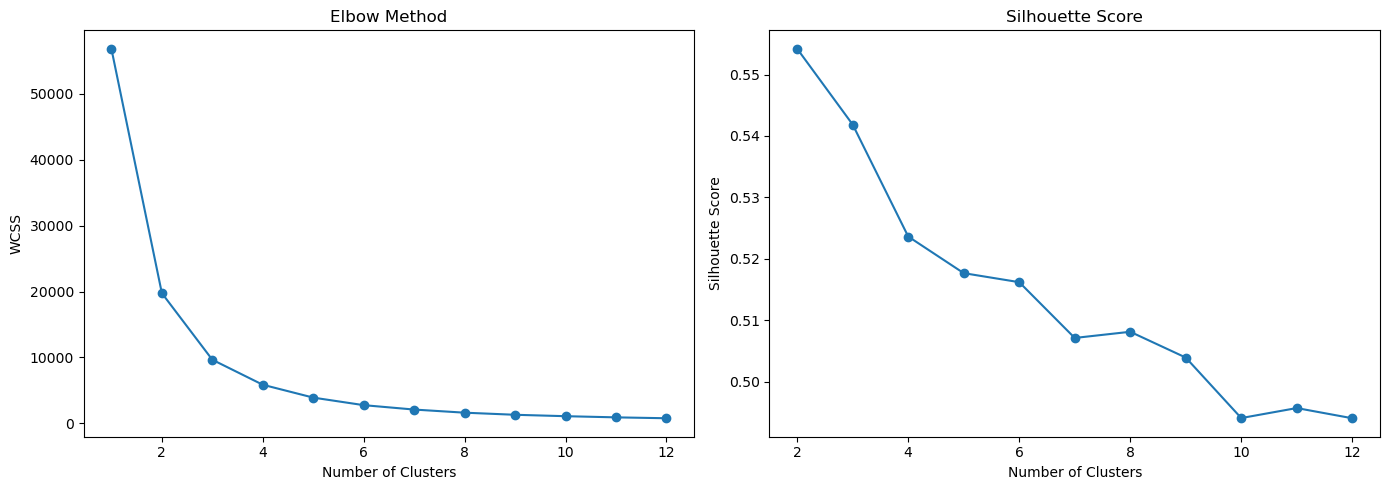

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, maxk), wcss, "o-")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("WCSS")
axes[1].plot(range(2, maxk), sil_score, "o-")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

In [128]:
#use 3 clusters 

In [129]:
num_clusters = 3
Kmean = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
Kmean.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [130]:
Kmean.cluster_centers_

array([[5.30837618, 0.44151433],
       [7.4313129 , 0.66650602],
       [3.10201221, 0.22433416]])

In [131]:
cluster_names = {
    0: "Moderate Stress Moderate Burnout",
    1: "High Stress High Burnout",
    2: "Low Stress Low Burnout"
}

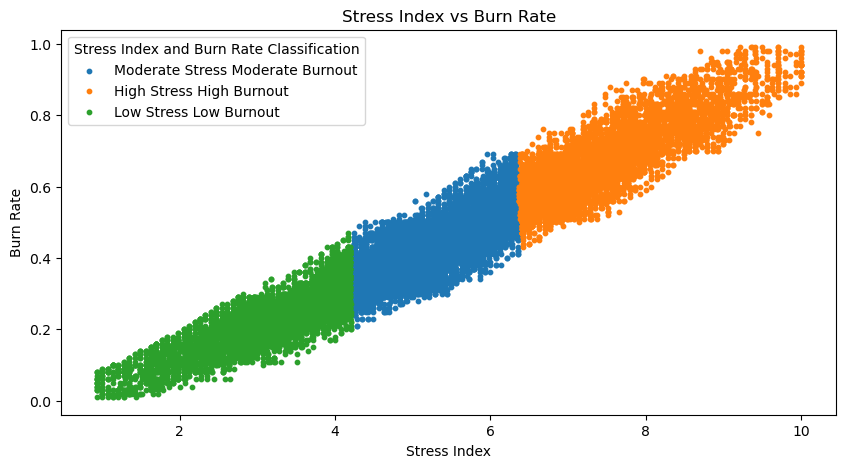

In [132]:
plt.figure(figsize=(10, 5))
plt.title(f"{selected_feature1} vs {selected_feature2}")
for cluster in np.unique(Kmean.labels_):
    mask = Kmean.labels_ == cluster
    plt.scatter(X.iloc[mask, 0], X.iloc[mask, 1], label=cluster_names[cluster], s=10)
plt.xlabel(selected_feature1)
plt.ylabel(selected_feature2)
plt.legend(title="Stress Index and Burn Rate Classification")
plt.show()

In [133]:
train1["stressindex_burnrate_cluster_label"] = pd.Series(Kmean.labels_).map(cluster_names).values

In [134]:
cluster_summary = train1.groupby("stressindex_burnrate_cluster_label").agg(
    Stress_Mean=("Stress Index", "mean"),
    Stress_Min=("Stress Index", "min"),
    Stress_Max=("Stress Index", "max"),
    BurnRate_Mean=("Burn Rate", "mean"),
    BurnRate_Min=("Burn Rate", "min"),
    BurnRate_Max=("Burn Rate", "max"),
    Count=("Burn Rate", "count")
).round(3)

In [135]:
print(cluster_summary)

                                    Stress_Mean  Stress_Min  Stress_Max  \
stressindex_burnrate_cluster_label                                        
High Stress High Burnout                  7.430        6.37       10.00   
Low Stress Low Burnout                    3.103        0.93        4.21   
Moderate Stress Moderate Burnout          5.308        4.21        6.37   

                                    BurnRate_Mean  BurnRate_Min  BurnRate_Max  \
stressindex_burnrate_cluster_label                                              
High Stress High Burnout                    0.666          0.43          0.99   
Low Stress Low Burnout                      0.224          0.01          0.47   
Moderate Stress Moderate Burnout            0.441          0.21          0.69   

                                    Count  
stressindex_burnrate_cluster_label         
High Stress High Burnout             5650  
Low Stress Low Burnout               4425  
Moderate Stress Moderate Burnout     8121 

In [136]:
train1

,Company Type_Product,Company Type_Service,Gender,Seniority Level,WFH Setup Available,Gender_Female,Gender_Male,WFH Setup Available_No,WFH Setup Available_Yes,Resource Allocation,...,Mental Fatigue Score,Workload Fatigue Interaction,Fatigue Ratio,High Workload,High Fatigue,Stress Index,days_since_joined,High Burnout,Burn Rate,stressindex_burnrate_cluster_label
0,False,True,Female,Senior,No,True,False,True,False,3.0,...,3.8,11.4,1.266667,False,False,3.56,92,False,0.16,Low Stress Low Burnout
1,False,True,Male,Entry Level,Yes,False,True,False,True,2.0,...,5.0,10.0,2.500000,False,False,4.10,31,False,0.36,Low Stress Low Burnout
3,False,True,Male,Entry Level,Yes,False,True,False,True,1.0,...,2.6,2.6,2.600000,False,False,2.12,58,False,0.20,Low Stress Low Burnout
4,False,True,Female,Manager,No,True,False,True,False,7.0,...,6.9,48.3,0.985714,True,True,6.93,160,True,0.52,High Stress High Burnout
5,True,False,Male,Senior,Yes,False,True,False,True,4.0,...,3.6,14.4,0.900000,False,False,3.72,35,False,0.29,Low Stress Low Burnout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22743,True,False,Female,Entry Level,Yes,True,False,False,True,3.0,...,6.0,18.0,2.000000,False,True,5.10,16,True,0.48,Moderate Stress Moderate Burnout
22744,True,False,Male,Manager,No,False,True,True,False,7.0,...,6.2,43.4,0.885714,True,True,6.44,218,True,0.54,High Stress High Burnout
22746,True,False,Female,Manager,Yes,True,False,False,True,6.0,...,6.7,40.2,1.116667,True,True,6.49,347,True,0.59,High Stress High Burnout
22748,False,True,Female,Senior,No,True,False,True,False,5.0,...,5.9,29.5,1.180000,True,False,5.63,356,True,0.52,Moderate Stress Moderate Burnout


**Break down the composition of stress and burnout by categorical varaibles**

In [137]:
cat_vars = {
    "Gender": "Gender",
    "WFH Setup": "WFH Setup Available",
    "Seniority Level": "Seniority Level"
}

for title, var in cat_vars.items():
    ct = pd.crosstab(
        train1["stressindex_burnrate_cluster_label"],
        train1[var],
        normalize="index"
    ).round(3) * 100
    ct.columns = [f"{col}" for col in ct.columns]
    ct.index.name = "Cluster"
    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    print(ct.to_string())
    print()


  Gender
                                  Female  Male
Cluster                                       
High Stress High Burnout            40.9  59.1
Low Stress Low Burnout              60.7  39.3
Moderate Stress Moderate Burnout    55.6  44.4


  WFH Setup
                                    No   Yes
Cluster                                     
High Stress High Burnout          68.8  31.2
Low Stress Low Burnout            29.7  70.3
Moderate Stress Moderate Burnout  39.4  60.6


  Seniority Level
                                  Director  Entry Level  Executive  Manager  Senior  Trainee/Intern
Cluster                                                                                            
High Stress High Burnout              31.7          0.6        5.0     41.9    20.8             0.0
Low Stress Low Burnout                 0.0         46.4        0.0      1.5    29.2            23.0
Moderate Stress Moderate Burnout       1.6         21.5        0.0     30.6    46.2             

In [138]:
train1.groupby("stressindex_burnrate_cluster_label").agg(
    WorkingHours_Mean=("Resource Allocation", "mean"),
    MentalFatigue_Mean=("Mental Fatigue Score", "mean"),
    WorkloadFatigueInteraction_Mean=("Workload Fatigue Interaction", "mean")
).round(2)

,WorkingHours_Mean,MentalFatigue_Mean,WorkloadFatigueInteraction_Mean
stressindex_burnrate_cluster_label,,,
High Stress High Burnout,6.66,7.76,52.05
Low Stress Low Burnout,2.21,3.49,7.96
Moderate Stress Moderate Burnout,4.32,5.73,24.77


**Conclusions**

- The bulk of employee types that are concentrated in the high stress high burnout category are mid level, senior and lead position types (78.6%)
- 70.3% of employees in the category of low stress low burnout are afforded the opportunity to work from home 
- 68.8% of employees in the category of high stress high burnout are not afforded the oppportunity to work from home
- High Stress High Burnout cluster is 59% male
- Low Stress Low Burnout cluster is 61% female
- High Stress High Burnout cluster is dominated by Senior (42%) and Lead (32%) employees
- Low Stress Low Burnout cluster is dominated by Associate (46%) and Junior (23%) employees
- Moderate cluster Moderate Burnout is mostly Mid-Level (46%) and Senior (31%)
- Employees in the High Stress High Burnout cluster work approximately three times the hours and report more than twice the mental fatigue of their Low Stress Low Burnout counterparts; high workload and high fatigue together — not in isolation — are the primary drivers of severe burnout risk.

**Visualize a KMeans Clustering by fatigue and Burn Rate**

- use k = 3 to ensure that low moderate and high burn rate are accounted for the visualization

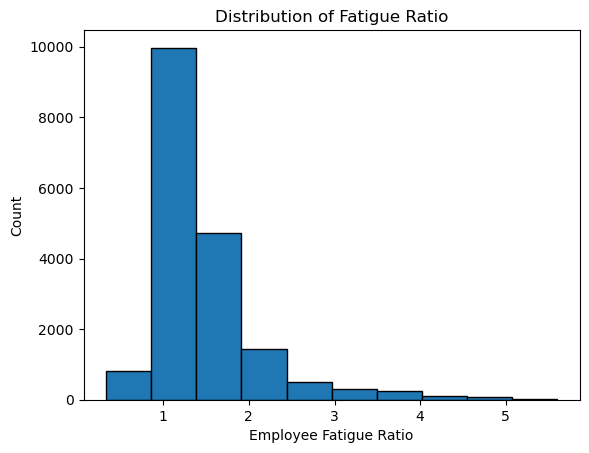

In [139]:
plt.hist(data=train1, x="Fatigue Ratio", bins=10, edgecolor="black")
plt.title("Distribution of Fatigue Ratio")
plt.xlabel("Employee Fatigue Ratio")
plt.ylabel("Count")
plt.show()

In [140]:
selected_feature1 = "Fatigue Ratio"
selected_feature2 = "Burn Rate"

X = train1[[selected_feature1, selected_feature2]]
maxk=13
wcss=[]
sil_score=[]

In [141]:
for k in range(1, maxk):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    wcss.append(km.inertia_)
    if k > 1:
        sil_score.append(metrics.silhouette_score(X, km.labels_, metric="euclidean"))

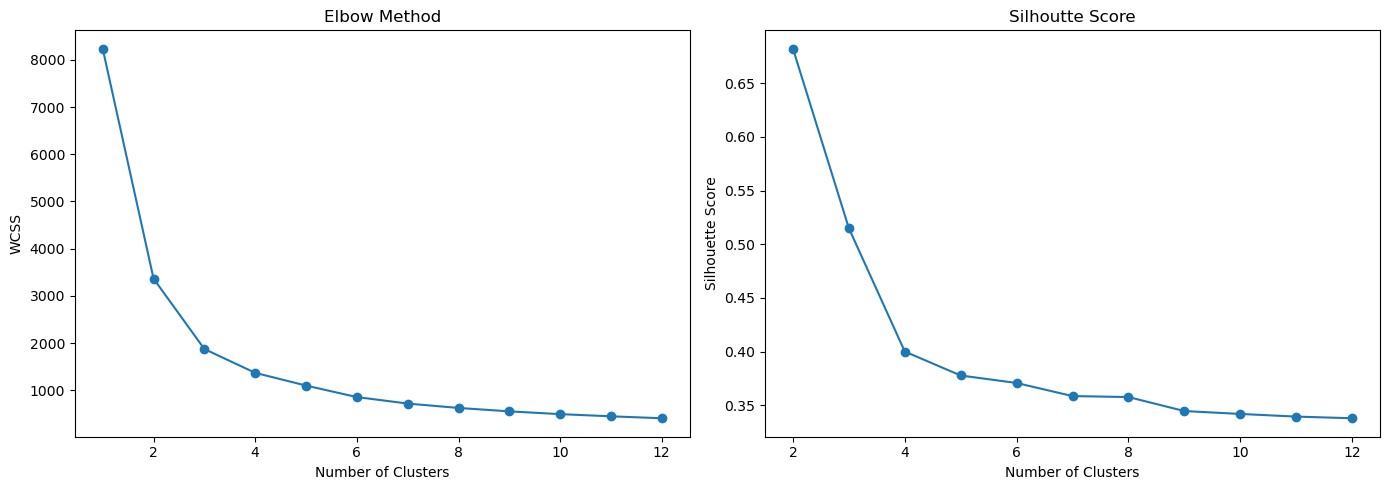

In [142]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, maxk), wcss, "o-")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("WCSS")
axes[1].plot(range(2, maxk), sil_score, "o-")
axes[1].set_title("Silhoutte Score")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

In [143]:
num_clusters = 3
Kmean = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
Kmean.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [144]:
Kmean.cluster_centers_

array([[1.16463345, 0.50058672],
       [1.91098101, 0.37712876],
       [3.62804204, 0.26248894]])

In [145]:
cluster_means = X.assign(Cluster=Kmean.labels_).groupby("Cluster").mean().round(2)
print(cluster_means)

         Fatigue Ratio  Burn Rate
Cluster                          
0                 1.16       0.50
1                 1.91       0.38
2                 3.63       0.26


In [146]:
cluster_names = {
    0: "Low Fatigue Ratio High Burnout",
    1: "Moderate Fatigue Ratio Moderate Burnout",
    2: "High Fatigue Ratio Low Burnout"
}

**As Fatigue Ratio increases, burn rate drops; as Fatigue Ratio Decreases, Burn Rate Increases**

Low Fatigue / High Burnout (Cluster 0): Employees with relatively low mental fatigue relative to their resource allocation, yet the highest burn rates. This group shows the widest variability in burn rate, suggesting factors beyond resource allocation — such as role demands or work environment — are driving burnout.
Moderate Fatigue / Moderate Burnout (Cluster 1): A transitional group exhibiting balanced strain and output depletion, representing employees at early-to-mid stages of burnout progression.
High Fatigue / Low Burnout (Cluster 2): Employees with the highest mental fatigue relative to resources, yet paradoxically the lowest burn rates. This may indicate disengagement or emotional exhaustion rather than active burnout — a pattern consistent with quiet quitting behavior.

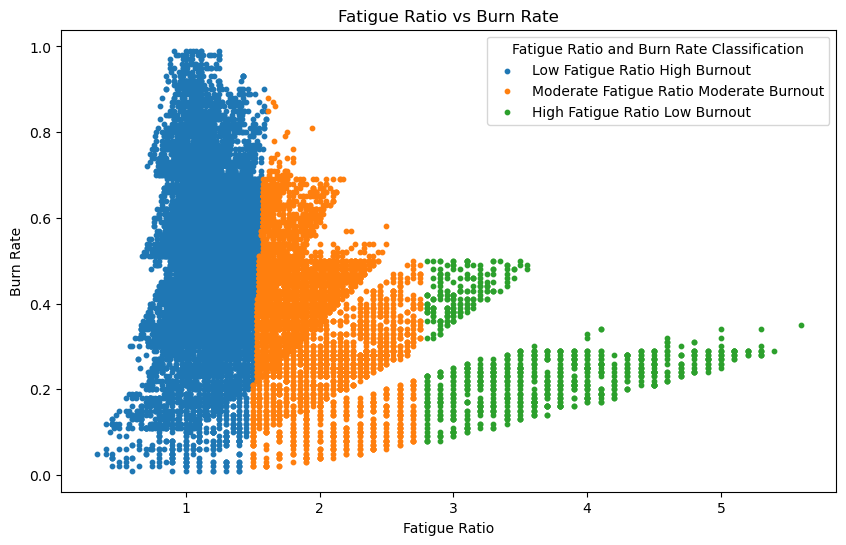

In [147]:
plt.figure(figsize=(10, 6))
plt.title(f"{selected_feature1} vs {selected_feature2}")
for cluster in np.unique(Kmean.labels_):
    mask = Kmean.labels_ == cluster
    plt.scatter(X.iloc[mask, 0], X.iloc[mask, 1], label=cluster_names[cluster], s=10)
plt.xlabel(selected_feature1)
plt.ylabel(selected_feature2)
plt.legend(title="Fatigue Ratio and Burn Rate Classification")
plt.show()

In [148]:
train1["fatigueratio_burnrate_labels"] = pd.Series(Kmean.labels_).map(cluster_names).values

In [149]:
cat_vars = {
    "Gender": "Gender",
    "WFH Setup": "WFH Setup Available",
    "Seniority Level": "Seniority Level"
}

for title, var in cat_vars.items():
    ct = pd.crosstab(
        train1["fatigueratio_burnrate_labels"],
        train1[var],
        normalize="index"
    ).round(3) * 100
    ct.columns = [f"{col}" for col in ct.columns]
    ct.index.name = "Cluster"
    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    print(ct.to_string())
    print()


  Gender
                                         Female  Male
Cluster                                              
High Fatigue Ratio Low Burnout             62.1  37.9
Low Fatigue Ratio High Burnout             50.2  49.8
Moderate Fatigue Ratio Moderate Burnout    56.2  43.8


  WFH Setup
                                           No   Yes
Cluster                                            
High Fatigue Ratio Low Burnout           30.0  70.0
Low Fatigue Ratio High Burnout           51.0  49.0
Moderate Fatigue Ratio Moderate Burnout  35.5  64.5


  Seniority Level
                                         Director  Entry Level  Executive  Manager  Senior  Trainee/Intern
Cluster                                                                                                   
High Fatigue Ratio Low Burnout                0.0         50.3        0.0      0.0     0.0            49.7
Low Fatigue Ratio High Burnout               15.0         10.3        2.2     36.7    34.5             1.

In [150]:
train1.groupby("fatigueratio_burnrate_labels").agg(
    MentalFatigue_Mean=("Mental Fatigue Score", "mean"),
    WorkingHours_Mean=("Resource Allocation", "mean"),
    FatigueRatio_Mean=("Fatigue Ratio", "mean"),
    BurnRate_Mean=("Burn Rate", "mean"),
).round(2)

,MentalFatigue_Mean,WorkingHours_Mean,FatigueRatio_Mean,BurnRate_Mean
fatigueratio_burnrate_labels,,,,
High Fatigue Ratio Low Burnout,4.26,1.21,3.63,0.26
Low Fatigue Ratio High Burnout,6.11,5.35,1.16,0.50
Moderate Fatigue Ratio Moderate Burnout,5.30,2.86,1.91,0.38


**Conclusions**
- Burn rate alone understates risk: The high fatigue / low burnout cluster would be overlooked by burn rate metrics alone, yet represents a significant disengagement risk requiring a different type of intervention than the high burnout group.
- Seniority is the strongest differentiator: Senior and Mid-Level employees dominate the high burnout cluster, while junior employees dominate the disengaged cluster.
- The high burnout cluster has the lowest WFH adoption, but the disengaged cluster — also at risk — has the highest. Remote work appears to correlate with reduced active burnout but not necessarily with employee wellbeing overall.
- Female employees are overrepresented in both the High Fatigue / Low Burnout (62.1%) and Moderate Fatigue / Moderate Burnout (56.2%) clusters, suggesting women in this dataset disproportionately experience high strain and disengagement risk, while the High Burnout cluster is the most gender-balanced (50.2F / 49.8M).

**Return a Visualization for Workload Fatigue Interaction vs Burn Rate**

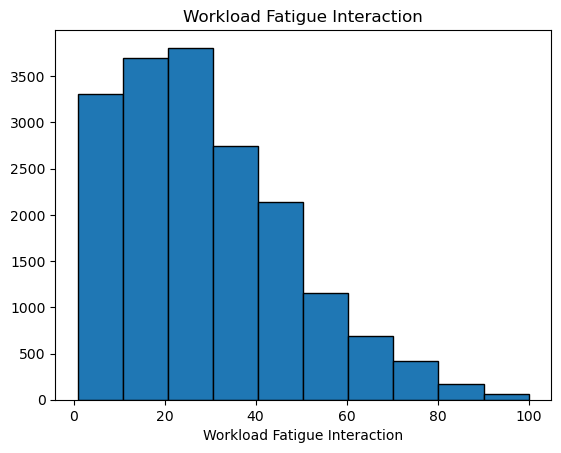

In [151]:
plt.title("Workload Fatigue Interaction")
plt.hist(data=train1, x="Workload Fatigue Interaction", edgecolor="black", bins=10)
plt.xlabel("Workload Fatigue Interaction")
plt.show()

In [152]:
selected_feature1 = "Workload Fatigue Interaction"
selected_feature2 = "Burn Rate"
X = train1[[selected_feature1, selected_feature2]]

maxk = 13
wcss = []
sil_score = []

In [153]:
for k in range(1, maxk):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    wcss.append(km.inertia_)
    if k > 1:
        sil_score.append(metrics.silhouette_score(X, km.labels_, metric="euclidean"))

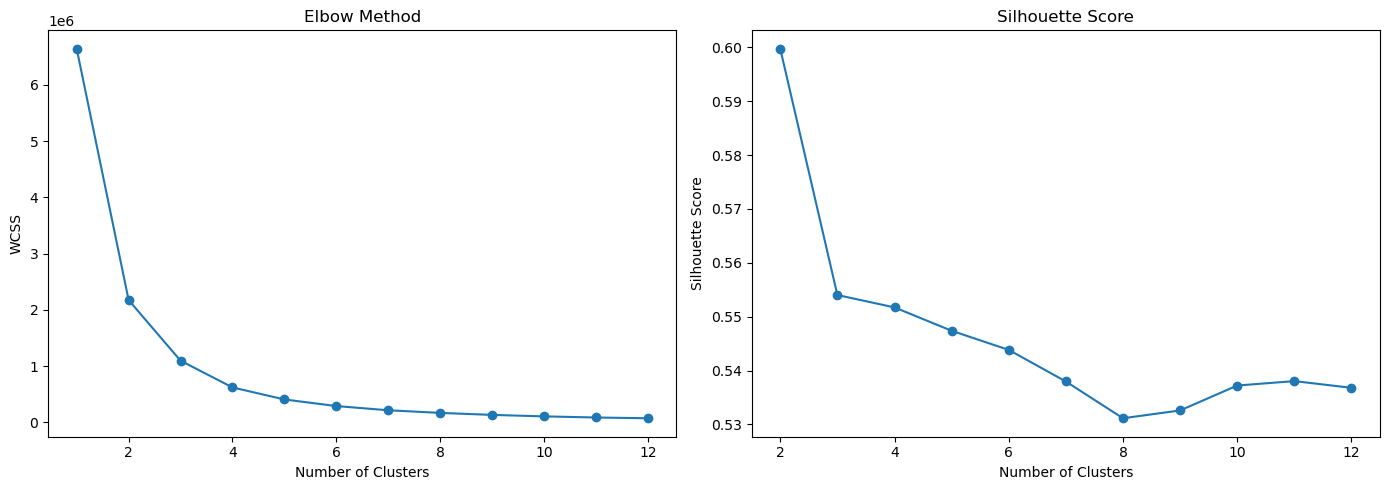

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, maxk), wcss, "o-")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("WCSS")
axes[1].plot(range(2, maxk), sil_score, "o-")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

In [155]:
num_clusters = 3
Kmean = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
Kmean.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [156]:
Kmean.cluster_centers_

array([[12.97899312,  0.30420138],
       [34.71259542,  0.52971869],
       [62.50436774,  0.73128919]])

In [157]:
cluster_means = X.assign(Cluster=Kmean.labels_).groupby("Cluster").mean().round(2)
print(cluster_means)

         Workload Fatigue Interaction  Burn Rate
Cluster                                         
0                               12.98       0.30
1                               34.71       0.53
2                               62.50       0.73


In [158]:
cluster_names = {
    0: "Low Workload & Fatigue / Low Burnout",
    1: "Moderate Workload & Fatigue / Moderate Burnout",
    2: "High Workload & Fatigue / High Burnout"
}

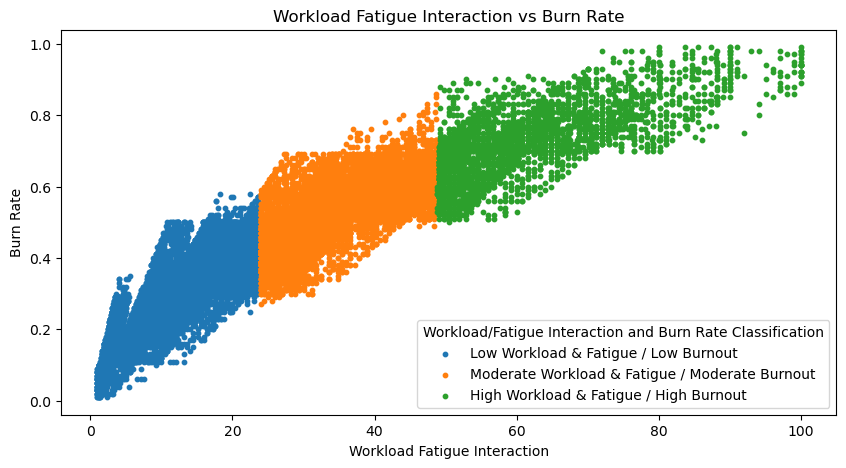

In [159]:
plt.figure(figsize=(10, 5))
plt.title(f"{selected_feature1} vs {selected_feature2}")
for cluster in np.unique(Kmean.labels_):
    mask = Kmean.labels_ == cluster
    plt.scatter(X.iloc[mask, 0], X.iloc[mask, 1], label=cluster_names[cluster], s=10)
plt.xlabel(selected_feature1)
plt.ylabel(selected_feature2)
plt.legend(title="Workload/Fatigue Interaction and Burn Rate Classification")
plt.show()

In [160]:
train1["workloadfatigue_burnrate_cluster_label"] = pd.Series(Kmean.labels_).map(cluster_names).values

In [161]:
cat_vars = {
    "Gender": "Gender",
    "WFH Setup": "WFH Setup Available",
    "Seniority Level": "Seniority Level"
}

for title, var in cat_vars.items():
    ct = pd.crosstab(
        train1["workloadfatigue_burnrate_cluster_label"],
        train1[var],
        normalize="index"
    ).round(3) * 100
    ct.columns = [f"{col}" for col in ct.columns]
    ct.index.name = "Cluster"
    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    print(ct.to_string())
    print()


  Gender
                                                Female  Male
Cluster                                                     
High Workload & Fatigue / High Burnout            40.0  60.0
Low Workload & Fatigue / Low Burnout              60.0  40.0
Moderate Workload & Fatigue / Moderate Burnout    48.1  51.9


  WFH Setup
                                                  No   Yes
Cluster                                                   
High Workload & Fatigue / High Burnout          69.2  30.8
Low Workload & Fatigue / Low Burnout            30.2  69.8
Moderate Workload & Fatigue / Moderate Burnout  55.7  44.3


  Seniority Level
                                                Director  Entry Level  Executive  Manager  Senior  Trainee/Intern
Cluster                                                                                                          
High Workload & Fatigue / High Burnout              49.0          0.0       10.0     36.6     4.4             0.0
Low Workload &

In [162]:
train1.groupby("workloadfatigue_burnrate_cluster_label").agg(
    WorkingHours_Mean=("Resource Allocation", "mean"),
    MentalFatigue_Mean=("Mental Fatigue Score", "mean"),
    FatigueRatio_Mean=("Workload Fatigue Interaction", "mean"),
    BurnRate_Mean=("Burn Rate", "mean"),
).round(2)

,WorkingHours_Mean,MentalFatigue_Mean,FatigueRatio_Mean,BurnRate_Mean
workloadfatigue_burnrate_cluster_label,,,,
High Workload & Fatigue / High Burnout,7.58,8.23,62.50,0.73
Low Workload & Fatigue / Low Burnout,2.83,4.36,12.98,0.30
Moderate Workload & Fatigue / Moderate Burnout,5.30,6.55,34.71,0.53


**Conclusions**
- Seniority is the strongest burnout predictor: Junior and Associate employees cluster almost entirely in low risk, while Lead and Senior employees dominate the high burnout cluster. There is virtually no crossover.
- WFH is strongly protective: WFH access declines consistently as burnout severity increases (69.8% → 44.3% → 30.8%), suggesting remote flexibility meaningfully reduces burnout risk
- Gender reverses across risk levels: Women are overrepresented in low burnout (60%) and men in high burnout (60%), which contrasts with the fatigue ratio clustering where women showed higher disengagement risk — worth noting as a nuance between active burnout vs. quiet quitting patterns

In [163]:
train1.head(5)

,Company Type_Product,Company Type_Service,Gender,Seniority Level,WFH Setup Available,Gender_Female,Gender_Male,WFH Setup Available_No,WFH Setup Available_Yes,Resource Allocation,...,Fatigue Ratio,High Workload,High Fatigue,Stress Index,days_since_joined,High Burnout,Burn Rate,stressindex_burnrate_cluster_label,fatigueratio_burnrate_labels,workloadfatigue_burnrate_cluster_label
0,False,True,Female,Senior,No,True,False,True,False,3.0,...,1.266667,False,False,3.56,92,False,0.16,Low Stress Low Burnout,Low Fatigue Ratio High Burnout,Low Workload & Fatigue / Low Burnout
1,False,True,Male,Entry Level,Yes,False,True,False,True,2.0,...,2.500000,False,False,4.10,31,False,0.36,Low Stress Low Burnout,Moderate Fatigue Ratio Moderate Burnout,Low Workload & Fatigue / Low Burnout
3,False,True,Male,Entry Level,Yes,False,True,False,True,1.0,...,2.600000,False,False,2.12,58,False,0.20,Low Stress Low Burnout,Moderate Fatigue Ratio Moderate Burnout,Low Workload & Fatigue / Low Burnout
4,False,True,Female,Manager,No,True,False,True,False,7.0,...,0.985714,True,True,6.93,160,True,0.52,High Stress High Burnout,Low Fatigue Ratio High Burnout,Moderate Workload & Fatigue / Moderate Burnout
5,True,False,Male,Senior,Yes,False,True,False,True,4.0,...,0.900000,False,False,3.72,35,False,0.29,Low Stress Low Burnout,Low Fatigue Ratio High Burnout,Low Workload & Fatigue / Low Burnout


In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [165]:
features = [
    "Resource Allocation",
    "Mental Fatigue Score",
    "Workload Fatigue Interaction", 
    "Fatigue Ratio",
    "Stress Index",
    "Burn Rate",
    "Designation",
    "WFH Setup Available_No",
    "Gender_Female"
]

In [166]:
X = train1[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [167]:
maxk = 13
wcss = []
for k in range(1, maxk):
    km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

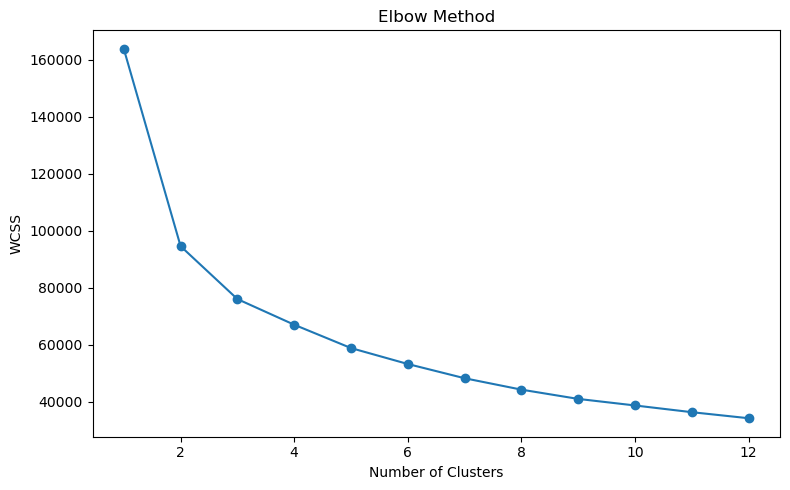

In [168]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, maxk), wcss, "o-")
ax.set_title("Elbow Method")
ax.set_xlabel("Number of Clusters")
ax.set_ylabel("WCSS")
plt.tight_layout()
plt.show()

In [169]:
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42, n_init=10)
kmeans.fit(X_scaled)
labels = kmeans.labels_

In [170]:
cluster_br = {i: float(np.mean(train1['Burn Rate'].values[labels == i])) for i in range(3)}
order = sorted(cluster_br, key=cluster_br.get)
name_map = {order[0]: 'Low Burnout Risk', order[1]: 'Moderate Burnout Risk', order[2]: 'High Burnout Risk'}
label_names = np.array([name_map[l] for l in labels])
train1['pca_kmeans_label_named'] = label_names

In [171]:
pca_full = PCA()
pca_full.fit(X_scaled)
cumvar = pca_full.explained_variance_ratio_.cumsum()

In [172]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
centers_pca = pca2.transform(kmeans.cluster_centers_)
loadings = pd.DataFrame(pca2.components_.T, index=features, columns=["PC1", "PC2"])

In [173]:
loadings

,PC1,PC2
Resource Allocation,0.402021,-0.176928
Mental Fatigue Score,0.379420,0.250775
Workload Fatigue Interaction,0.407471,0.008694
Fatigue Ratio,-0.225187,0.642285
Stress Index,0.405842,0.117467
Burn Rate,0.391457,0.169805
Designation,0.361812,-0.245766
WFH Setup Available_No,0.151315,0.340587
Gender_Female,-0.076988,-0.523613


In [174]:
pcols = ['Burn Rate', 'Mental Fatigue Score', 'Resource Allocation',
         'Stress Index', 'Workload Fatigue Interaction', 'Fatigue Ratio']
profile = train1.groupby('pca_kmeans_label_named')[pcols].mean()
profile = profile.loc[['Low Burnout Risk', 'Moderate Burnout Risk', 'High Burnout Risk']]

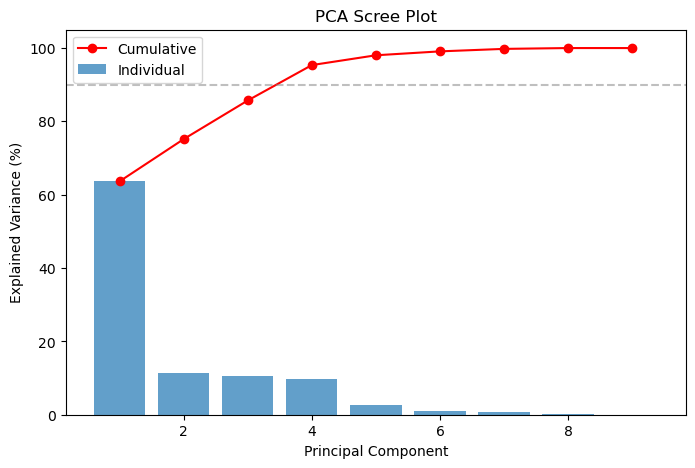

In [175]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, 10), pca_full.explained_variance_ratio_*100, alpha=0.7, label='Individual')
plt.plot(range(1, 10), cumvar*100, 'o-', color='red', label='Cumulative')
plt.axhline(90, linestyle='--', color='gray', alpha=0.5)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('PCA Scree Plot')
plt.legend()
plt.show()

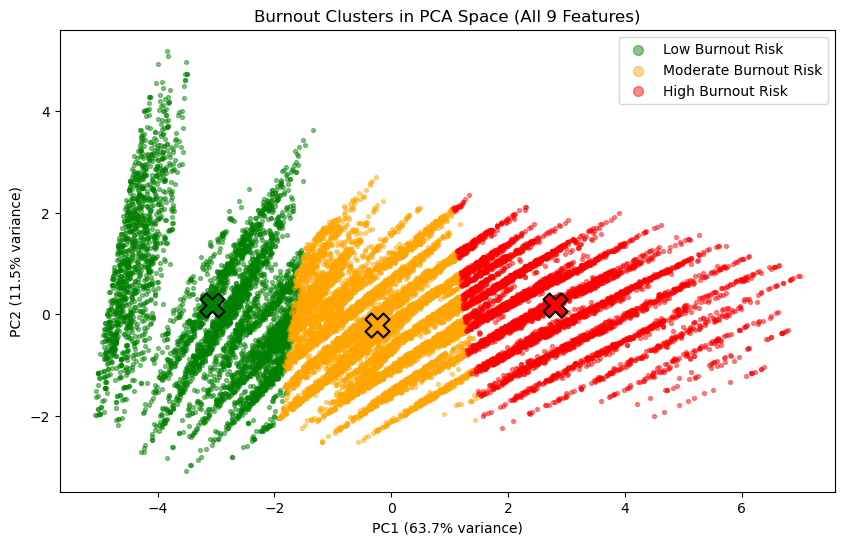

In [176]:
colors = {'Low Burnout Risk': 'green', 'Moderate Burnout Risk': 'orange', 'High Burnout Risk': 'red'}
plt.figure(figsize=(10, 6))
for cname, color in colors.items():
    mask = label_names == cname
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1], c=color, label=cname, s=8, alpha=0.45)
for i in range(3):
    cname = name_map[i]
    plt.scatter(centers_pca[i, 0], centers_pca[i, 1],
                marker='X', s=300, c=colors[cname], edgecolors='black', linewidths=1.5, zorder=5)
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance)")
plt.title('Burnout Clusters in PCA Space (All 9 Features)')
plt.legend(markerscale=2.5)
plt.show()

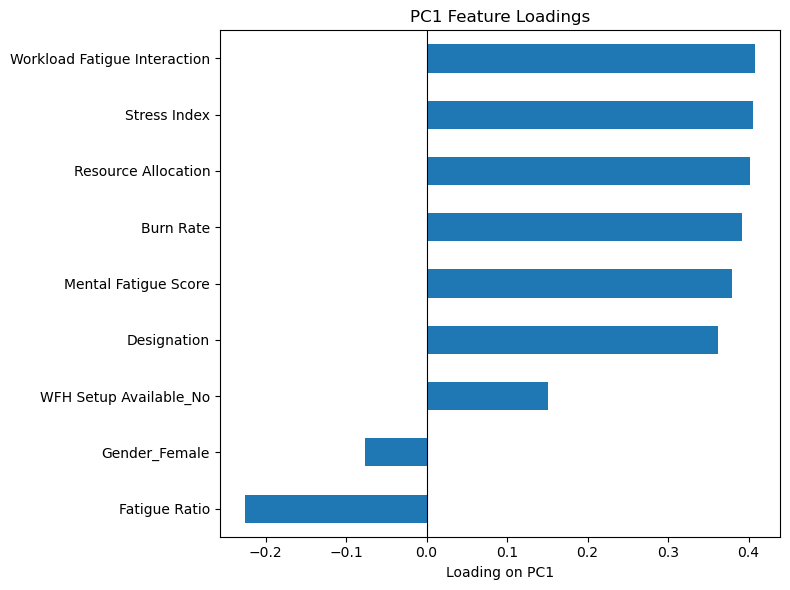

In [177]:
pc1_sorted = loadings['PC1'].sort_values()
pc1_sorted.plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Loading on PC1')
plt.title('PC1 Feature Loadings')
plt.tight_layout()
plt.show()

In [178]:
profile_display = profile[['Burn Rate', 'Mental Fatigue Score', 'Resource Allocation', 'Stress Index']].copy()
profile_display.columns = ['Burn Rate', 'Mental Fatigue', 'Resource Allocation', 'Stress Index']
profile_display['Count'] = train1['pca_kmeans_label_named'].value_counts().reindex(profile_display.index)

print("Cluster Profiles")
print(profile_display.round(2).to_string())

Cluster Profiles
                        Burn Rate  Mental Fatigue  Resource Allocation  Stress Index  Count
pca_kmeans_label_named                                                                     
Low Burnout Risk             0.23            3.67                 2.06          3.19   4476
Moderate Burnout Risk        0.44            5.72                 4.35          5.31   8134
High Burnout Risk            0.67            7.68                 6.78          7.41   5586


Conclusions
- PCA confirmed that employee burnout in this dataset is driven by one dominant dimension — PC1 captures 63.7% of variance across all nine features, meaning workload, fatigue, and stress are largely measuring the same underlying construct rather than independent factors.
- The feature loadings showed Workload Fatigue Interaction, Stress Index, Resource Allocation, Burn Rate, and Mental Fatigue Score all moving together as a unified burnout signal, validating the engineered features as meaningful additions to the analysis.
- The cluster plot confirmed that the three K-Means burnout risk groups — Low, Moderate, and High — separate cleanly in PCA space, with High Burnout employees showing nearly 7x the Workload Fatigue Interaction of Low Burnout employees.
- Reducing workload and expanding WFH access are the strongest levers available to move employees out of high burnout risk.

**PCA Analysis assessing burnout by working from home setup**

In [179]:
features = [
    "Resource Allocation",
    "Mental Fatigue Score",
    "Workload Fatigue Interaction", 
    "Fatigue Ratio",
    "Stress Index",
    "Burn Rate",
    "Designation",
    "Gender_Female"
]

In [180]:
X = train1[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [181]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
loadings = pd.DataFrame(pca2.components_.T, index=features, columns=['PC1', 'PC2'])

In [182]:
wfh_colors = {'Yes': 'steelblue', 'No': 'red'}

In [183]:
pca_full_w = PCA()
pca_full_w.fit(X_scaled)
cumvar_w = pca_full_w.explained_variance_ratio_.cumsum()

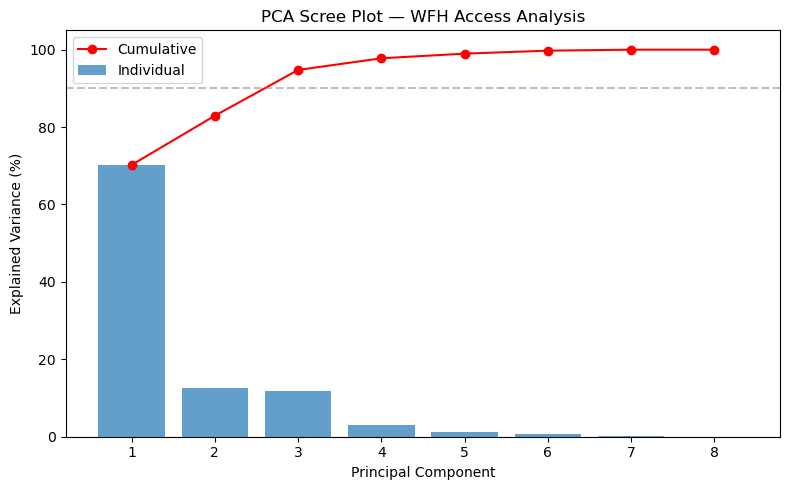

In [184]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, 9), pca_full_w.explained_variance_ratio_*100, alpha=0.7, label='Individual')
plt.plot(range(1, 9), cumvar_w*100, 'o-', color='red', label='Cumulative')
plt.axhline(90, linestyle='--', color='gray', alpha=0.5)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('PCA Scree Plot — WFH Access Analysis')
plt.legend()
plt.tight_layout()
plt.show()

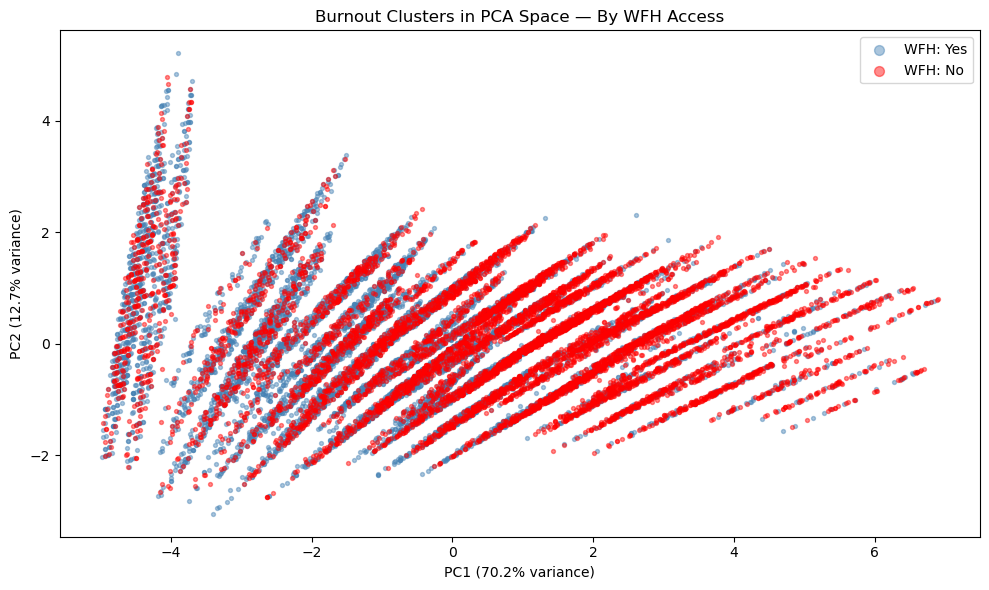

In [185]:
plt.figure(figsize=(10, 6))
for wfh, color in wfh_colors.items():
    mask = train1['WFH Setup Available'] == wfh
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                c=color, label=f'WFH: {wfh}', s=8, alpha=0.45)
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance)")
plt.title('Burnout Clusters in PCA Space — By WFH Access')
plt.legend(markerscale=2.5)
plt.tight_layout()
plt.show()

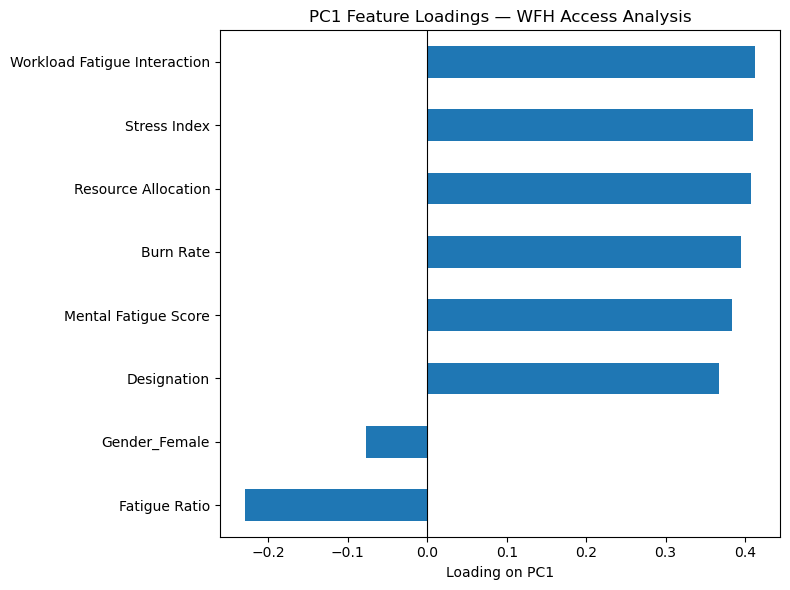

In [186]:
loadings['PC1'].sort_values().plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Loading on PC1')
plt.title('PC1 Feature Loadings — WFH Access Analysis')
plt.tight_layout()
plt.show()

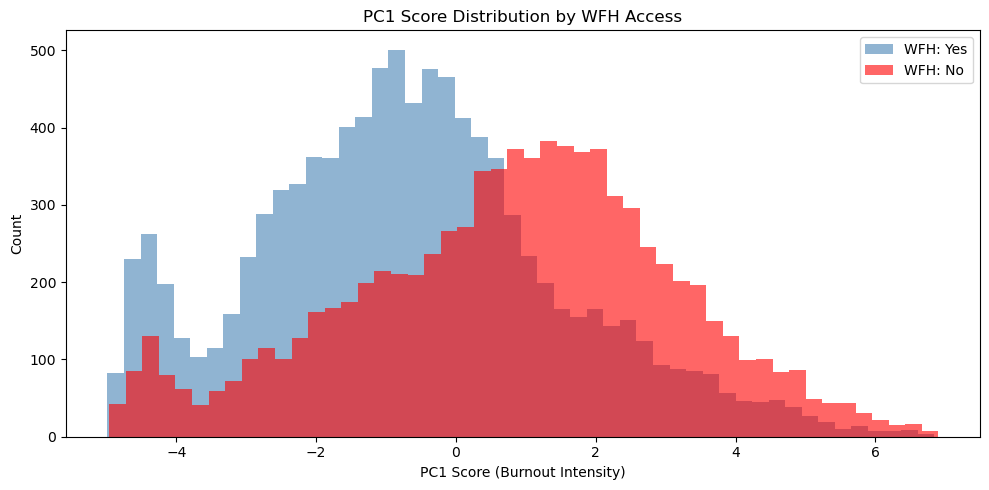

In [187]:
plt.figure(figsize=(10, 5))
for wfh, color in wfh_colors.items():
    mask = train1['WFH Setup Available'] == wfh
    plt.hist(X_pca2[mask, 0], bins=50, alpha=0.6, label=f'WFH: {wfh}', color=color)
plt.xlabel('PC1 Score (Burnout Intensity)')
plt.ylabel('Count')
plt.title('PC1 Score Distribution by WFH Access')
plt.legend()
plt.tight_layout()
plt.show()

In [188]:
pcols = ['Burn Rate', 'Mental Fatigue Score', 'Resource Allocation', 'Stress Index']
profile_w = train1.groupby('WFH Setup Available')[pcols].mean()
profile_w['Count'] = train1['WFH Setup Available'].value_counts()
print('WFH Access Profiles')
print(profile_w.round(2).to_string())

WFH Access Profiles
                     Burn Rate  Mental Fatigue Score  Resource Allocation  Stress Index  Count
WFH Setup Available                                                                           
No                        0.52                  6.37                 5.15          6.01   8401
Yes                       0.40                  5.34                 4.00          4.94   9795


**Conclusions**
- PCA confirmed that the same workload and fatigue construct drives burnout regardless of WFH status — PC1 captures 70.2% of variance and the loading structure is identical across both groups. WFH availability does not change what causes burnout, but it does affect how severely it manifests.
- The PCA scatter showed that employees without WFH access concentrate toward the higher burnout end of PC1, while WFH employees skew toward the lower end. With a Stress Index of 6.01 vs 4.94 and a Burn Rate of 0.52 vs 0.40, non-WFH employees consistently show worse outcomes across every burnout metric, confirming WFH access as one of the strongest protective factors in this dataset.

**Perform PCA for Gender**

In [189]:
features = [
    "Resource Allocation",
    "Mental Fatigue Score",
    "Workload Fatigue Interaction", 
    "Fatigue Ratio",
    "Stress Index",
    "Burn Rate",
    "Designation",
    "WFH Setup Available_No",
]

In [190]:
X = train1[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [191]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
loadings = pd.DataFrame(pca2.components_.T, index=features, columns=['PC1', 'PC2'])

In [192]:
gender_colors = {'Female': 'steelblue', 'Male': 'red'}

In [193]:
pca_full_w = PCA()
pca_full_w.fit(X_scaled)
cumvar_w = pca_full_w.explained_variance_ratio_.cumsum()

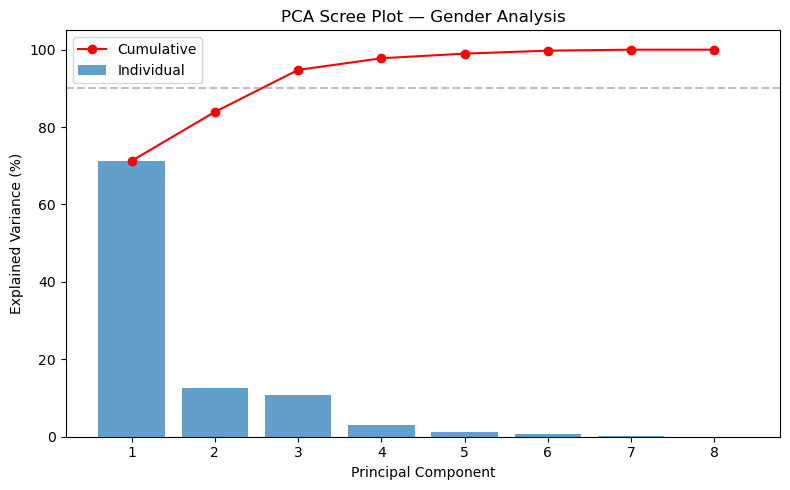

In [194]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, 9), pca_full_w.explained_variance_ratio_*100, alpha=0.7, label='Individual')
plt.plot(range(1, 9), cumvar_w*100, 'o-', color='red', label='Cumulative')
plt.axhline(90, linestyle='--', color='gray', alpha=0.5)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('PCA Scree Plot — Gender Analysis')
plt.legend()
plt.tight_layout()
plt.show()

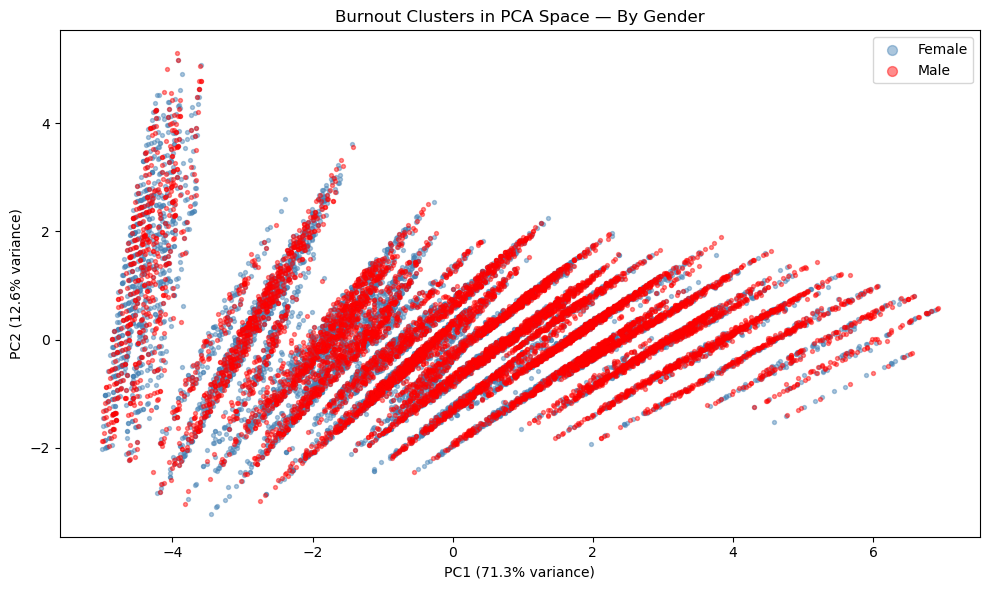

In [195]:
plt.figure(figsize=(10, 6))
for gender, color in gender_colors.items():
    mask = train1['Gender'] == gender
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                c=color, label=gender, s=8, alpha=0.45)
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance)")
plt.title('Burnout Clusters in PCA Space — By Gender')
plt.legend(markerscale=2.5)
plt.tight_layout()
plt.show()

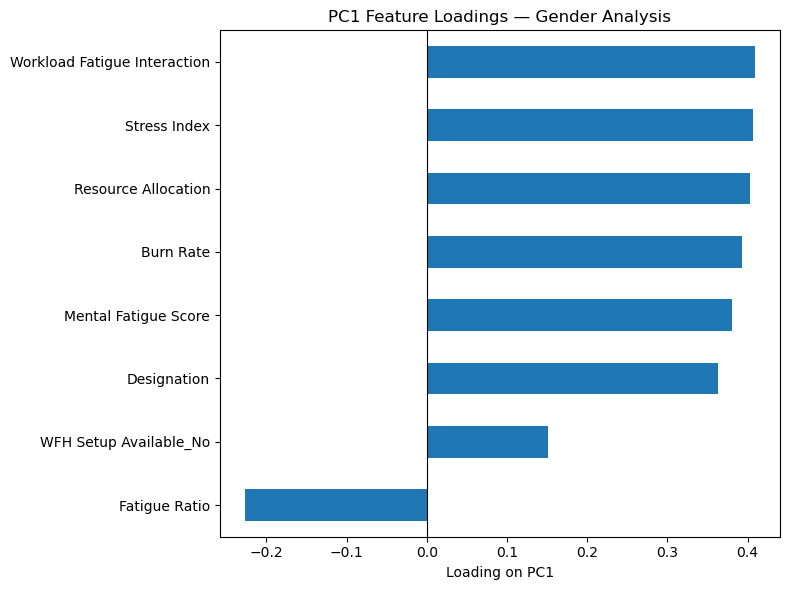

In [196]:
loadings['PC1'].sort_values().plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Loading on PC1')
plt.title('PC1 Feature Loadings — Gender Analysis')
plt.tight_layout()
plt.show()

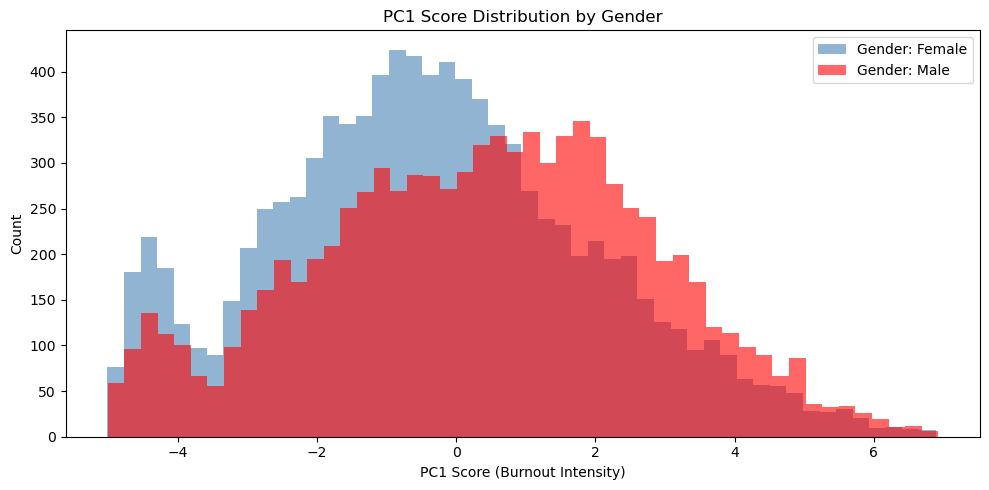

In [197]:
plt.figure(figsize=(10, 5))
for gender, color in gender_colors.items():
    mask = train1['Gender'] == gender
    plt.hist(X_pca2[mask, 0], bins=50, alpha=0.6, label=f'Gender: {gender}', color=color)
plt.xlabel('PC1 Score (Burnout Intensity)')
plt.ylabel('Count')
plt.title('PC1 Score Distribution by Gender')
plt.legend()
plt.tight_layout()
plt.show()

In [198]:
pcols = ['Burn Rate', 'Mental Fatigue Score', 'Resource Allocation', 'Stress Index']
profile_w = train1.groupby('Gender')[pcols].mean()
profile_w['Count'] = train1['Gender'].value_counts()
print('Gender Profiles')
print(profile_w.round(2).to_string())

Gender Profiles
        Burn Rate  Mental Fatigue Score  Resource Allocation  Stress Index  Count
Gender                                                                           
Female       0.43                  5.56                 4.26          5.17   9510
Male         0.49                  6.09                 4.82          5.71   8686


**Conclusions**

- PCA confirmed that the same workload and fatigue construct drives burnout equally across both genders — PC1 captures 71.3% of variance and Gender_Female does not appear as a meaningful driver in the PC1 loadings. Gender influences where employees fall on the burnout continuum but does not change what causes it.
- The PCA scatter and PC1 distribution both show substantial overlap between male and female employees, with no clean separation the way seniority and WFH access produced. However, male employees are overrepresented in the high burnout right tail — Burn Rate (0.49 vs 0.43), Mental Fatigue (6.09 vs 5.56), and Stress Index (5.71 vs 5.17) are all higher for male employees, indicating a moderate but consistent burnout differential.
- Gender is a weaker predictor of burnout than seniority or WFH access. The highest risk employees in this dataset are likely senior male employees without WFH access, where all three risk factors compound simultaneously.

**Perform PCA but for seniority Level**

In [199]:
features = [
    "Resource Allocation",
    "Mental Fatigue Score",
    "Workload Fatigue Interaction", 
    "Fatigue Ratio",
    "Stress Index",
    "Burn Rate",
    "Gender_Female",
    "WFH Setup Available_No",
]

In [200]:
X = train1[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [201]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
loadings = pd.DataFrame(pca2.components_.T, index=features, columns=['PC1', 'PC2'])

In [202]:
seniority_order  = ['Trainee/Intern', 'Entry Level', 'Senior', 'Manager', 'Director', 'Executive']
seniority_colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c']

In [203]:
pca_full_s = PCA()
pca_full_s.fit(X_scaled)
cumvar_s = pca_full_s.explained_variance_ratio_.cumsum()

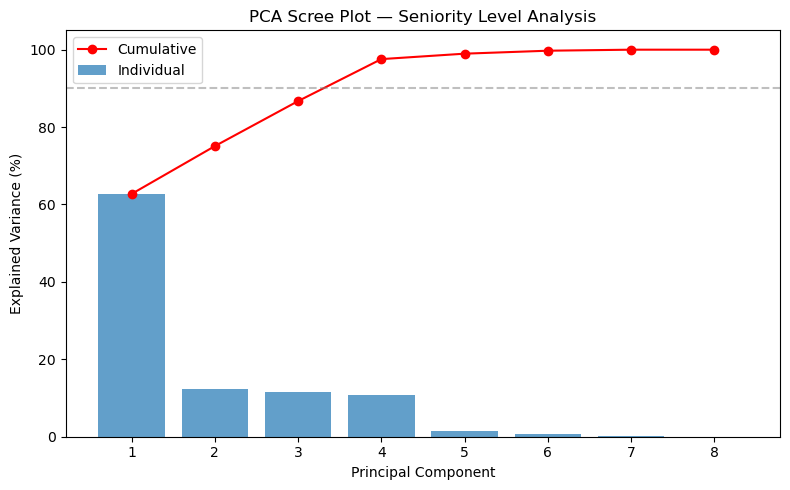

In [204]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, 9), pca_full_s.explained_variance_ratio_*100, alpha=0.7, label='Individual')
plt.plot(range(1, 9), cumvar_s*100, 'o-', color='red', label='Cumulative')
plt.axhline(90, linestyle='--', color='gray', alpha=0.5)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('PCA Scree Plot — Seniority Level Analysis')
plt.legend()
plt.tight_layout()
plt.show()

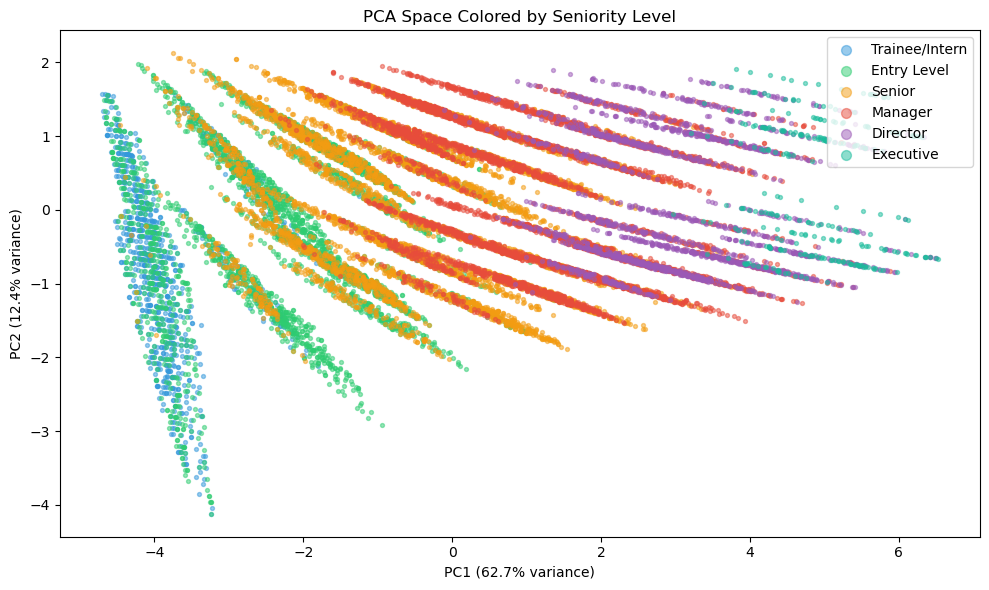

In [205]:
plt.figure(figsize=(10, 6))
for level, color in zip(seniority_order, seniority_colors):
    mask = train1['Seniority Level'] == level
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                c=color, label=level, s=8, alpha=0.5)
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance)")
plt.title('PCA Space Colored by Seniority Level')
plt.legend(markerscale=2.5, loc='upper right')
plt.tight_layout()
plt.show()

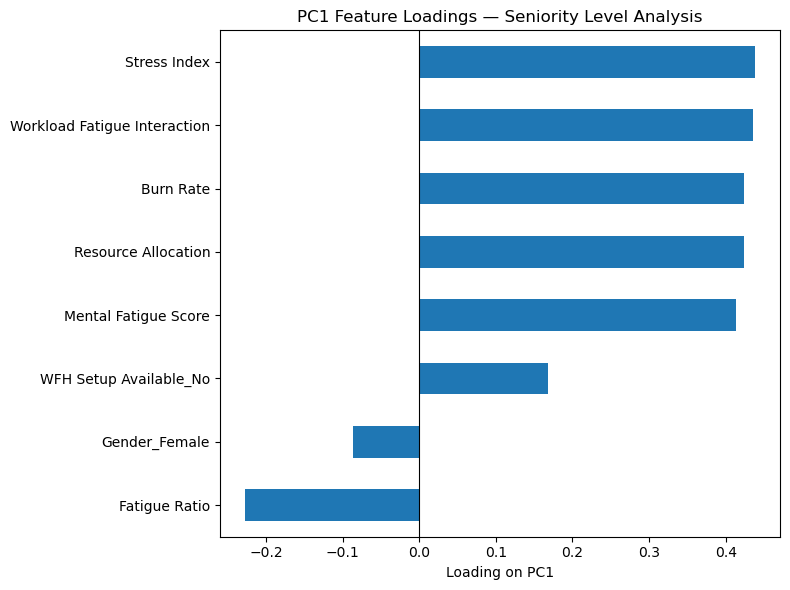

In [206]:
loadings['PC1'].sort_values().plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Loading on PC1')
plt.title('PC1 Feature Loadings — Seniority Level Analysis')
plt.tight_layout()
plt.show()

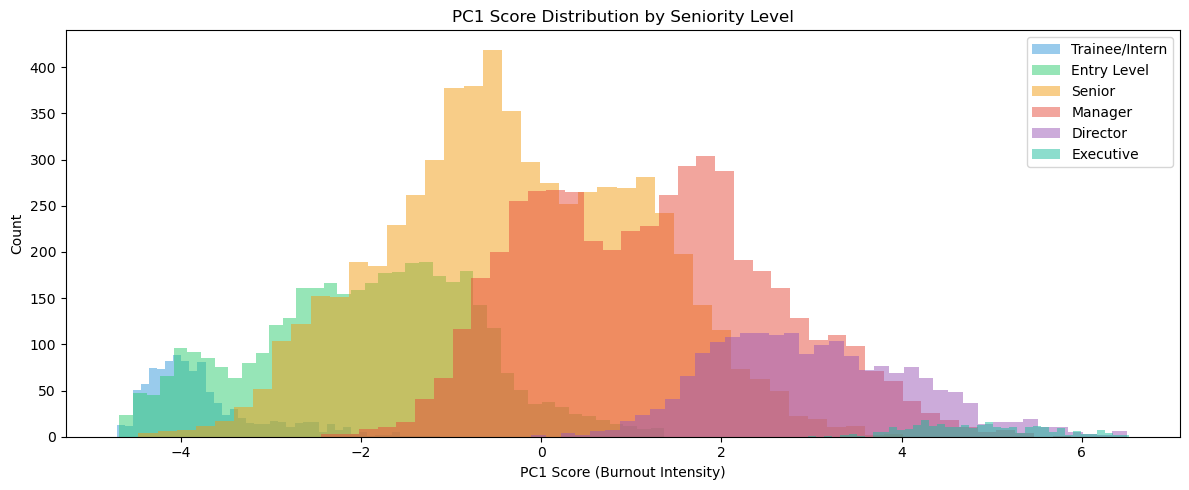

In [207]:
plt.figure(figsize=(12, 5))
for level, color in zip(seniority_order, seniority_colors):
    mask = train1['Seniority Level'] == level
    plt.hist(X_pca2[mask, 0], bins=40, alpha=0.5, label=level, color=color)
plt.xlabel('PC1 Score (Burnout Intensity)')
plt.ylabel('Count')
plt.title('PC1 Score Distribution by Seniority Level')
plt.legend()
plt.tight_layout()
plt.show()

In [208]:
pcols = ['Burn Rate', 'Mental Fatigue Score', 'Resource Allocation', 'Stress Index']
profile_s = train1.groupby('Seniority Level')[pcols].mean().reindex(seniority_order)
profile_s['Count'] = train1['Seniority Level'].value_counts().reindex(seniority_order)
print('Seniority Level Profiles')
print(profile_s.round(2).to_string())

Seniority Level Profiles
                 Burn Rate  Mental Fatigue Score  Resource Allocation  Stress Index  Count
Seniority Level                                                                           
Trainee/Intern        0.18                  3.10                 1.25          2.54   1036
Entry Level           0.32                  4.58                 2.63          3.99   3827
Senior                0.44                  5.67                 4.19          5.23   6214
Manager               0.54                  6.62                 5.74          6.35   4914
Director              0.68                  7.71                 7.43          7.63   1921
Executive             0.84                  8.84                 9.12          8.92    284


**Conclusions**

- PCA confirmed that burnout intensity increases monotonically with seniority across all metrics. PC1 captures 62.7% of variance and the same workload and fatigue features drive burnout at every career stage — seniority does not change what causes burnout, it determines how severely employees experience it.
- The PCA scatter and PC1 distribution both show a clean left-to-right progression by seniority level — Trainees cluster at the low burnout end while Directors and Executives extend into the far right tail. Executives show a Burn Rate of 0.84 and Stress Index of 8.92 compared to 0.18 and 2.54 for Trainees, confirming that burnout compounds significantly as employees advance.
- Senior is the largest group at 6,214 employees and sits at the inflection point where burnout begins accelerating, making it the most critical tier for early intervention. Targeted support at the Manager and Director levels — where burnout is severe and employee counts remain substantial — would have the highest organizational impact.

**PCA Analysis for High Burnout**

In [209]:
train1

,Company Type_Product,Company Type_Service,Gender,Seniority Level,WFH Setup Available,Gender_Female,Gender_Male,WFH Setup Available_No,WFH Setup Available_Yes,Resource Allocation,...,High Workload,High Fatigue,Stress Index,days_since_joined,High Burnout,Burn Rate,stressindex_burnrate_cluster_label,fatigueratio_burnrate_labels,workloadfatigue_burnrate_cluster_label,pca_kmeans_label_named
0,False,True,Female,Senior,No,True,False,True,False,3.0,...,False,False,3.56,92,False,0.16,Low Stress Low Burnout,Low Fatigue Ratio High Burnout,Low Workload & Fatigue / Low Burnout,Low Burnout Risk
1,False,True,Male,Entry Level,Yes,False,True,False,True,2.0,...,False,False,4.10,31,False,0.36,Low Stress Low Burnout,Moderate Fatigue Ratio Moderate Burnout,Low Workload & Fatigue / Low Burnout,Low Burnout Risk
3,False,True,Male,Entry Level,Yes,False,True,False,True,1.0,...,False,False,2.12,58,False,0.20,Low Stress Low Burnout,Moderate Fatigue Ratio Moderate Burnout,Low Workload & Fatigue / Low Burnout,Low Burnout Risk
4,False,True,Female,Manager,No,True,False,True,False,7.0,...,True,True,6.93,160,True,0.52,High Stress High Burnout,Low Fatigue Ratio High Burnout,Moderate Workload & Fatigue / Moderate Burnout,High Burnout Risk
5,True,False,Male,Senior,Yes,False,True,False,True,4.0,...,False,False,3.72,35,False,0.29,Low Stress Low Burnout,Low Fatigue Ratio High Burnout,Low Workload & Fatigue / Low Burnout,Moderate Burnout Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22743,True,False,Female,Entry Level,Yes,True,False,False,True,3.0,...,False,True,5.10,16,True,0.48,Moderate Stress Moderate Burnout,Moderate Fatigue Ratio Moderate Burnout,Low Workload & Fatigue / Low Burnout,Moderate Burnout Risk
22744,True,False,Male,Manager,No,False,True,True,False,7.0,...,True,True,6.44,218,True,0.54,High Stress High Burnout,Low Fatigue Ratio High Burnout,Moderate Workload & Fatigue / Moderate Burnout,High Burnout Risk
22746,True,False,Female,Manager,Yes,True,False,False,True,6.0,...,True,True,6.49,347,True,0.59,High Stress High Burnout,Low Fatigue Ratio High Burnout,Moderate Workload & Fatigue / Moderate Burnout,Moderate Burnout Risk
22748,False,True,Female,Senior,No,True,False,True,False,5.0,...,True,False,5.63,356,True,0.52,Moderate Stress Moderate Burnout,Low Fatigue Ratio High Burnout,Moderate Workload & Fatigue / Moderate Burnout,Moderate Burnout Risk


In [210]:
features = [
    "Resource Allocation",
    "Mental Fatigue Score",
    "Workload Fatigue Interaction", 
    "Fatigue Ratio",
    "Stress Index",
    "days_since_joined",
    "Designation",
    "Gender_Female",
    "WFH Setup Available_No"
]

In [211]:
X = train1[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Apori Rules**

In [213]:
pip install mlxtend

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [215]:
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd 

In [216]:
apriori_df = pd.DataFrame()

In [217]:
#demographic flags
apriori_df["Female"] = train1["Gender_Female"].astype(bool)
apriori_df["Male"] = train1["Gender_Male"].astype(bool)
apriori_df["WFH_No"] = train1["WFH Setup Available_No"].astype(bool)
apriori_df["WFH_Yes"] = train1["WFH Setup Available_Yes"].astype(bool)
apriori_df["Company_Product"] = train1["Company Type_Product"].astype(bool)
apriori_df["Company_Service"] = train1["Company Type_Service"].astype(bool)

#seniority level one hot encoding
apriori_df['Junior']  = train1['Seniority Level'].isin(['Trainee/Intern', 'Entry Level'])
apriori_df['Mid_Level'] = train1['Seniority Level'].isin(['Senior', 'Manager'])
apriori_df['C-Suite'] = train1['Seniority Level'].isin(['Director', 'Executive'])

#workload flags
apriori_df['High_Workload']    = train1['High Workload'].astype(bool)
apriori_df['High_Fatigue']     = train1['High Fatigue'].astype(bool)

#burnout flags
apriori_df['High_Burnout']     = train1['High Burnout'].astype(bool)
apriori_df['Low_Burnout']      = train1['Burn Rate'] < 0.31
apriori_df['High_Stress']      = train1['Stress Index'] > train1['Stress Index'].median()
apriori_df['High_Resource']    = train1['Resource Allocation'] > train1['Resource Allocation'].median()
apriori_df['High_MentalFatigue'] = train1['Mental Fatigue Score'] > train1['Mental Fatigue Score'].median()

In [218]:
frequent_itemsets = apriori(
    apriori_df,
    min_support=0.05,
    use_colnames=True,
    max_len=4
)

In [219]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.2
)

In [228]:
rules = rules.sort_values('lift', ascending=False)
print(f'Total rules found: {len(rules)}')

Total rules found: 7038


**What are some rules that contirbute to high burnout?**

In [224]:
# Rules where High_Burnout is the consequent
burnout_rules = rules[
    rules['consequents'].apply(lambda x: 'High_Burnout' in x)
].sort_values('lift', ascending=False)

burnout_rules_clean = burnout_rules.copy()
burnout_rules_clean['antecedents'] = burnout_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
burnout_rules_clean['consequents'] = burnout_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(burnout_rules_clean[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

                      antecedents                                     consequents  support  confidence     lift
                          C-Suite       High_Burnout, High_Fatigue, High_Workload 0.117498    0.969615 2.590764
                          C-Suite High_Burnout, High_MentalFatigue, High_Workload 0.117498    0.969615 2.590764
                          C-Suite       High_Burnout, High_Fatigue, High_Resource 0.117498    0.969615 2.590764
                          C-Suite High_Burnout, High_MentalFatigue, High_Resource 0.117498    0.969615 2.590764
                          C-Suite             High_Burnout, High_Resource, WFH_No 0.083205    0.686621 2.541449
                          C-Suite             High_Burnout, High_Workload, WFH_No 0.083205    0.686621 2.541449
                          C-Suite               High_Burnout, High_Workload, Male 0.071719    0.591837 2.510271
                          C-Suite               High_Burnout, High_Resource, Male 0.071719    0.591837 2

**What are some rules that contribute to low burnout**

In [229]:
# Rules where Low_Burnout is the consequent
low_burnout_rules = rules[
    rules['consequents'].apply(lambda x: 'Low_Burnout' in x)
].sort_values('lift', ascending=False)



low_burnout_rules_clean = low_burnout_rules.copy()
low_burnout_rules_clean['antecedents'] = low_burnout_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
low_burnout_rules_clean['consequents'] = low_burnout_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(low_burnout_rules_clean[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

                     antecedents                           consequents  support  confidence     lift
         Female, Junior, WFH_Yes                           Low_Burnout 0.062596    0.563025 2.544029
Company_Service, Junior, WFH_Yes                           Low_Burnout 0.066938    0.561549 2.537360
                 Junior, WFH_Yes                           Low_Burnout 0.103374    0.561493 2.537104
                 Junior, WFH_Yes                   Female, Low_Burnout 0.062596    0.340000 2.529289
                  Female, Junior          Company_Service, Low_Burnout 0.057815    0.364014 2.526162
                  Female, Junior                  Low_Burnout, WFH_Yes 0.062596    0.394118 2.525128
                 Junior, WFH_Yes          Company_Service, Low_Burnout 0.066938    0.363582 2.523165
                  Female, Junior                           Low_Burnout 0.088536    0.557439 2.518790
 Company_Service, Female, Junior                           Low_Burnout 0.057815    0.555145

**What are some of the rules that contribute to high fatigue**

In [232]:
fatigue_rules = rules[
    rules["consequents"].apply(lambda x: "High_Fatigue" in x)
].sort_values('lift', ascending=False)

fatigue_rules_clean = fatigue_rules.copy()
fatigue_rules_clean['antecedents'] = fatigue_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
fatigue_rules_clean['consequents'] = fatigue_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(fatigue_rules_clean[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

                      antecedents                                  consequents  support  confidence     lift
                          C-Suite          High_Fatigue, High_Resource, WFH_No 0.081227    0.670295 2.608358
                          C-Suite          High_Fatigue, High_Workload, WFH_No 0.081227    0.670295 2.608358
                          C-Suite    High_Burnout, High_Fatigue, High_Workload 0.117498    0.969615 2.590764
                          C-Suite    High_Burnout, High_Fatigue, High_Resource 0.117498    0.969615 2.590764
      C-Suite, High_MentalFatigue                  High_Fatigue, High_Workload 0.117498    1.000000 2.565708
High_MentalFatigue, High_Workload                        C-Suite, High_Fatigue 0.117498    0.301466 2.565708
High_MentalFatigue, High_Resource                        C-Suite, High_Fatigue 0.117498    0.301466 2.565708
High_MentalFatigue, High_Resource                  High_Fatigue, High_Workload 0.389756    1.000000 2.565708
High_MentalFatigue,

**What are some rules that contribute to high workload**

In [237]:
workload_rules = rules[
    rules["consequents"].apply(lambda x: "High_Workload" in x)
].sort_values('lift', ascending=False)

workload_rules_clean = fatigue_rules.copy()
workload_rules_clean['antecedents'] = fatigue_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
workload_rules_clean['consequents'] = fatigue_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(workload_rules_clean[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

                      antecedents                                  consequents  support  confidence     lift
                          C-Suite          High_Fatigue, High_Resource, WFH_No 0.081227    0.670295 2.608358
                          C-Suite          High_Fatigue, High_Workload, WFH_No 0.081227    0.670295 2.608358
                          C-Suite    High_Burnout, High_Fatigue, High_Workload 0.117498    0.969615 2.590764
                          C-Suite    High_Burnout, High_Fatigue, High_Resource 0.117498    0.969615 2.590764
      C-Suite, High_MentalFatigue                  High_Fatigue, High_Workload 0.117498    1.000000 2.565708
High_MentalFatigue, High_Workload                        C-Suite, High_Fatigue 0.117498    0.301466 2.565708
High_MentalFatigue, High_Resource                        C-Suite, High_Fatigue 0.117498    0.301466 2.565708
High_MentalFatigue, High_Resource                  High_Fatigue, High_Workload 0.389756    1.000000 2.565708
High_MentalFatigue,

**What are some rules that contribute to high stress**

In [238]:
high_stress_rules = rules[
    rules["consequents"].apply(lambda x: "High_Stress" in x)
].sort_values('lift', ascending=False)

high_stress_rules_clean = high_stress_rules.copy()
high_stress_rules_clean['antecedents'] = high_stress_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
high_stress_rules_clean['consequents'] = high_stress_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(high_stress_rules_clean[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

                      antecedents                                    consequents  support  confidence     lift
                          C-Suite       High_Burnout, High_Resource, High_Stress 0.121071    0.999093 2.502339
                          C-Suite       High_Burnout, High_Stress, High_Workload 0.121071    0.999093 2.502339
      High_Fatigue, High_Resource                           C-Suite, High_Stress 0.117498    0.301466 2.490006
High_MentalFatigue, High_Workload                           C-Suite, High_Stress 0.117498    0.301466 2.490006
      High_Fatigue, High_Workload                           C-Suite, High_Stress 0.117498    0.301466 2.490006
High_MentalFatigue, High_Resource                           C-Suite, High_Stress 0.117498    0.301466 2.490006
                          C-Suite       High_Fatigue, High_Stress, High_Workload 0.117498    0.969615 2.487748
                          C-Suite       High_Fatigue, High_Resource, High_Stress 0.117498    0.969615 2.487748
 

**What are some factors that contirbute to high resource allocation?**

In [243]:
high_resource_allocation = rules[
    rules["consequents"].apply(lambda x: "High_Resource" in x)
].sort_values('lift', ascending=False)

high_resource_allocation_rules_clean = high_resource_allocation.copy()
high_resource_allocation_rules_clean['antecedents'] = high_resource_allocation['antecedents'].apply(lambda x: ', '.join(sorted(x)))
high_resource_allocation_rules_clean['consequents'] = high_resource_allocation['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(high_resource_allocation_rules_clean[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

                      antecedents                                        consequents  support  confidence     lift
                          C-Suite          High_MentalFatigue, High_Resource, WFH_No 0.081227    0.670295 2.608358
                          C-Suite                High_Fatigue, High_Resource, WFH_No 0.081227    0.670295 2.608358
                          C-Suite          High_Burnout, High_Fatigue, High_Resource 0.117498    0.969615 2.590764
                          C-Suite    High_Burnout, High_MentalFatigue, High_Resource 0.117498    0.969615 2.590764
High_MentalFatigue, High_Workload                        High_Fatigue, High_Resource 0.389756    1.000000 2.565708
      High_Fatigue, High_Workload                  High_MentalFatigue, High_Resource 0.389756    1.000000 2.565708
            C-Suite, High_Fatigue                  High_MentalFatigue, High_Resource 0.117498    1.000000 2.565708
      C-Suite, High_MentalFatigue                        High_Fatigue, High_Reso

**conclusions from association rule mining**

- Apriori association rule mining revealed consistent, interpretable patterns across all five adverse outcomes examined — high burnout, high fatigue, high workload, high stress, and high resource allocation. Across all categories, C-Suite seniority emerged as the dominant antecedent, appearing in the top rules for each outcome, with lift values ranging from 2.48 to 2.61. This indicates that executive-level employees are approximately 2.5–2.6x more likely than the average employee to simultaneously experience elevated burnout, fatigue, workload, stress, and resource demands — and these conditions tend to co-occur rather than appear in isolation.

- Several secondary patterns reinforced the seniority finding. C-Suite employees without WFH access (lift ~2.54–2.61) and C-Suite males (lift ~2.43–2.54) represented elevated-risk subgroups within an already high-risk population. The absence of remote work options appeared to exacerbate stress and fatigue, particularly among senior employees, suggesting that WFH access may serve as a partial buffer at the top of the organizational hierarchy.
- At the feature interaction level, High_MentalFatigue and High_Workload were nearly perfectly correlated — rules pairing these two features consistently produced confidence values of 1.0, meaning every employee with both high mental fatigue and high workload also had high fatigue and high resource allocation. This near-perfect co-occurrence suggests these variables capture an overlapping construct and may warrant consolidation in future modeling efforts.
- Taken together, the association rules corroborate findings from earlier analysis stages: seniority level is the primary structural driver of burnout in this dataset, workload and fatigue form a tightly coupled stress cluster, and WFH availability functions as a meaningful moderating variable — particularly at the extremes of the seniority spectrum.